# Intuit Quickbooks Upgrade

* Team-lead GitHub userid: rsm-vivashishth
* Group name:
* Team member names:
    - Hargun Kaur Kohli
    - Krithika Suwarna
    - Siddhartha Mysore
    - Vidhi Vashishth

## Setup

Please complete this python notebook with your group by answering the questions in `intuit_quickbooks-msba.pdf`. Create a Notebook with all your results and comments and push both the Notebook to GitHub when your team is done. Before the deadline, make sure to connect the GitHub repo to GradeScope. All results MUST be reproducible (i.e., the TA and I must be able to recreate your output from the Jupyter Notebook without changes or errors). This means that you should NOT use any python-packages that are not part of the RSM-MSBA docker container.

> Note: Please do not install any packages as part of your Jupyter Notebook submission

This is the first group assignment for MGTA 455 and you will be using Git and GitHub. If two people edit the same file at the same time you could get what is called a "merge conflict". This is not something serious but you should realize that Git will not decide for you who's changes to accept. The team-lead will have to determine the edits to use. To avoid merge conflicts, **always** "pull" changes to the repo before you start working on any files. Then, when you are done, save and commit your changes, and then push them to GitHub. Make "pull first" a habit!

If multiple people are going to work on the assignment at the same time I recommend you work in different notebooks. You can then `%run ...`  these "sub" notebooks from the main assignment file. You can seen an example of this in action below for the `question1.ipynb` notebook

Some group work-flow tips:

* Pull, edit, save, stage, commit, and push
* Schedule who does what and when
* Try to avoid working simultaneously on the same file
* If you are going to work simultaneously, do it in different notebooks, e.g.,
    - question1.ipynb, question2.ipynb, question3.ipynb
* Use the `%run ... ` command to bring different pieces of code together into the main jupyter notebook
* Put python functions in modules that you can import from your notebooks. See the example below for the `example` function defined in `utils/functions.py`

A graphical depiction of the group work-flow is shown below:

![](images/github-group-workflow.png)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pyrsm as rsm
from pyrsm.model import perf as rsm_perf
import matplotlib as mpl
mpl.rcParams["figure.dpi"] = 200

In [3]:
rsm.md("data/intuit75k_description.md")

## Intuit: Quickbooks upgrade

The purpose of this exercise is to gain experience modeling the response to an upsell campaign. The `intuit75k.parquet` file contains data on 75,000 (small) businesses that were selected randomly from the 801,821 that were sent the wave-1 mailing. The mailing contained an offer to upgrade to the latest version of the Quickbooks software.

Variable `res1` denotes which of these businesses responded to the mailing by purchasing Quickbooks version 3.0 from "Intuit Direct". Note that Intuit Direct sells products directly to its customers rather than through a retailer. Use the available data to predict which businesses that did not respond to the wave-1 mailing, are most likely to respond to the wave-2 mailing. Note that variables were added, deleted, and recoded so please ignore the variable descriptions in Exhibit 3 in the case pdf. Instead, use the variable descriptions below:

## Variable description

* id: Small business customer ID
* zip5: 5-Digit ZIP Code (00000=unknown, 99999=international ZIPs).
* zip_bins: Zip-code bins (20 approx. equal sized bins from lowest to highest zip code number)
* sex: Gender Identity "Female", "Male", or "Unknown"
* bizflag: Business Flag. Address contains a Business name (1 = yes, 0 = no or unknown).
* numords: Number of orders from Intuit Direct in the previous 36 months
* dollars: Total $ ordered from Intuit Direct in the previous 36 months
* last: Time (in months) since last order from Intuit Direct in previous 36 months
* sincepurch: Time (in months) since original (not upgrade) purchase of Quickbooks
* version1: Is 1 if customer's current Quickbooks is version 1, 0 if version 2
* owntaxprod: Is 1 if customer purchased tax software, 0 otherwise
* upgraded: Is 1 if customer upgraded from Quickbooks vs. 1 to vs. 2
* res1: Response to wave 1 mailing ("Yes" if responded else "No")
* training: 70/30 split, 1 for training sample, 0 for test sample

In [4]:
intuit75k = pd.read_parquet("data/intuit75k.parquet")
intuit75k.head()

,id,zip5,zip_bins,sex,bizflag,numords,dollars,last,sincepurch,version1,owntaxprod,upgraded,res1,training,res1_yes
0,1,94553,18,Male,0,2,109.5,5,12,0,0,0,No,1,0
1,2,53190,10,Unknown,0,1,69.5,4,3,0,0,0,No,0,0
2,3,37091,8,Male,0,4,93.0,14,29,0,0,1,No,0,0
3,4,02125,1,Male,0,1,22.0,17,1,0,0,0,No,1,0
4,5,60201,11,Male,0,1,24.5,2,3,0,0,0,No,0,0


## Pre Processing Data

In [5]:
print("Data shape:", intuit75k.shape)

Data shape: (75000, 15)


In [6]:
# Investigating the data types
intuit75k.dtypes

id               int32
zip5            object
zip_bins         int32
sex           category
bizflag          int32
numords          int32
dollars        float64
last             int32
sincepurch       int32
version1         int32
owntaxprod       int32
upgraded         int32
res1          category
training         int32
res1_yes         int64
dtype: object

In [7]:
intuit75k['zip_bins'] = intuit75k['zip_bins'].astype("category")
print(intuit75k.dtypes)

id               int32
zip5            object
zip_bins      category
sex           category
bizflag          int32
numords          int32
dollars        float64
last             int32
sincepurch       int32
version1         int32
owntaxprod       int32
upgraded         int32
res1          category
training         int32
res1_yes         int64
dtype: object


#### Checking the number of positive and negative responses in the training and test data

In [8]:
total_counts = intuit75k.groupby(["training", "res1_yes"]).agg(count=('training', 'count')).reset_index()
total_counts

,training,res1_yes,count
0,0,0,21397
1,0,1,1103
2,1,0,50002
3,1,1,2498


In [9]:
# Count NA values
intuit75k.isna().sum()

id            0
zip5          0
zip_bins      0
sex           0
bizflag       0
numords       0
dollars       0
last          0
sincepurch    0
version1      0
owntaxprod    0
upgraded      0
res1          0
training      0
res1_yes      0
dtype: int64

#### Generating bar plots to visualize the distribution of values for different columns in the intuit75k dataset

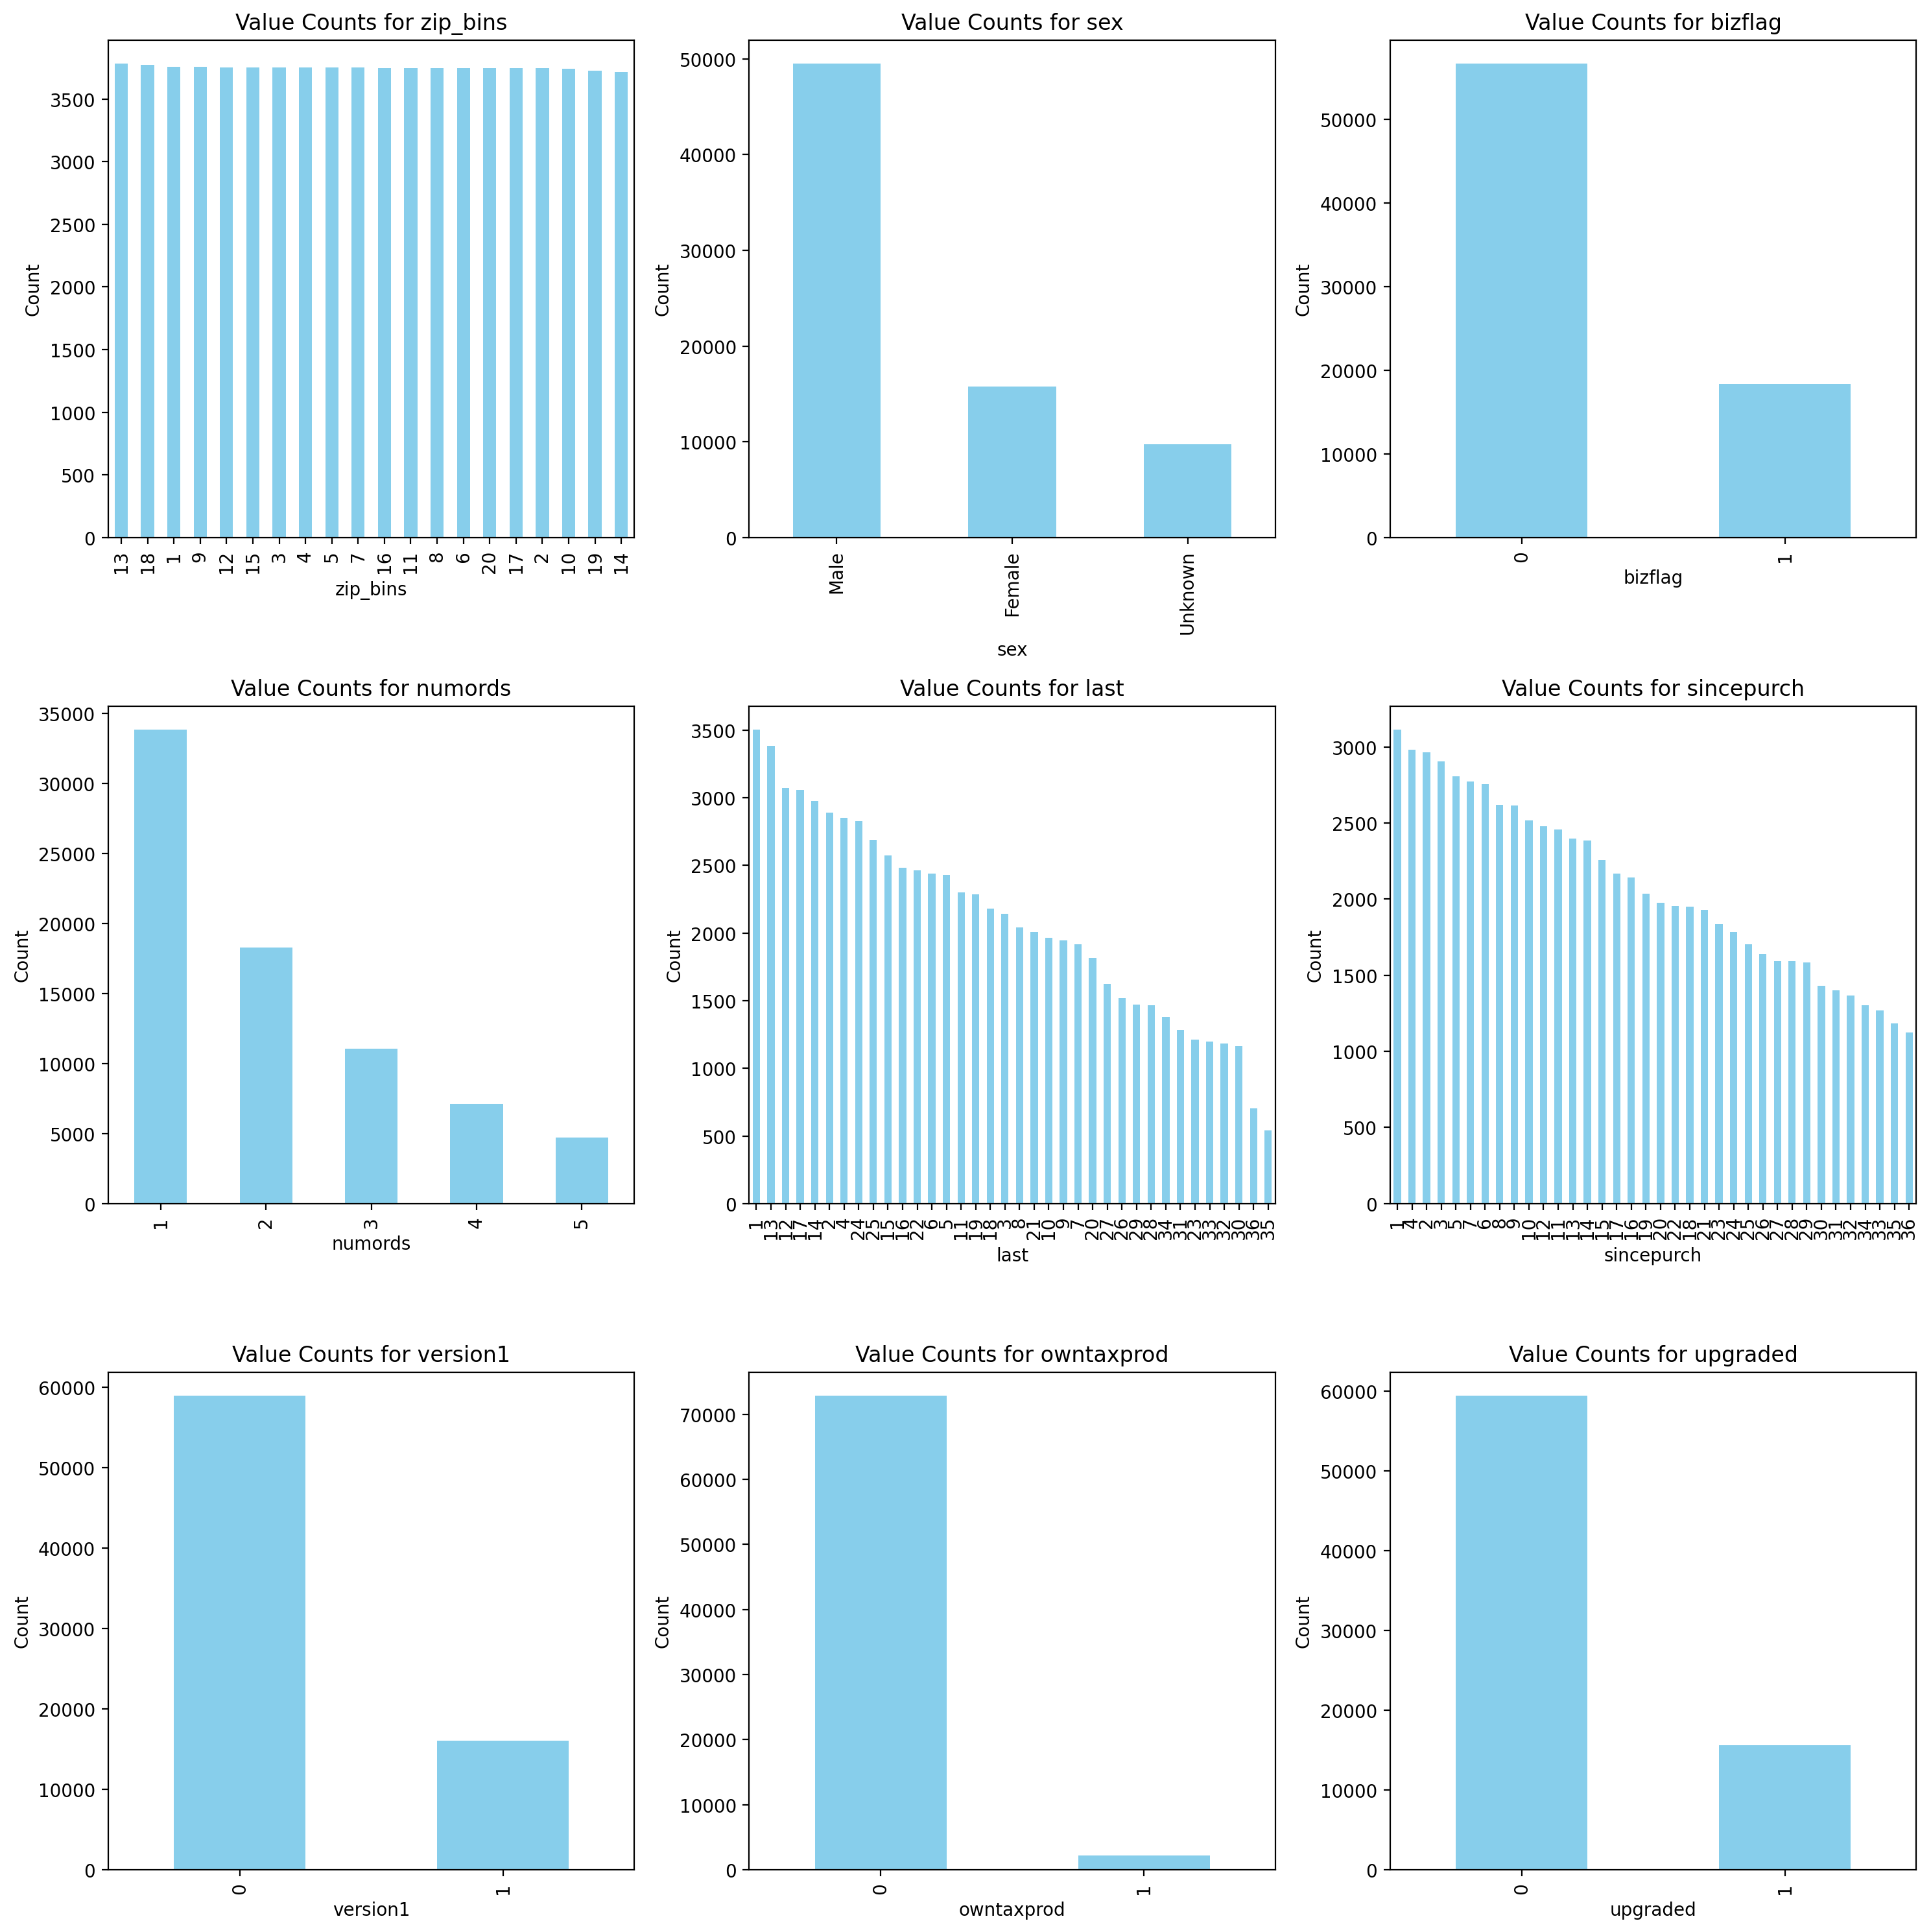

In [10]:
intuit75k_plot = intuit75k.drop(columns=['id', 'zip5', 'dollars', 'res1', 'training', 'res1_yes']) 

num_columns = len(intuit75k_plot .columns)
cols = 3 
rows = (num_columns // cols) + (num_columns % cols > 0) 

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for i, column in enumerate(intuit75k_plot.columns):
    value_counts = intuit75k_plot[column].value_counts()
    value_counts.plot(kind='bar', color='skyblue', ax=axes[i])
    axes[i].set_title(f'Value Counts for {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

#### Calculate the correlation matrix

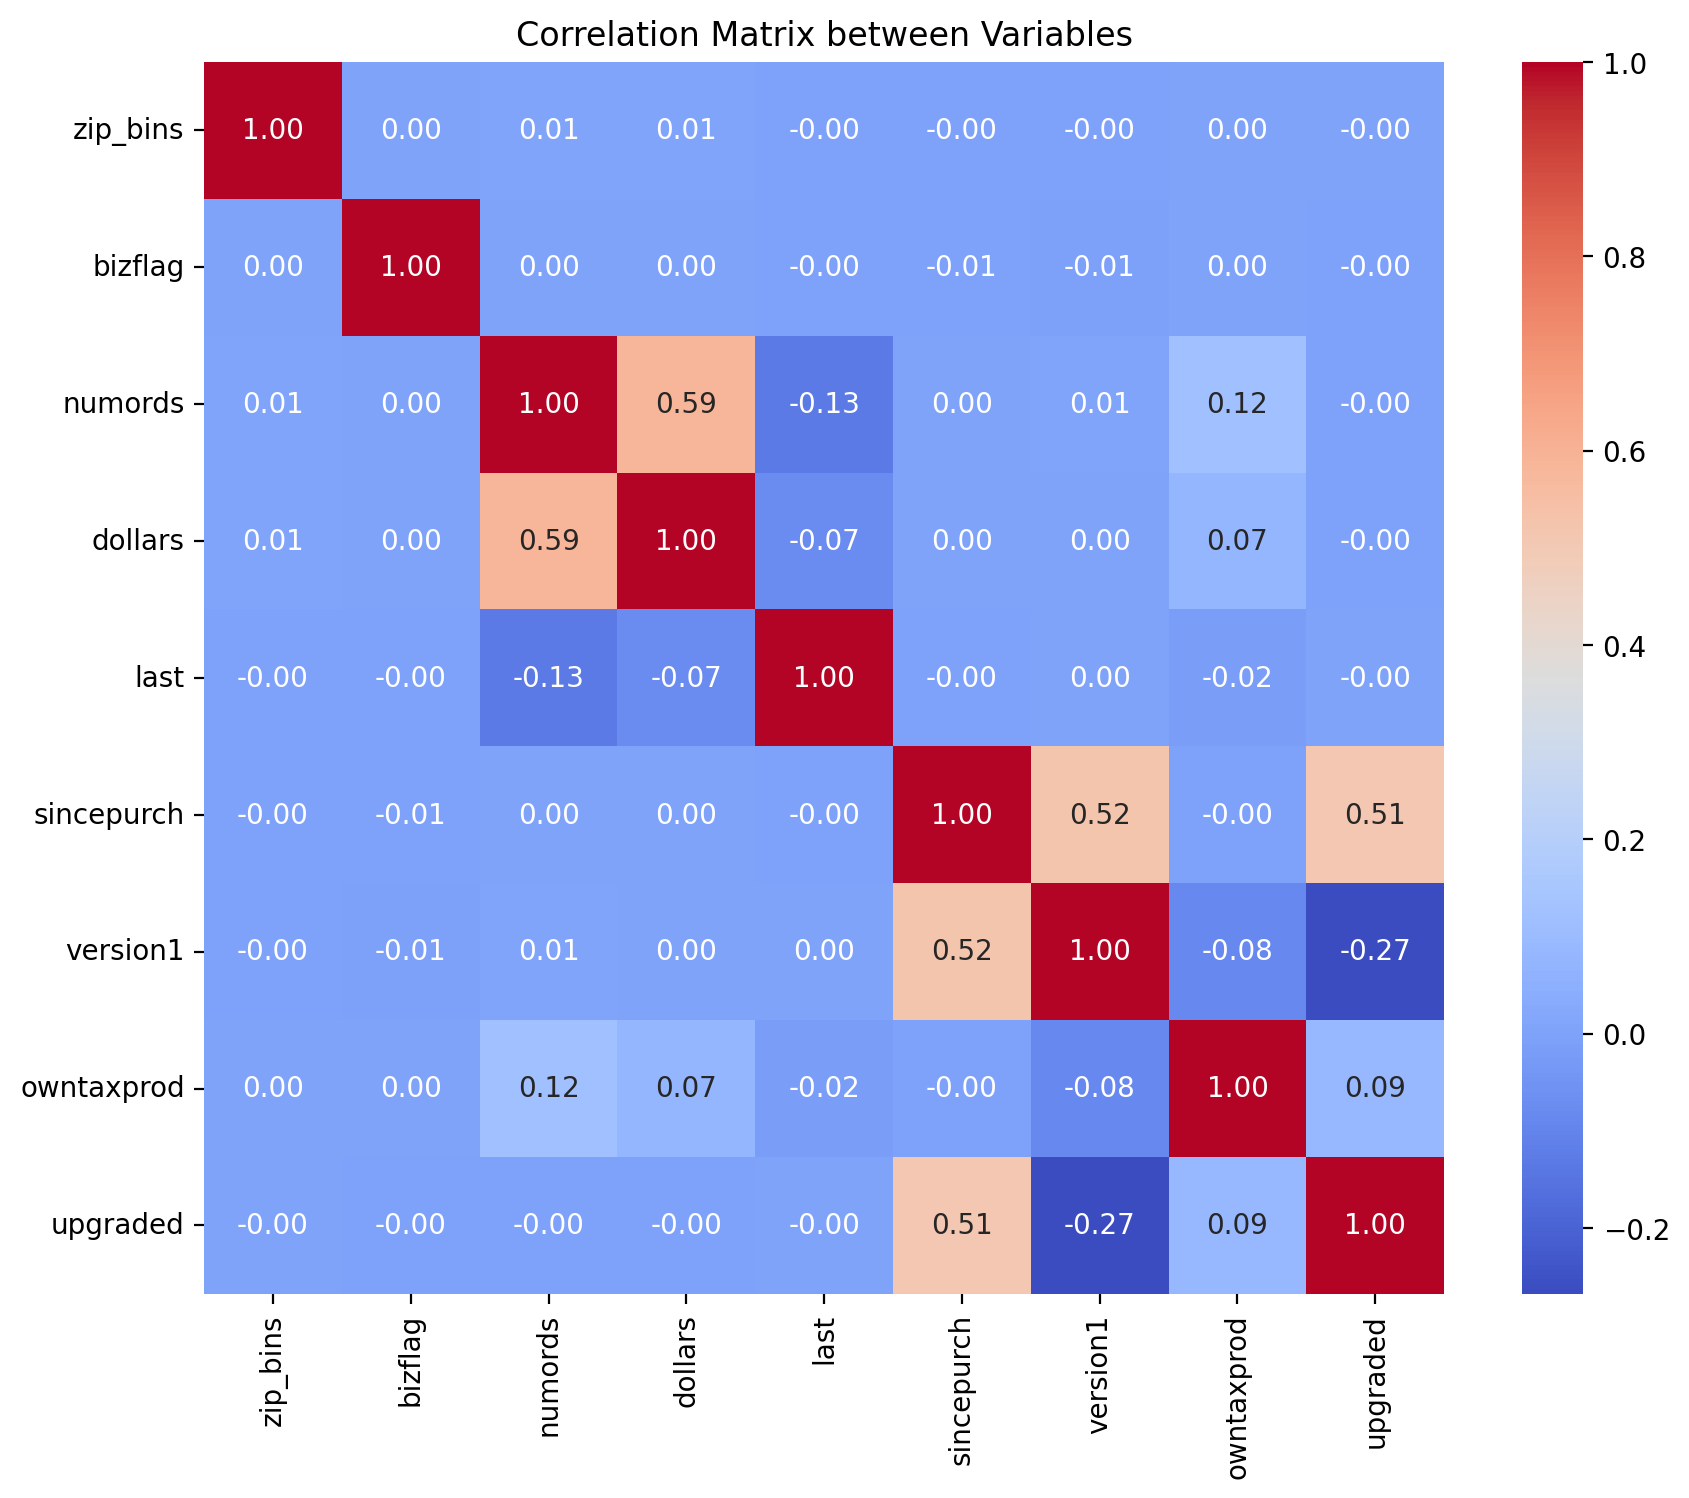

In [11]:
import seaborn as sns

corr_matrix = intuit75k[["zip_bins", "bizflag", "numords", "dollars", "last", "sincepurch", "version1", "owntaxprod", "upgraded"]].corr()
# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix between Variables')
plt.show()

The correlation matrix visualizes the relationships between different variables. Notably, numords and dollars have a strong positive correlation (0.59), while sincepurch and upgraded also show a moderate positive correlation (0.51). The version1 variable has a weak negative correlation (-0.27) with upgraded, indicating a possible inverse relationship

#### Analysing Zip_Bins 

In [12]:
zip_bins_tot = intuit75k.groupby('zip_bins')['id'].count()
zip_bins_tot

/tmp/ipykernel_5291/305023343.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  zip_bins_tot = intuit75k.groupby('zip_bins')['id'].count()


zip_bins
1     3757
2     3745
3     3751
4     3751
5     3751
6     3748
7     3751
8     3748
9     3757
10    3742
11    3749
12    3754
13    3782
14    3718
15    3752
16    3749
17    3747
18    3774
19    3726
20    3748
Name: id, dtype: int64

In [13]:
zip_bins_yes = intuit75k[intuit75k['res1_yes']==1].groupby('zip_bins')['id'].count()
zip_bins_yes

/tmp/ipykernel_5291/2879597230.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  zip_bins_yes = intuit75k[intuit75k['res1_yes']==1].groupby('zip_bins')['id'].count()


zip_bins
1     821
2     162
3     128
4     156
5     124
6     138
7     140
8     137
9     137
10    143
11    142
12    185
13    129
14    134
15    132
16    139
17    148
18    196
19    163
20    147
Name: id, dtype: int64

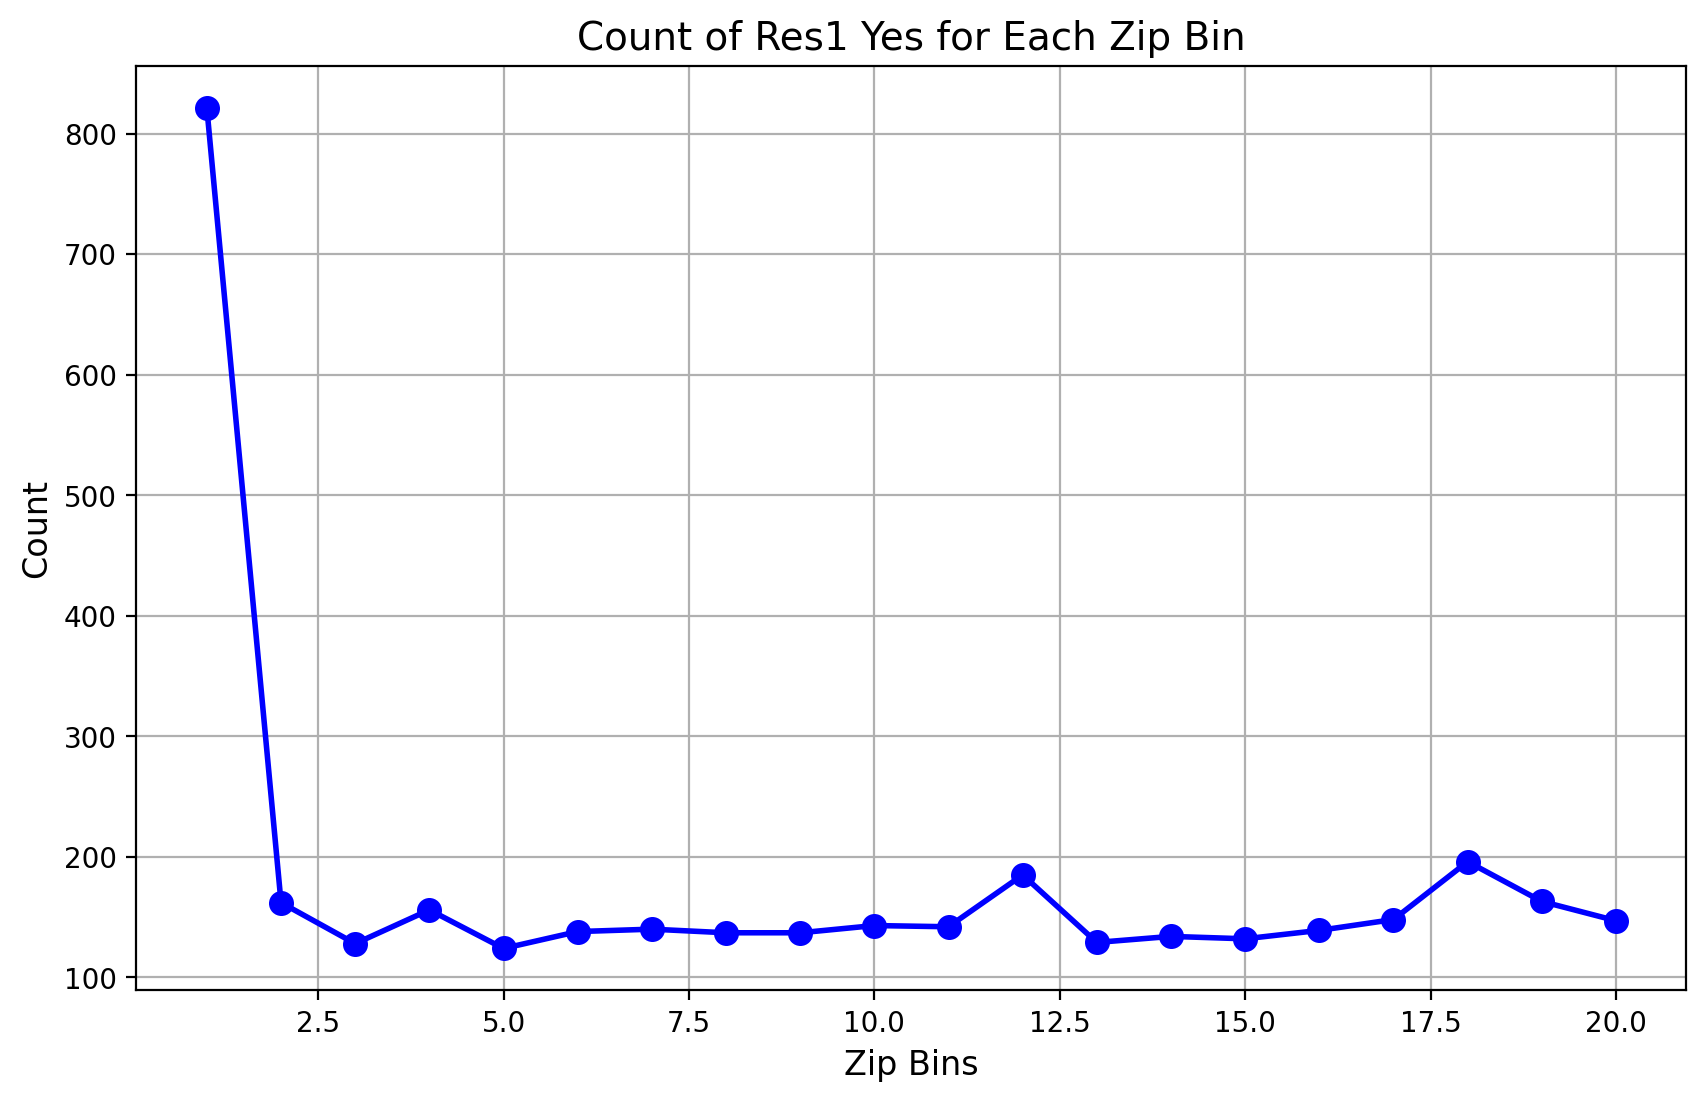

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(zip_bins_yes.index, zip_bins_yes.values, marker='o', color='b', linestyle='-', linewidth=2, markersize=8)
plt.xlabel('Zip Bins', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Count of Res1 Yes for Each Zip Bin', fontsize=14)
plt.grid(True)
plt.show()


- We can see from the above graph that Zip_bin 1 has the most number of resposes

In [15]:
zip1 = intuit75k[intuit75k['zip_bins']==1].groupby('zip5')['id'].count()
zip1 = zip1.sort_values()
zip1

zip5
01826       1
01028       1
01012       1
01603       1
02167       1
         ... 
02116      33
01701      41
00000     137
00804     186
00801    1668
Name: id, Length: 184, dtype: int64

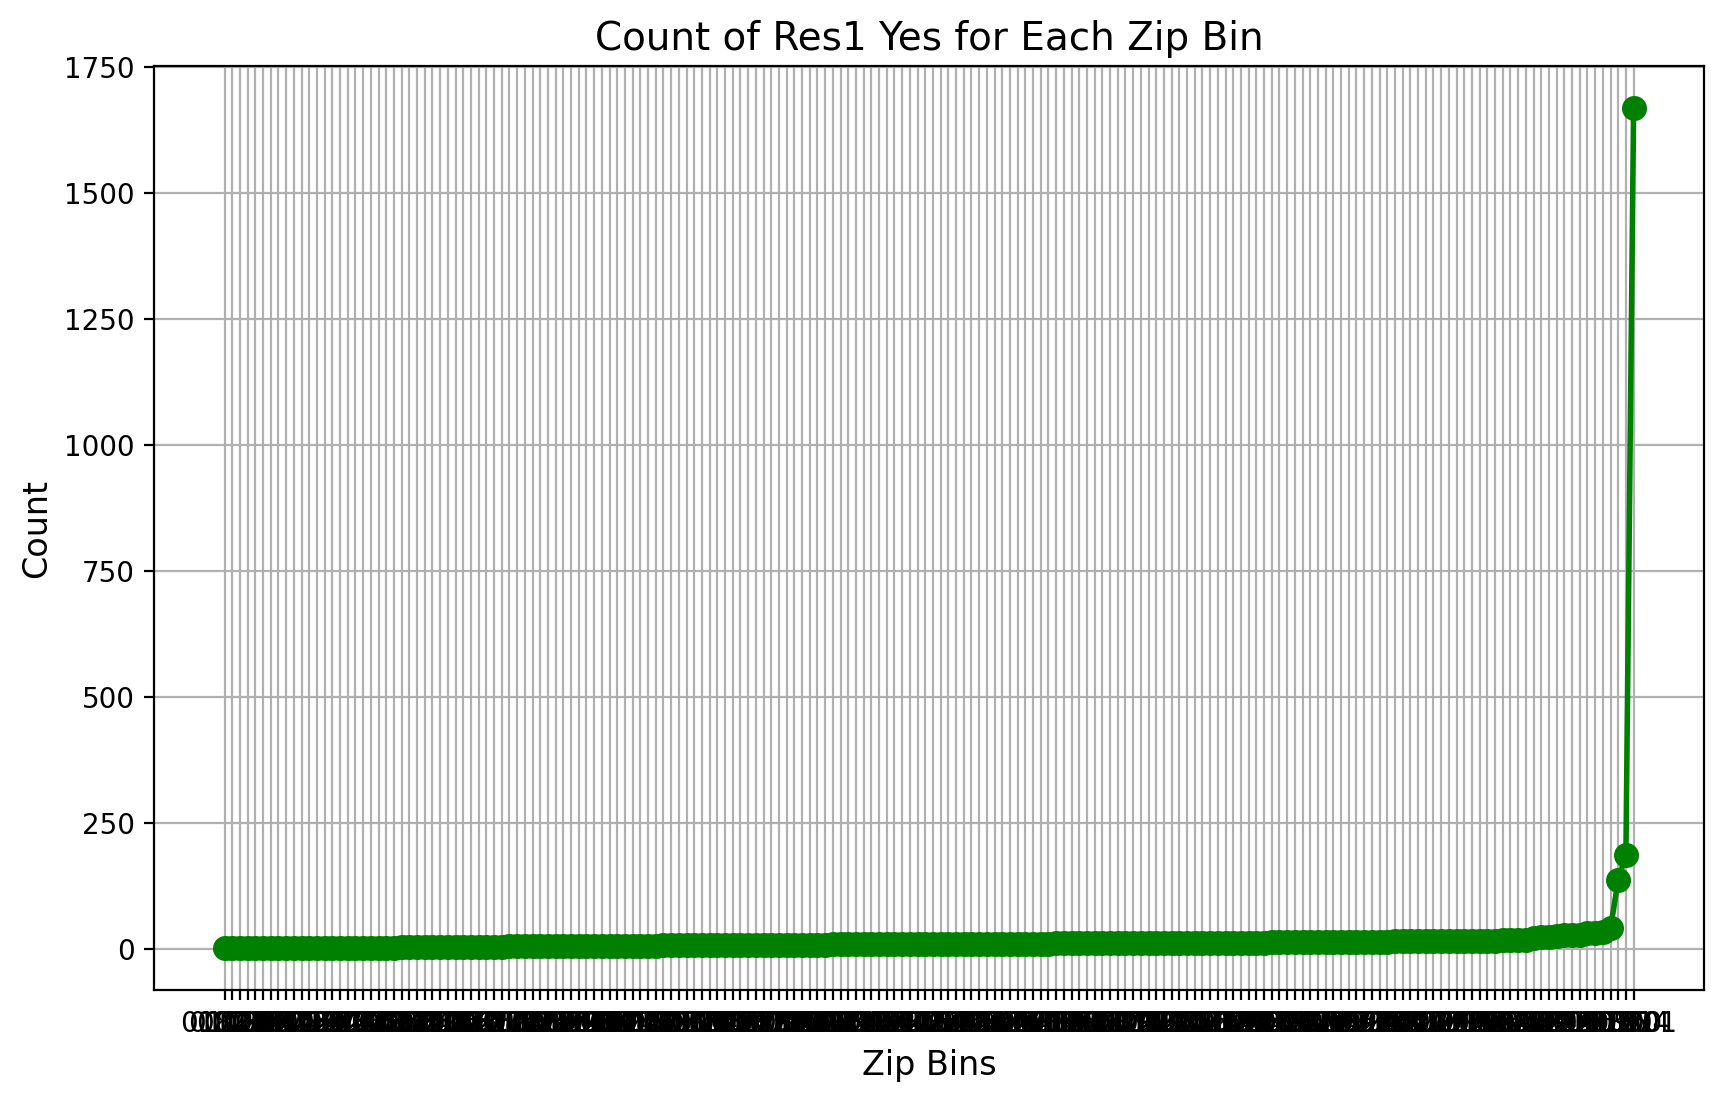

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(zip1.index, zip1.values, marker='o', color='g', linewidth=2, markersize=8)
plt.xlabel('Zip Bins', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Count of Res1 Yes for Each Zip Bin', fontsize=14)
plt.grid(True)
plt.show()

- From the above data and the graph we can see that one of the zip code in zip_bin 1 that is 00801 has extremely high amount of responses

### Splitting Train and Test Data

In [17]:
# Train vs. Test
train_data = intuit75k.query("training == 1").copy()
test_data  = intuit75k.query("training == 0").copy()

print(f"Train set size: {len(train_data):,}")
print(f"Test set size : {len(test_data):,}")
print(train_data.head())
print(train_data.isna().sum())

Train set size: 52,500
Test set size : 22,500
   id   zip5 zip_bins   sex  bizflag  numords  dollars  last  sincepurch  \
0   1  94553       18  Male        0        2    109.5     5          12   
3   4  02125        1  Male        0        1     22.0    17           1   
5   6  12309        3  Male        0        1     20.0    17          17   
7   8  55122       11  Male        1        1     24.5     4          17   
9  10  20036        5  Male        0        3     73.5    10           9   

   version1  owntaxprod  upgraded res1  training  res1_yes  
0         0           0         0   No         1         0  
3         0           0         0   No         1         0  
5         0           0         1   No         1         0  
7         1           0         0   No         1         0  
9         0           0         0   No         1         0  
id            0
zip5          0
zip_bins      0
sex           0
bizflag       0
numords       0
dollars       0
last          0
sin

## L1 Variable Selection for Logistic Regression Modelling

In [18]:
candidate_vars = ["zip_bins", "sex", "bizflag", "numords", "dollars", "last", "sincepurch", "version1", "owntaxprod", "upgraded"]

In [19]:
X_train_l1 = train_data[candidate_vars].copy()
y_train_l1 = (train_data["res1"] == "Yes").astype(int)
X_train_l1 = pd.get_dummies(X_train_l1, columns=["sex"], drop_first=True)

In [20]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
param_grid = {"C": [0.01, 0.1, 1, 10, 100]}
logit_l1 = LogisticRegression(
penalty="l1",
solver="liblinear",
random_state=123
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

grid_search = GridSearchCV(
estimator=logit_l1,
param_grid=param_grid,
scoring="roc_auc",
cv=cv,
verbose=1,
n_jobs=-1 # uses all available cores; you can set to 1 if needed
)

grid_search.fit(X_train_l1, y_train_l1)
print("Best parameters:", grid_search.best_params_)
print("Best AUC score on training folds:", grid_search.best_score_)

best_l1_model = grid_search.best_estimator_
print("Chosen C:", best_l1_model.C)
coeffs = pd.Series(best_l1_model.coef_[0], index=X_train_l1.columns)
print("Non-zero coefficients after best-C selection:")
print(coeffs[coeffs != 0])

Fitting 5 folds for each of 5 candidates, totalling 25 fits


Best parameters: {'C': 1}
Best AUC score on training folds: 0.7079931454070746
Chosen C: 1
Non-zero coefficients after best-C selection:
zip_bins      -0.055403
bizflag        0.043430
numords        0.223268
dollars        0.000972
last          -0.042718
sincepurch     0.002258
version1       0.723423
owntaxprod     0.297254
upgraded       0.923781
sex_Male      -0.010939
sex_Unknown   -0.004154
dtype: float64


### The L1 regularisation process has shrunken the variables, though none of them goes to zero - so we proceed with the same set of variables as we started with - dropping none.

In [21]:
final_evars_l1 = []
for fv in coeffs.index:
    if fv.startswith("sex_"):
        #  we'll store them as a factor in the final data with the same name
        final_evars_l1.append(fv)  
    else:
        final_evars_l1.append(fv)

print("\nFinal variables used in pyrsm logistic:", final_evars_l1)


Final variables used in pyrsm logistic: ['zip_bins', 'bizflag', 'numords', 'dollars', 'last', 'sincepurch', 'version1', 'owntaxprod', 'upgraded', 'sex_Male', 'sex_Unknown']


## Training the Logistic Model with all variables

In [22]:
def transform_for_pyrsm(df):
    dfx = df.copy()
    # Only create dummies for "sex" if it actually exists in the data
    if "sex" in dfx.columns:
        dfx = pd.get_dummies(dfx, columns=["sex"], prefix="sex", drop_first=True)

    # Ensure the dummy columns exist even if data had no rows for them
    for col in ["sex_Male", "sex_Unknown"]:
        if col not in dfx.columns:
            dfx[col] = 0

    return dfx


train_pyrsm = transform_for_pyrsm(train_data)

logit_model1 = rsm.logistic(
    data={"intuit_data": train_pyrsm},
    rvar="res1",
    lev="Yes",
    evar=final_evars_l1
)

logit_model1.summary(main=True, fit=True, ci=False, vif=True)

Logistic regression (GLM)
Data                 : intuit_data
Response variable    : res1
Level                : Yes
Explanatory variables: zip_bins, bizflag, numords, dollars, last, sincepurch, version1, owntaxprod, upgraded, sex_Male, sex_Unknown
Null hyp.: There is no effect of x on res1
Alt. hyp.: There is an effect of x on res1

                      OR     OR%  coefficient  std.error  z.value p.value     
Intercept          0.181  -81.9%        -1.71      0.092  -18.507  < .001  ***
zip_bins[2]        0.148  -85.2%        -1.91      0.110  -17.296  < .001  ***
zip_bins[3]        0.118  -88.2%        -2.14      0.121  -17.710  < .001  ***
zip_bins[4]        0.136  -86.4%        -2.00      0.112  -17.811  < .001  ***
zip_bins[5]        0.116  -88.4%        -2.15      0.120  -17.894  < .001  ***
zip_bins[6]        0.126  -87.4%        -2.07      0.115  -18.043  < .001  ***
zip_bins[7]        0.121  -87.9%        -2.11      0.117  -17.970  < .001  ***
zip_bins[8]        0.131  -86.9% 

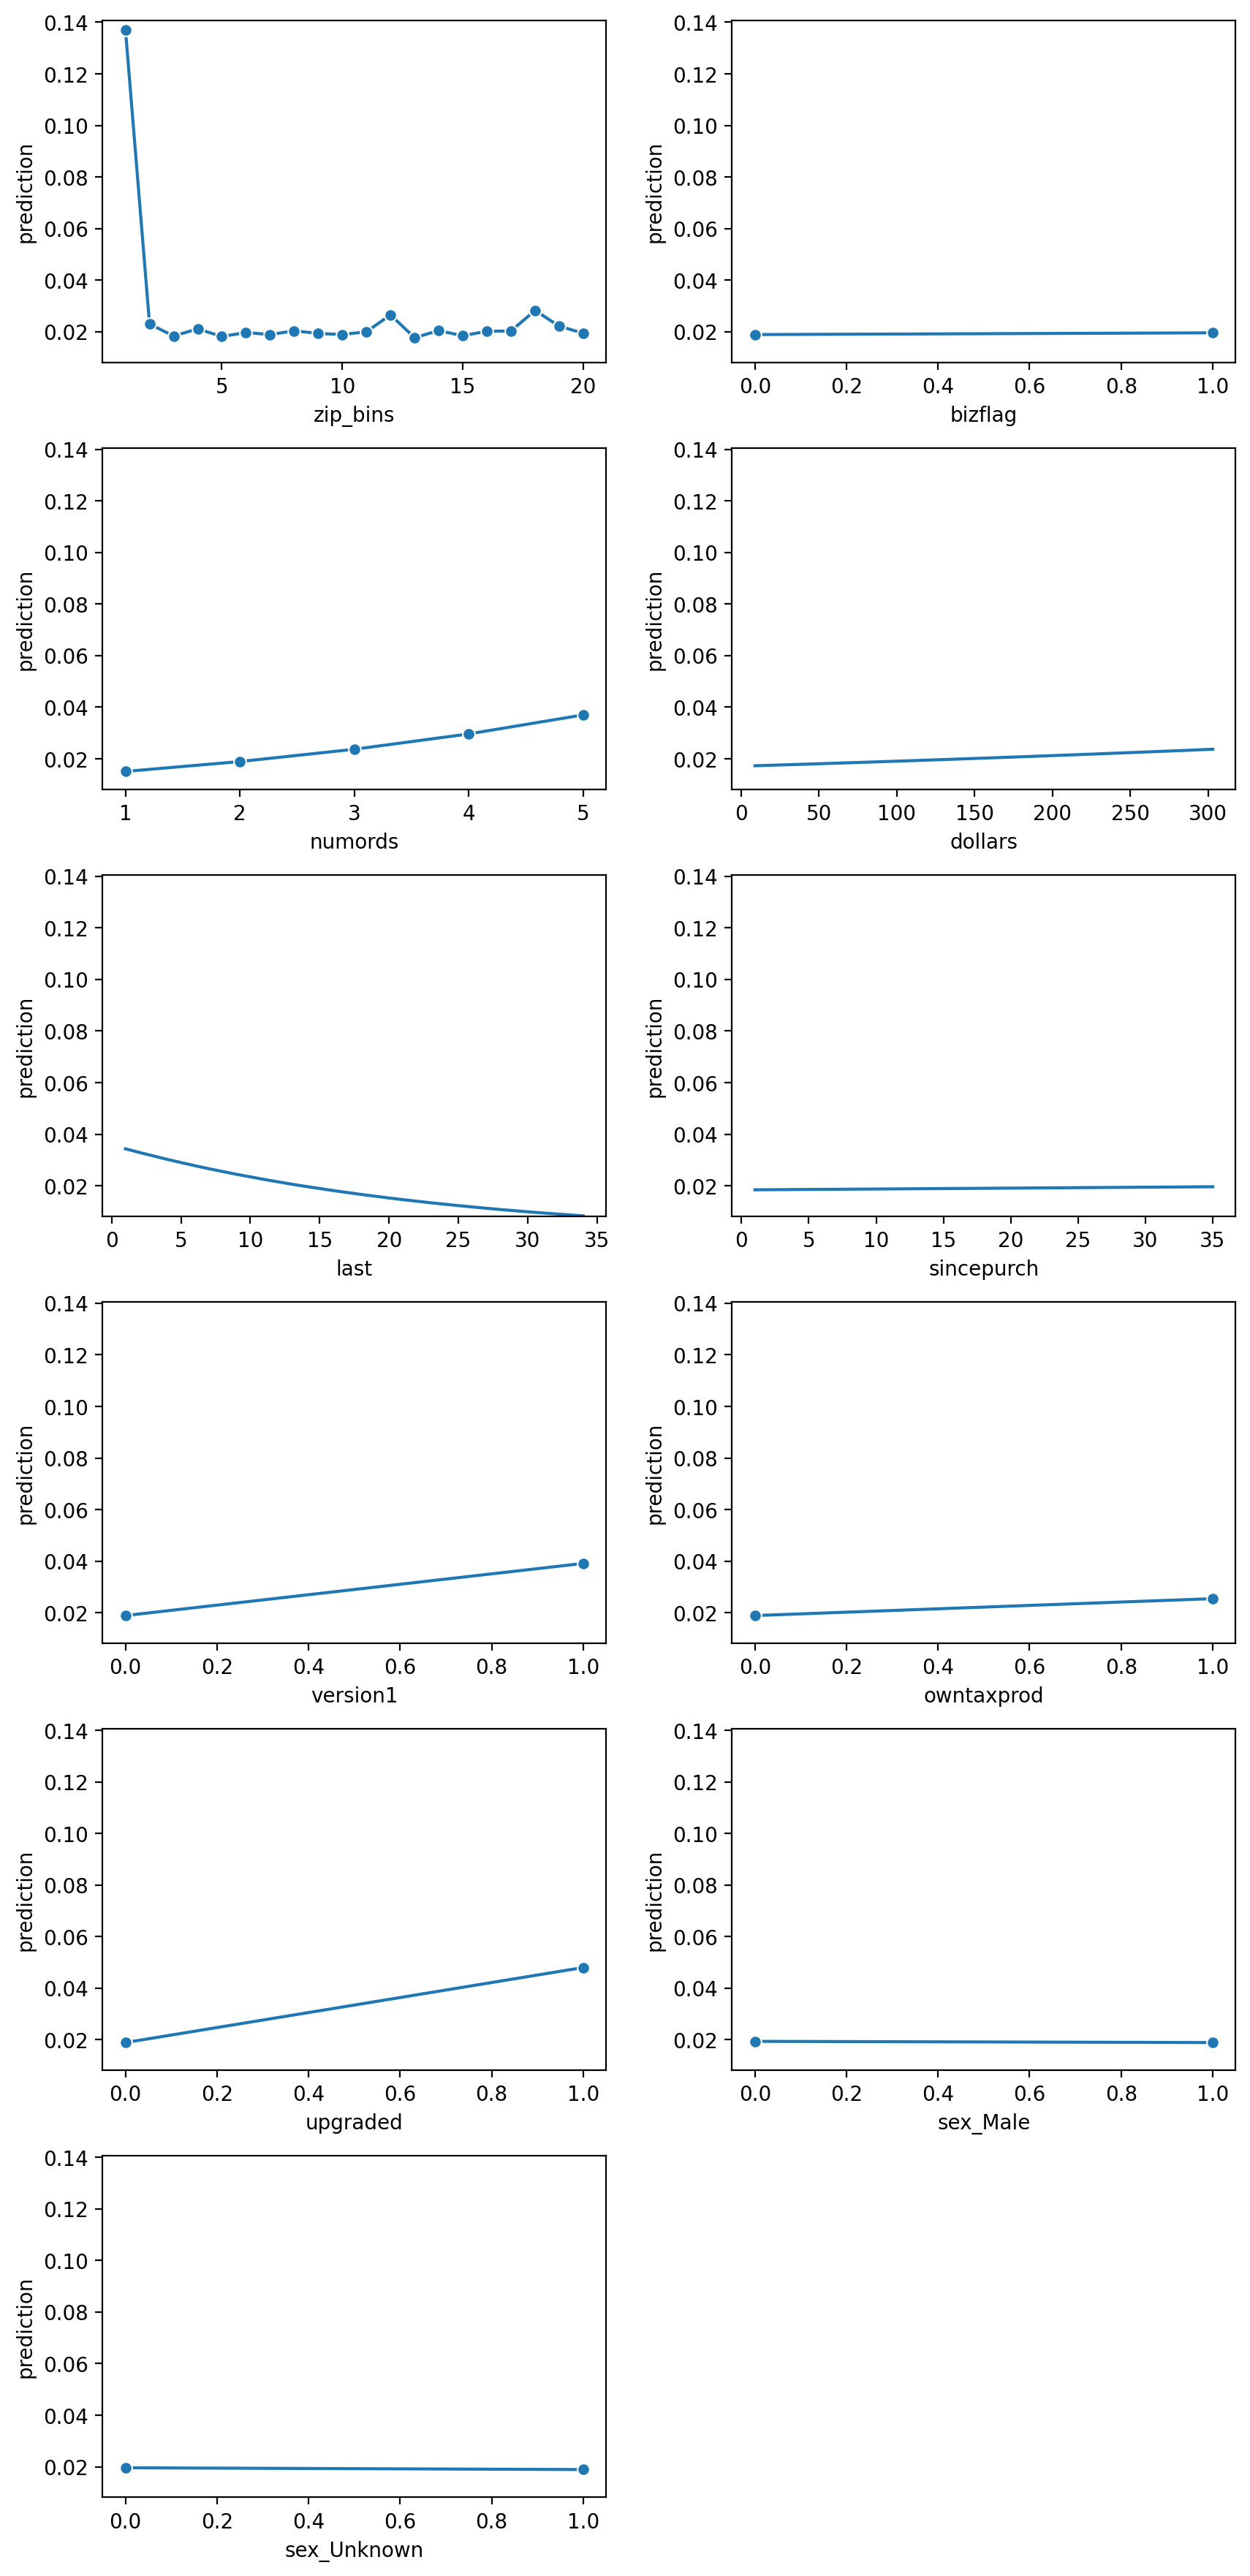

In [23]:
logit_model1.plot(plots="pred")

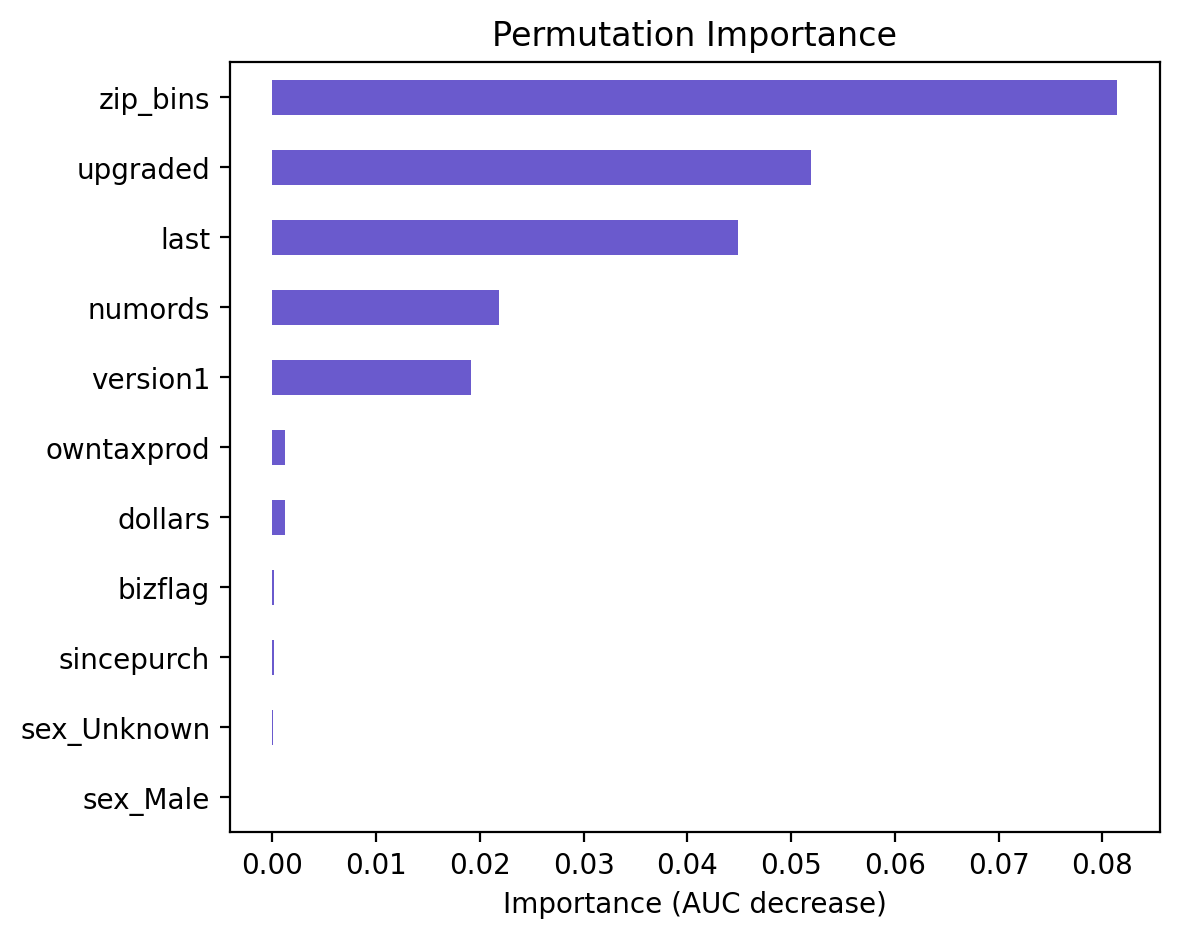

In [24]:
logit_model1.plot(plots="vimp") #Permutation importance plot

In [25]:
intuit75k_pyrsm = transform_for_pyrsm(intuit75k)

# Now predict using logit_model1
intuit75k["pred_logit"] = logit_model1.predict(intuit75k_pyrsm)["prediction"]
intuit75k

,id,zip5,zip_bins,sex,bizflag,numords,dollars,last,sincepurch,version1,owntaxprod,upgraded,res1,training,res1_yes,pred_logit
0,1,94553,18,Male,0,2,109.5,5,12,0,0,0,No,1,0,0.045181
1,2,53190,10,Unknown,0,1,69.5,4,3,0,0,0,No,0,0,0.023644
2,3,37091,8,Male,0,4,93.0,14,29,0,0,1,No,0,0,0.087433
3,4,02125,1,Male,0,1,22.0,17,1,0,0,0,No,1,0,0.097645
4,5,60201,11,Male,0,1,24.5,2,3,0,0,0,No,0,0,0.026243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74995,74996,28205,6,Male,1,4,211.5,5,15,0,0,0,Yes,1,1,0.056933
74996,74997,94806,18,Male,0,1,4.5,35,34,1,0,0,No,1,0,0.019476
74997,74998,72958,13,Female,1,1,54.5,4,19,1,0,0,No,1,0,0.049537
74998,74999,29464,6,Male,0,1,69.5,20,27,0,0,1,No,1,0,0.033561


### In the permutation importance plot above, we see that the variables sincepurch, bizflag, sex_Male and sex_Unknown have close to zero importance. 
### Additionally, in the logistic model, we see that the p-values of these variables are as follows:
#### sincepurch - 0.641
#### bizflag - 0.466
#### sex_Male - 0.637
#### sex_Unknown - 0.628

### Therefore, we will drop these variables and train a second logistic regression model.

In [26]:
logit_model2 = rsm.logistic(
    data={"intuit_data": train_pyrsm},
    rvar="res1",
    lev="Yes",
    evar= ["zip_bins", "numords", "dollars", "last", "version1", "owntaxprod", "upgraded"]
)

logit_model2.summary(main=True, fit=True, ci=False, vif=True)

Logistic regression (GLM)
Data                 : intuit_data
Response variable    : res1
Level                : Yes
Explanatory variables: zip_bins, numords, dollars, last, version1, owntaxprod, upgraded
Null hyp.: There is no effect of x on res1
Alt. hyp.: There is an effect of x on res1

                 OR     OR%  coefficient  std.error  z.value p.value     
Intercept     0.181  -81.9%        -1.71      0.075  -22.724  < .001  ***
zip_bins[2]   0.148  -85.2%        -1.91      0.110  -17.300  < .001  ***
zip_bins[3]   0.118  -88.2%        -2.14      0.121  -17.709  < .001  ***
zip_bins[4]   0.136  -86.4%        -2.00      0.112  -17.806  < .001  ***
zip_bins[5]   0.116  -88.4%        -2.15      0.120  -17.894  < .001  ***
zip_bins[6]   0.127  -87.3%        -2.07      0.115  -18.042  < .001  ***
zip_bins[7]   0.121  -87.9%        -2.11      0.117  -17.974  < .001  ***
zip_bins[8]   0.131  -86.9%        -2.03      0.114  -17.848  < .001  ***
zip_bins[9]   0.124  -87.6%        -2.09   

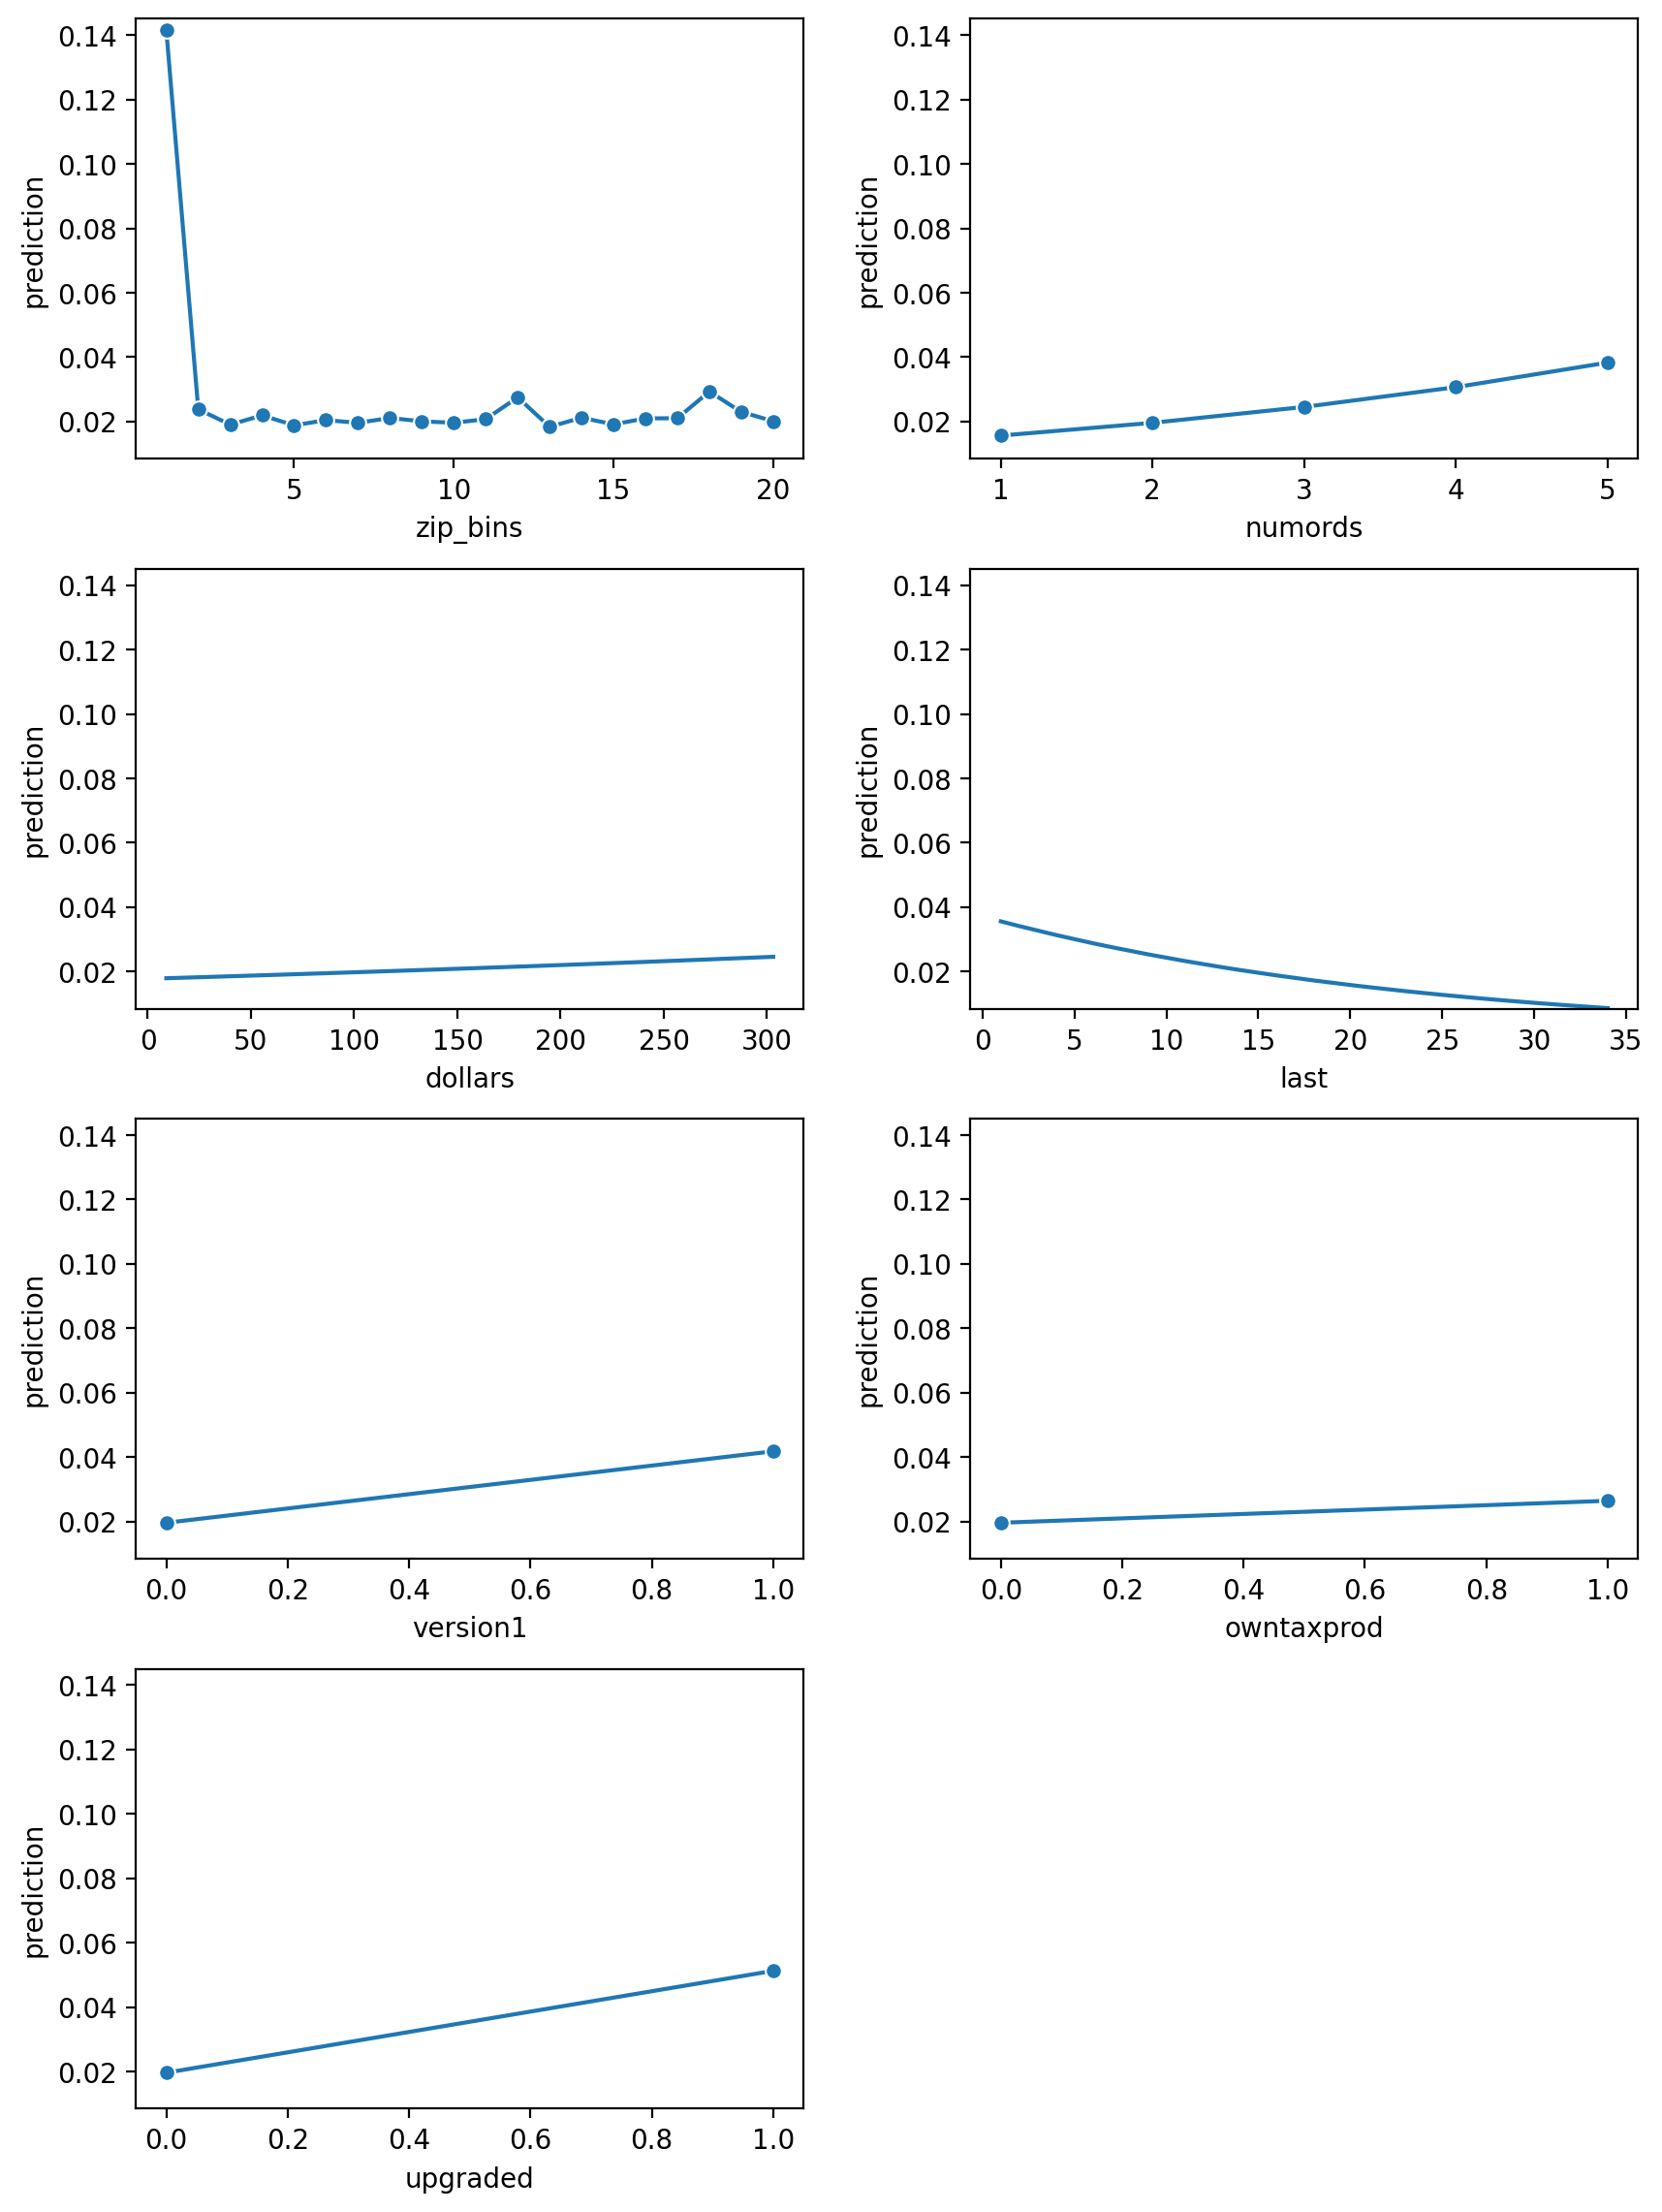

In [27]:
logit_model2.plot(plots="pred")

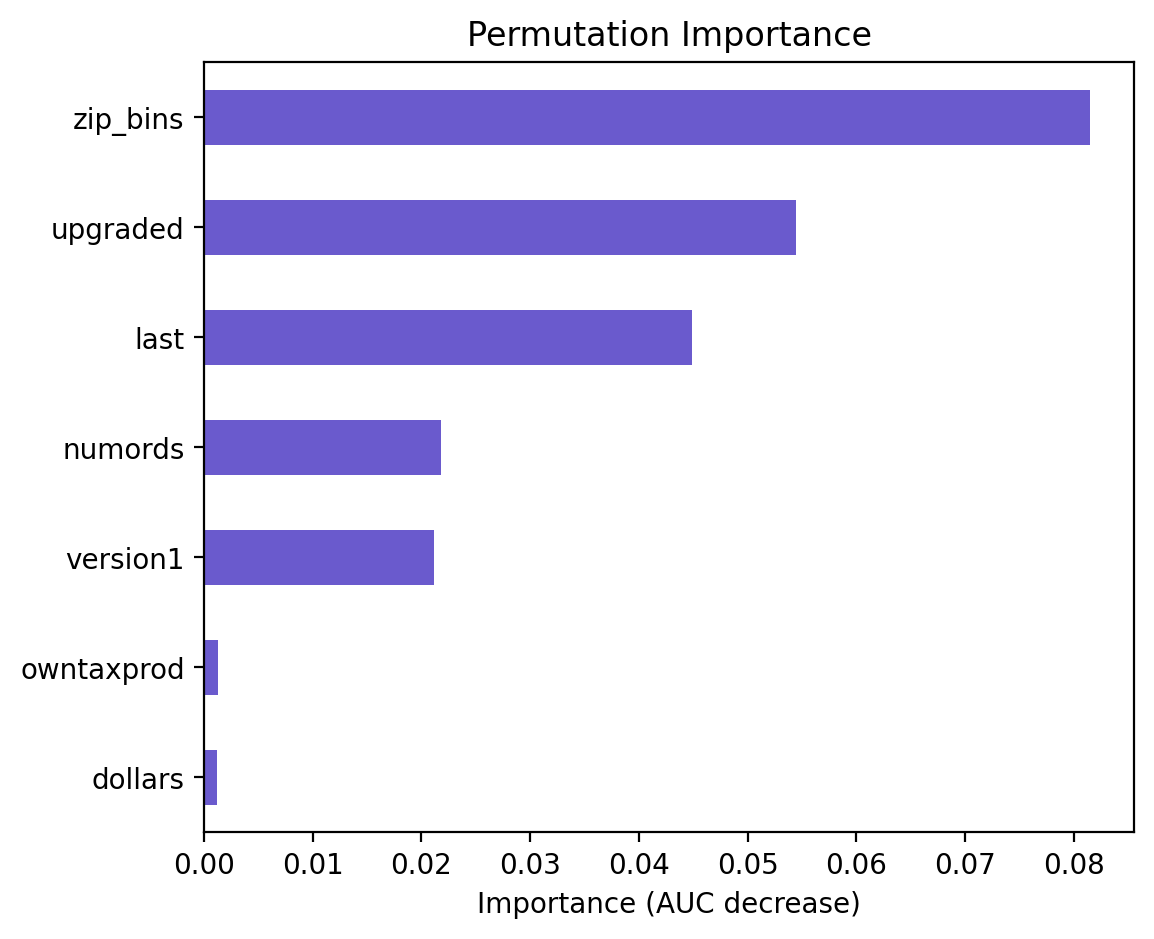

In [28]:
logit_model2.plot(plots="vimp")

In [29]:
intuit75k_pyrsm = transform_for_pyrsm(intuit75k)

intuit75k["pred_logit_a"] = logit_model2.predict(intuit75k_pyrsm)["prediction"]
intuit75k

,id,zip5,zip_bins,sex,bizflag,numords,dollars,last,sincepurch,version1,owntaxprod,upgraded,res1,training,res1_yes,pred_logit,pred_logit_a
0,1,94553,18,Male,0,2,109.5,5,12,0,0,0,No,1,0,0.045181,0.045480
1,2,53190,10,Unknown,0,1,69.5,4,3,0,0,0,No,0,0,0.023644,0.024463
2,3,37091,8,Male,0,4,93.0,14,29,0,0,1,No,0,0,0.087433,0.087893
3,4,02125,1,Male,0,1,22.0,17,1,0,0,0,No,1,0,0.097645,0.099972
4,5,60201,11,Male,0,1,24.5,2,3,0,0,0,No,0,0,0.026243,0.026831
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74995,74996,28205,6,Male,1,4,211.5,5,15,0,0,0,Yes,1,1,0.056933,0.055084
74996,74997,94806,18,Male,0,1,4.5,35,34,1,0,0,No,1,0,0.019476,0.019425
74997,74998,72958,13,Female,1,1,54.5,4,19,1,0,0,No,1,0,0.049537,0.047879
74998,74999,29464,6,Male,0,1,69.5,20,27,0,0,1,No,1,0,0.033561,0.033893


#### In all the two logistic regression models trained above, we see that there is not much difference in the model performance after deleting the following variables - sincepurch, sex_Male, sex_Unknown, and bizflag. 
#### The chi-squared value does not change much, and remains significant. The AUC at 0.755 indicates a strong predictive power of the trained models. 
#### We will now check for any interactions among the significant variables that we have identified.

## Checking variable interactions

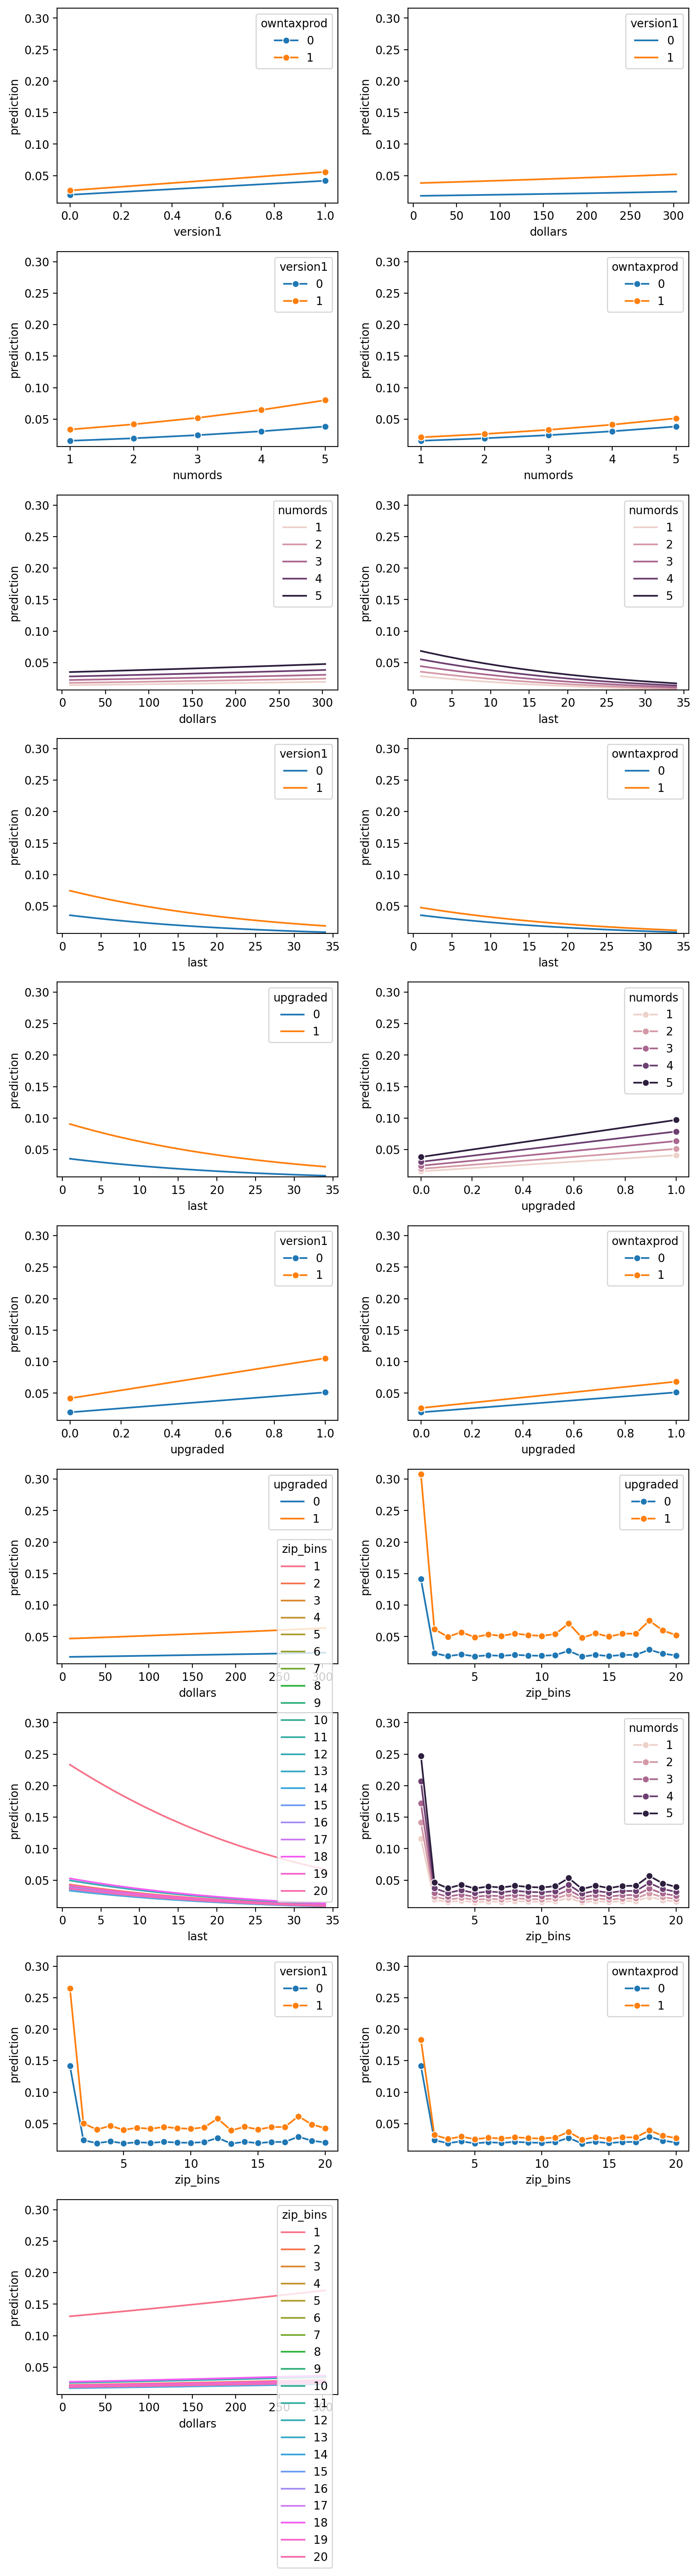

In [30]:
logit_model2.plot(plots="pred", incl=[], incl_int = ["version1:owntaxprod", "version1:dollars", "numords:version1","numords:owntaxprod","numords:dollars","last:numords","last:version1","last:owntaxprod","upgraded:last","upgraded:numords","upgraded:version1","upgraded:owntaxprod","upgraded:dollars","zip_bins:upgraded","zip_bins:last","zip_bins:numords","zip_bins:version1","zip_bins:owntaxprod","zip_bins:dollars"])

#### We see that there is no clear evidence of interactions using the logistic regression model. 
#### Let us move on to the Gains Plot.

In [31]:
intuit75k["pred_logit_b"] = logit_model2.predict(intuit75k)["prediction"]
intuit75k

,id,zip5,zip_bins,sex,bizflag,numords,dollars,last,sincepurch,version1,owntaxprod,upgraded,res1,training,res1_yes,pred_logit,pred_logit_a,pred_logit_b
0,1,94553,18,Male,0,2,109.5,5,12,0,0,0,No,1,0,0.045181,0.045480,0.045480
1,2,53190,10,Unknown,0,1,69.5,4,3,0,0,0,No,0,0,0.023644,0.024463,0.024463
2,3,37091,8,Male,0,4,93.0,14,29,0,0,1,No,0,0,0.087433,0.087893,0.087893
3,4,02125,1,Male,0,1,22.0,17,1,0,0,0,No,1,0,0.097645,0.099972,0.099972
4,5,60201,11,Male,0,1,24.5,2,3,0,0,0,No,0,0,0.026243,0.026831,0.026831
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74995,74996,28205,6,Male,1,4,211.5,5,15,0,0,0,Yes,1,1,0.056933,0.055084,0.055084
74996,74997,94806,18,Male,0,1,4.5,35,34,1,0,0,No,1,0,0.019476,0.019425,0.019425
74997,74998,72958,13,Female,1,1,54.5,4,19,1,0,0,No,1,0,0.049537,0.047879,0.047879
74998,74999,29464,6,Male,0,1,69.5,20,27,0,0,1,No,1,0,0.033561,0.033893,0.033893


## Gains plot

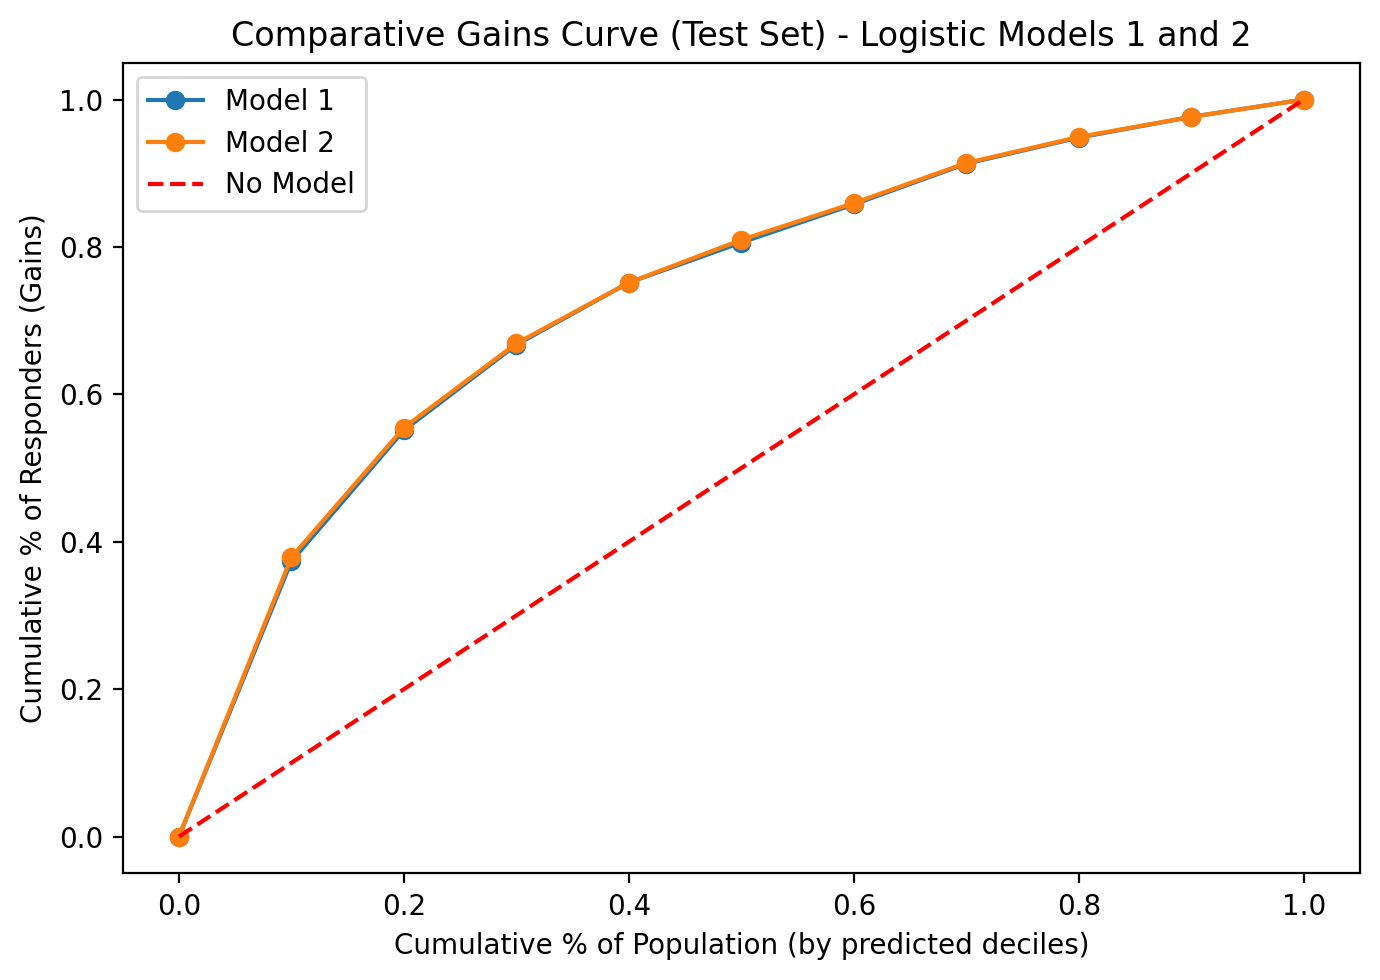

In [32]:
test_data = intuit75k.query("training == 0").copy()

# 1) Transform test_data so it has the same dummy columns, etc.
test_pyrsm = transform_for_pyrsm(test_data)

# 2) Generate predictions for each logistic model
test_data["pred_logit1"] = logit_model1.predict(test_pyrsm)["prediction"]
test_data["pred_logit2"] = logit_model2.predict(test_pyrsm)["prediction"]

from pyrsm.model import perf as rsm_perf

gains1_test = rsm_perf.gains_tab(
    df=test_data,
    rvar="res1",
    lev="Yes",
    pred="pred_logit1",
    qnt=10
)
gains2_test = rsm_perf.gains_tab(
    df=test_data,
    rvar="res1",
    lev="Yes",
    pred="pred_logit2",
    qnt=10
)

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(gains1_test["cum_prop"], gains1_test["cum_gains"], marker="o", label="Model 1")
plt.plot(gains2_test["cum_prop"], gains2_test["cum_gains"], marker="o", label="Model 2")

# Reference line (no model)
plt.plot([0,1], [0,1], "--", color="red", label="No Model")

plt.title("Comparative Gains Curve (Test Set) - Logistic Models 1 and 2")
plt.xlabel("Cumulative % of Population (by predicted deciles)")
plt.ylabel("Cumulative % of Responders (Gains)")
plt.legend()
plt.tight_layout()
plt.show()

#### We see that Model 2 performs almost the same as Model 1 (there is only a miniscule difference in model performance). Now, let us train a neural network on the given data.

## Neural Networks

##### We will experiment with various neural network models, exploring different solvers and node configurations to identify the optimal model. By systematically evaluating these variations, we aim to determine the most effective architecture for our dataset.

In [33]:
evar=[
    "zip_bins",
    "sex",
    "bizflag",
    "numords",
    "dollars",
    "last",
    "sincepurch",
    "version1",
    "owntaxprod",
    "upgraded"
]

#### Neural Networks with lbfgs Solver

In [34]:
def nn_model_l( hls, evar=evar, act="tanh", solver="lbfgs"):
    nnr = rsm.model.mlp(
        data={"intuit": train_data},
        rvar="res1",
        lev="Yes",
        evar=evar,
        activation=act,
        solver=solver,
        hidden_layer_sizes=hls,
        mod_type="classification",
    )
    nnr.summary()
    #pred = nnr.predict(intuit75k)
    nnr.plot(plots="vimp")
    plt.title("Neural Network - Permutation Importance ")
    plt.show()
    return nnr.predict(intuit75k)["prediction"] 

##### NN model with 1 node

Multi-layer Perceptron (NN)
Data                 : intuit
Response variable    : res1
Level                : Yes
Explanatory variables: zip_bins, sex, bizflag, numords, dollars, last, sincepurch, version1, owntaxprod, upgraded
Model type           : classification
Nr. of features      : (10, 29)
Nr. of weights       : 30
Nr. of observations  : 52,500
Hidden_layer_sizes   : (1,)
Activation function  : tanh
Solver               : lbfgs
Alpha                : 0.0001
Batch size           : auto
Learning rate        : 0.001
Maximum iterations   : 1000000
random_state         : 1234
AUC                  : 0.756

Raw data             :
zip_bins  sex  bizflag  numords  dollars  last  sincepurch  version1  owntaxprod  upgraded
      18 Male        0        2    109.5     5          12         0           0         0
       1 Male        0        1     22.0    17           1         0           0         0
       3 Male        0        1     20.0    17          17         0           0         1

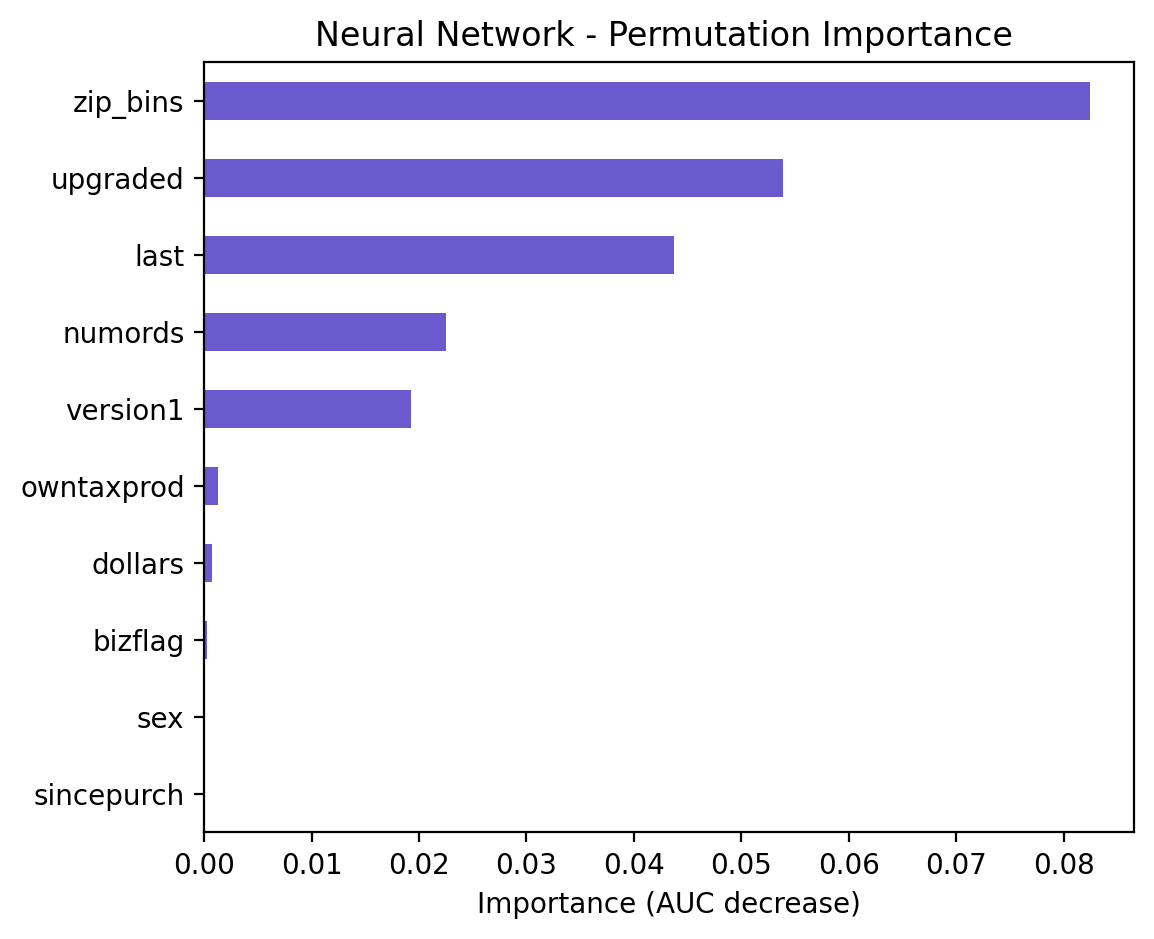

In [35]:
intuit75k["pred_nn1_l"] = nn_model_l((1,))

##### NN model with 2 nodes

Multi-layer Perceptron (NN)
Data                 : intuit
Response variable    : res1
Level                : Yes
Explanatory variables: zip_bins, sex, bizflag, numords, dollars, last, sincepurch, version1, owntaxprod, upgraded
Model type           : classification
Nr. of features      : (10, 29)
Nr. of weights       : 60
Nr. of observations  : 52,500
Hidden_layer_sizes   : (2,)
Activation function  : tanh
Solver               : lbfgs
Alpha                : 0.0001
Batch size           : auto
Learning rate        : 0.001
Maximum iterations   : 1000000
random_state         : 1234
AUC                  : 0.764

Raw data             :
zip_bins  sex  bizflag  numords  dollars  last  sincepurch  version1  owntaxprod  upgraded
      18 Male        0        2    109.5     5          12         0           0         0
       1 Male        0        1     22.0    17           1         0           0         0
       3 Male        0        1     20.0    17          17         0           0         1

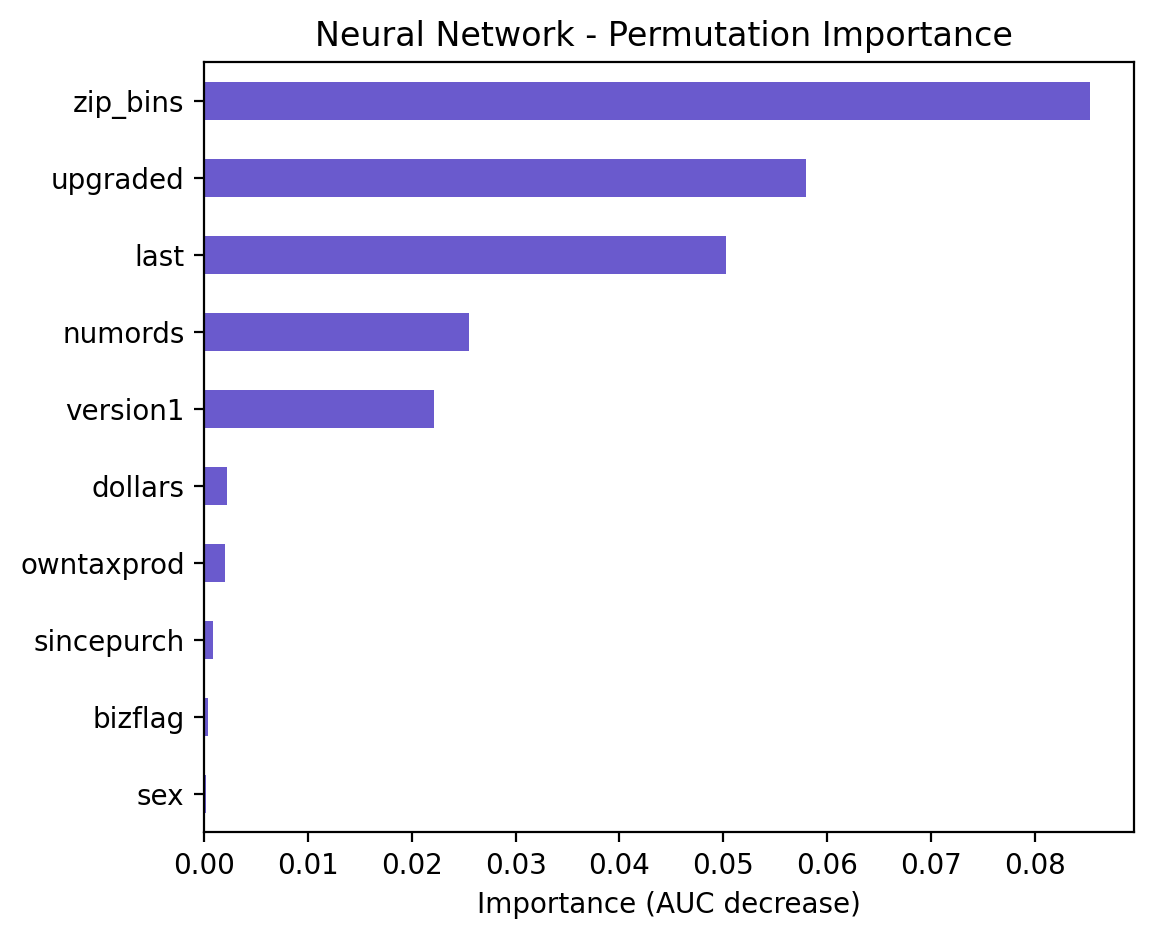

In [36]:
intuit75k["pred_nn2_l"] = nn_model_l((2,))

- The 1-node NN model has an AUC of 0.756, while the 2-node model improves to 0.764, indicating better performance. 
- The number of weights doubles from 30 to 60.

##### Gains and Lift graph for pred_logit, NN model Node-1 and NN model Node-2

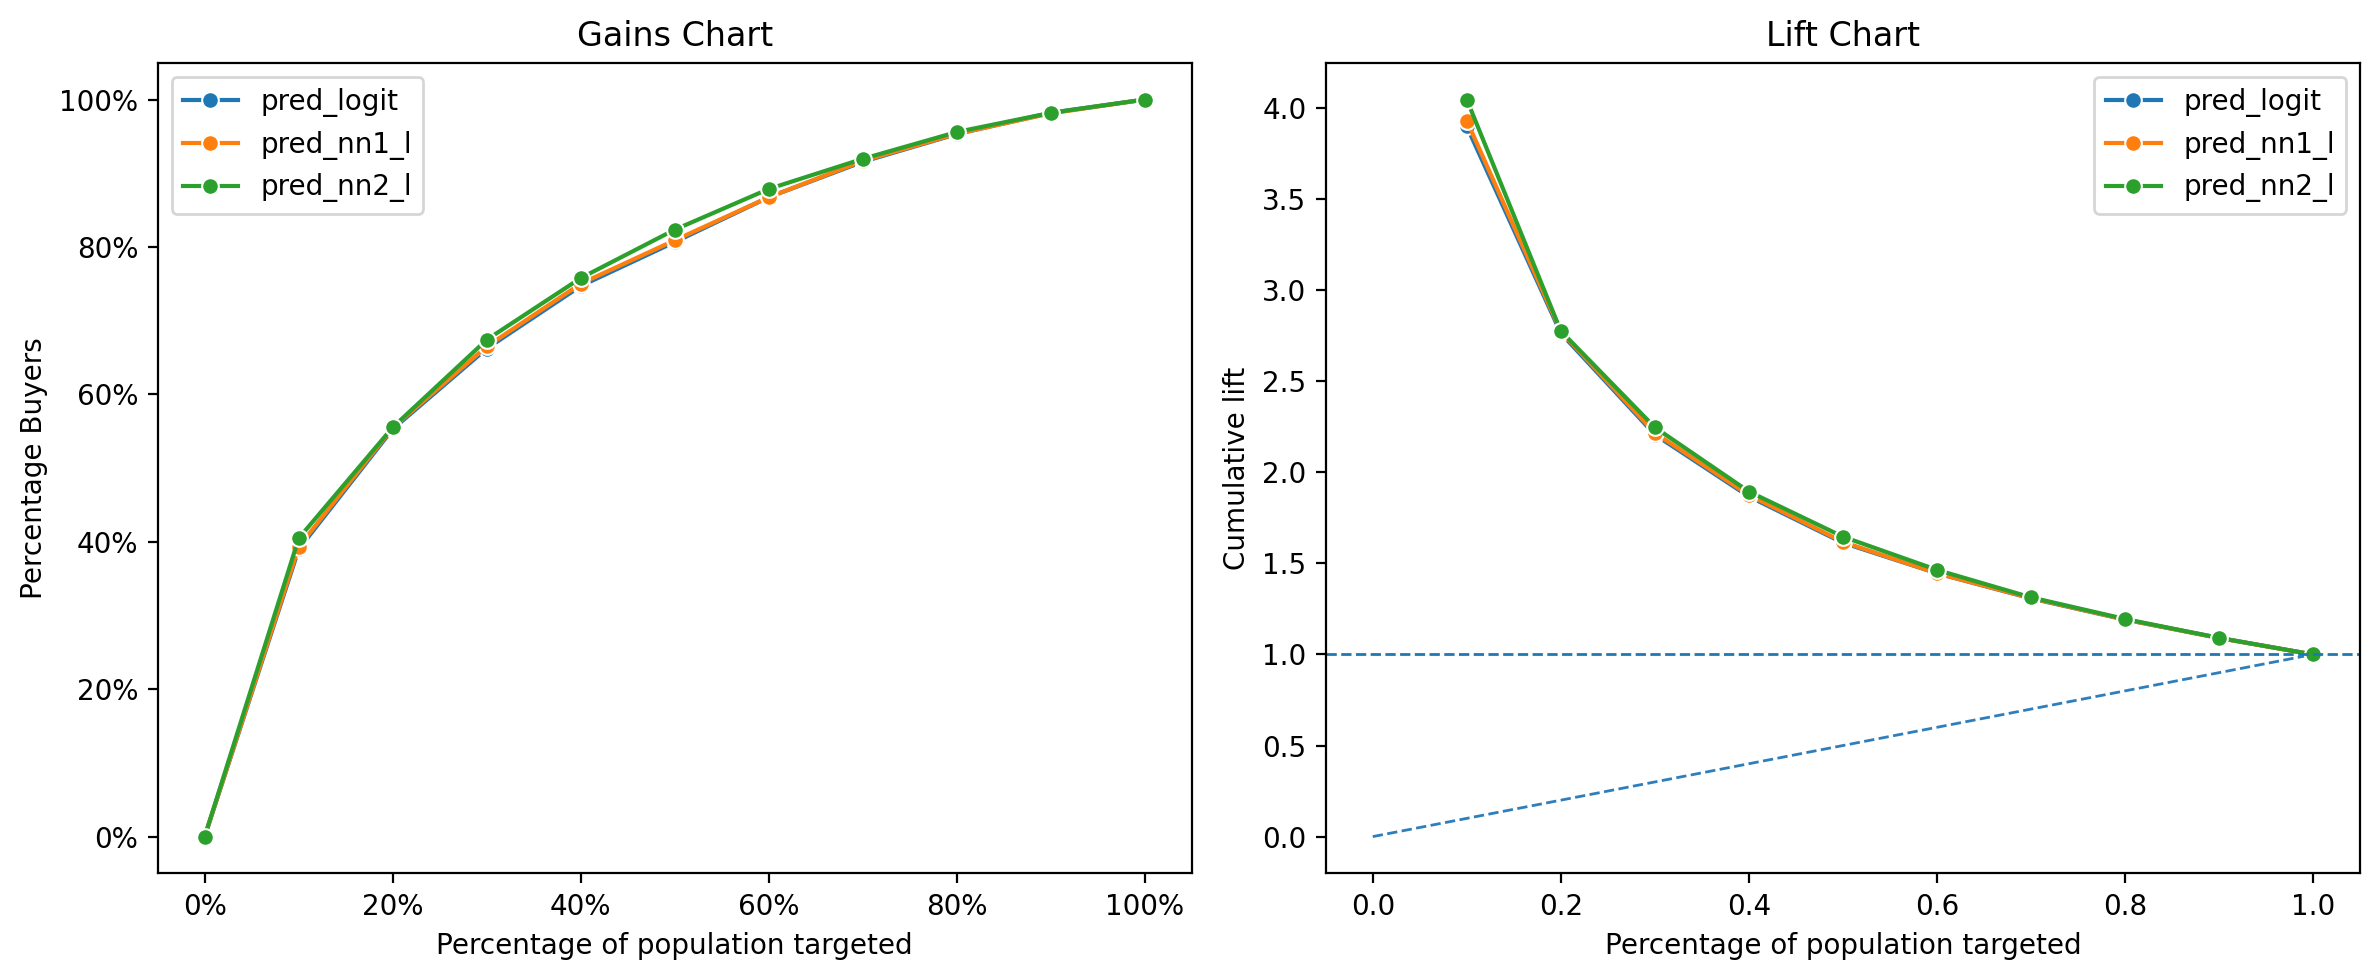

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns
rsm.gains_plot(intuit75k[intuit75k.training == 1], "res1", "Yes", ["pred_logit", "pred_nn1_l", "pred_nn2_l"], ax=axes[0] )
rsm.lift_plot(intuit75k[intuit75k.training == 1], "res1", "Yes", ["pred_logit", "pred_nn1_l", "pred_nn2_l"], ax=axes[1] )
axes[0].set_title("Gains Chart")
axes[1].set_title("Lift Chart")
plt.tight_layout()
plt.show()

- The gains chart compares the performance of logistic regression (pred_logit) with neural networks having 1 node (pred_nn1_l) and 2 nodes (pred_nn2_l). 
- The NN models outperform logistic regression, with pred_nn2_l showing a slight edge over pred_nn1_l, confirming improved predictive power with an extra node.
- The Lift Chart shows that both neural network models (pred_nn1_l and pred_nn2_l) outperform logistic regression (pred_logit) across all population segments. 
- Lift decreases as more population is targeted, eventually converging to 1

##### NN model with 4 nodes

Multi-layer Perceptron (NN)
Data                 : intuit
Response variable    : res1
Level                : Yes
Explanatory variables: zip_bins, sex, bizflag, numords, dollars, last, sincepurch, version1, owntaxprod, upgraded
Model type           : classification
Nr. of features      : (10, 29)
Nr. of weights       : 120
Nr. of observations  : 52,500
Hidden_layer_sizes   : (4,)
Activation function  : tanh
Solver               : lbfgs
Alpha                : 0.0001
Batch size           : auto
Learning rate        : 0.001
Maximum iterations   : 1000000
random_state         : 1234
AUC                  : 0.771

Raw data             :
zip_bins  sex  bizflag  numords  dollars  last  sincepurch  version1  owntaxprod  upgraded
      18 Male        0        2    109.5     5          12         0           0         0
       1 Male        0        1     22.0    17           1         0           0         0
       3 Male        0        1     20.0    17          17         0           0         

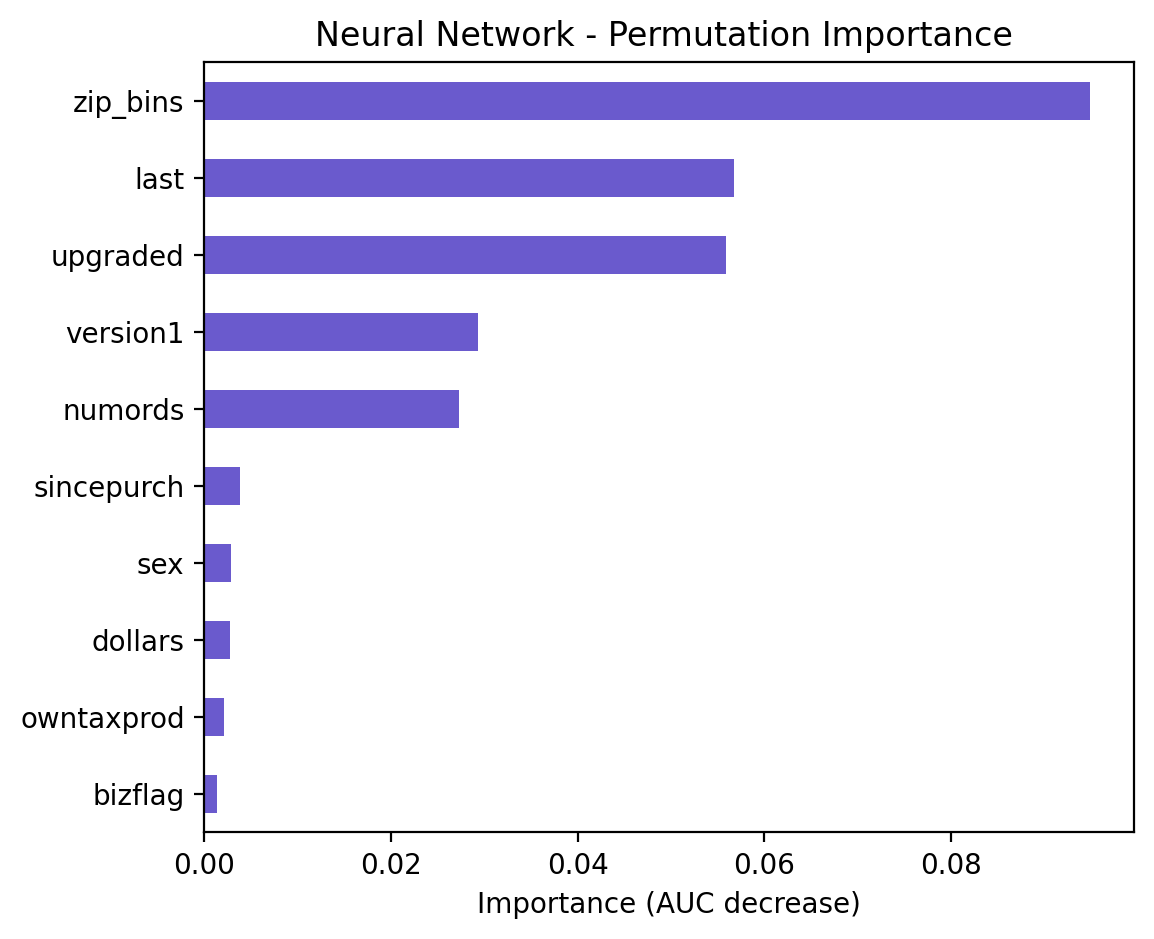

In [38]:
intuit75k["pred_nn4_l"] = nn_model_l((4,))

##### Gains and Lift graph for pred_logit, NN model Node-2 and NN model Node-4

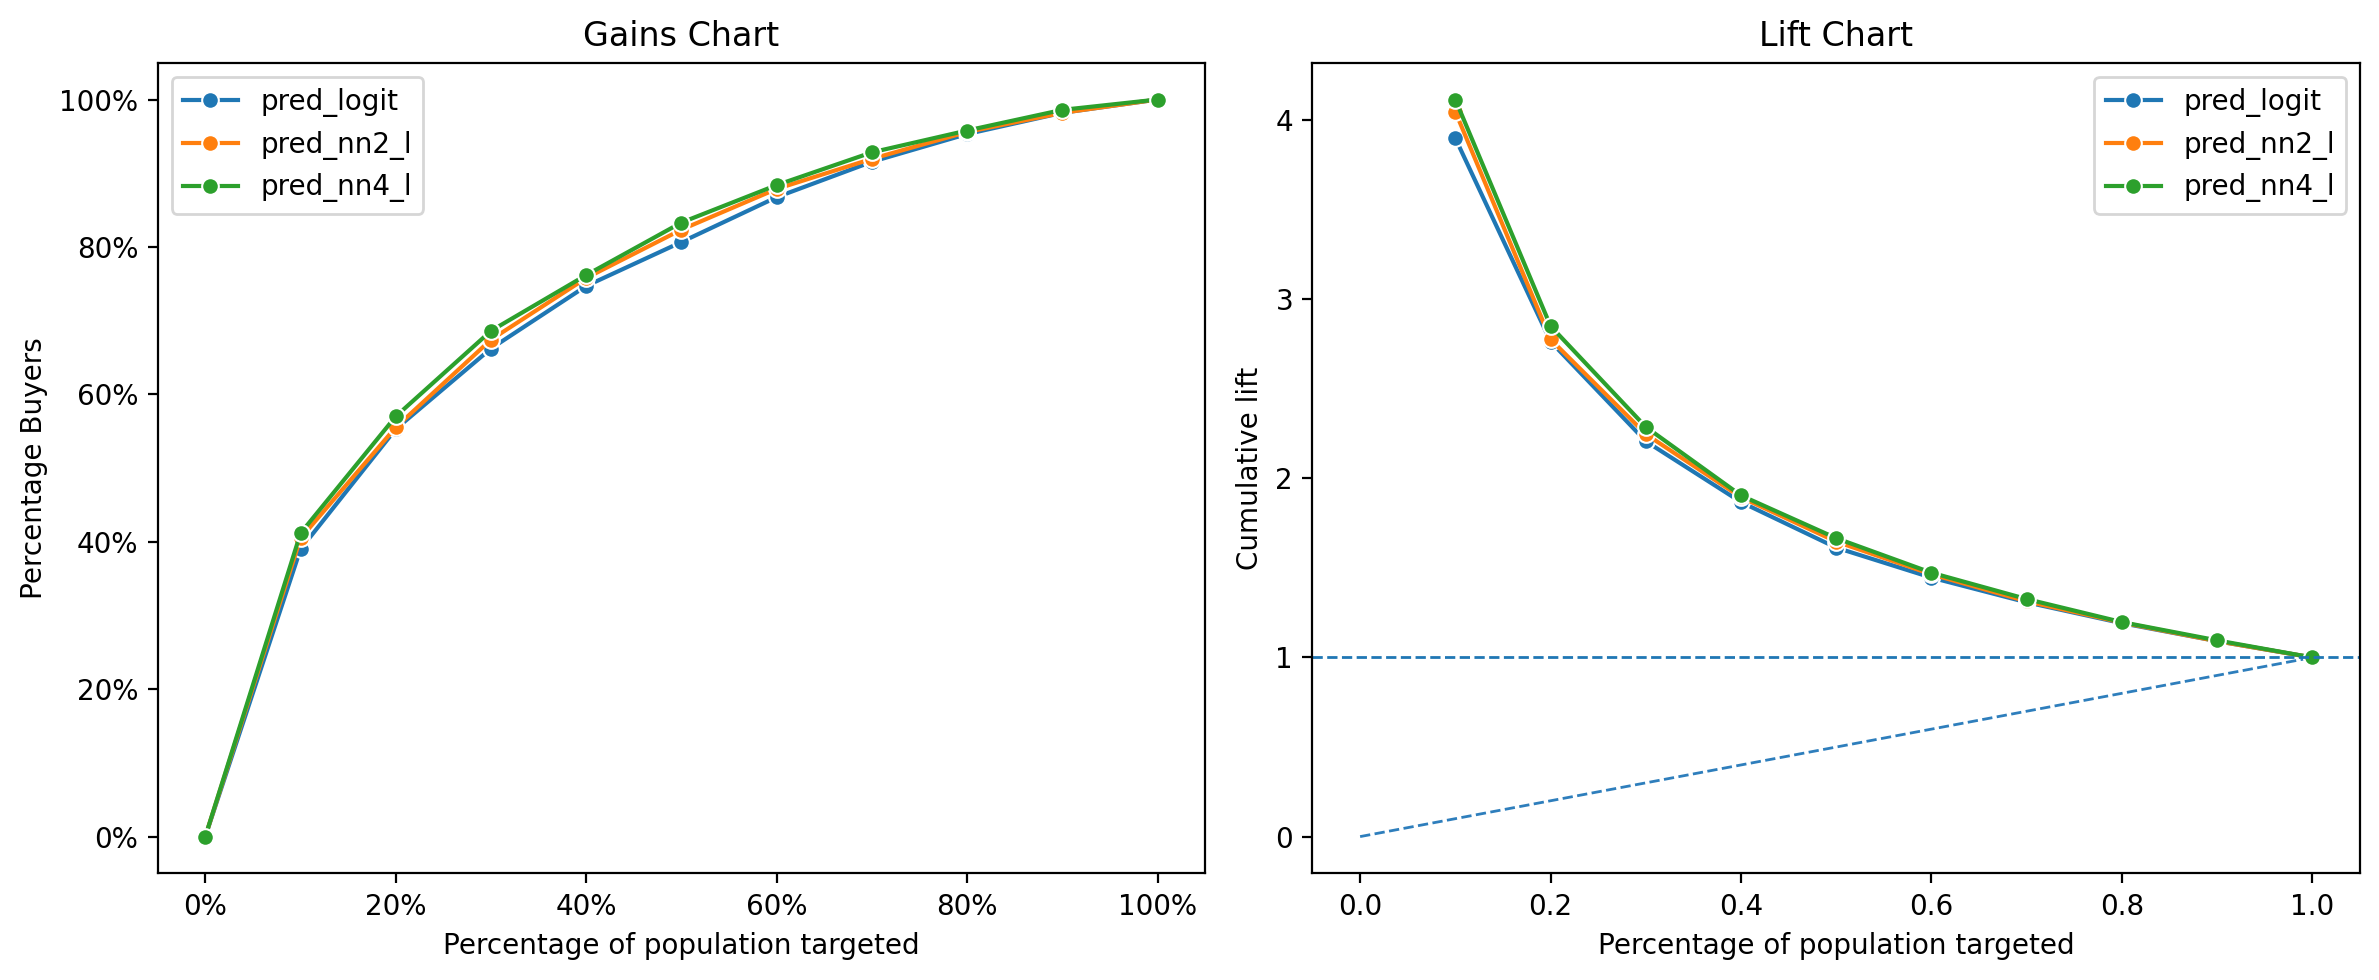

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns
rsm.gains_plot(intuit75k[intuit75k.training == 1], "res1", "Yes", ["pred_logit", "pred_nn2_l", "pred_nn4_l"], ax=axes[0] )
rsm.lift_plot(intuit75k[intuit75k.training == 1], "res1", "Yes", ["pred_logit", "pred_nn2_l", "pred_nn4_l"], ax=axes[1] )
axes[0].set_title("Gains Chart")
axes[1].set_title("Lift Chart")
plt.tight_layout()
plt.show()

##### NN model with 10 nodes

Multi-layer Perceptron (NN)
Data                 : intuit
Response variable    : res1
Level                : Yes
Explanatory variables: zip_bins, sex, bizflag, numords, dollars, last, sincepurch, version1, owntaxprod, upgraded
Model type           : classification
Nr. of features      : (10, 29)
Nr. of weights       : 300
Nr. of observations  : 52,500
Hidden_layer_sizes   : (10,)
Activation function  : tanh
Solver               : lbfgs
Alpha                : 0.0001
Batch size           : auto
Learning rate        : 0.001
Maximum iterations   : 1000000
random_state         : 1234
AUC                  : 0.785

Raw data             :
zip_bins  sex  bizflag  numords  dollars  last  sincepurch  version1  owntaxprod  upgraded
      18 Male        0        2    109.5     5          12         0           0         0
       1 Male        0        1     22.0    17           1         0           0         0
       3 Male        0        1     20.0    17          17         0           0        

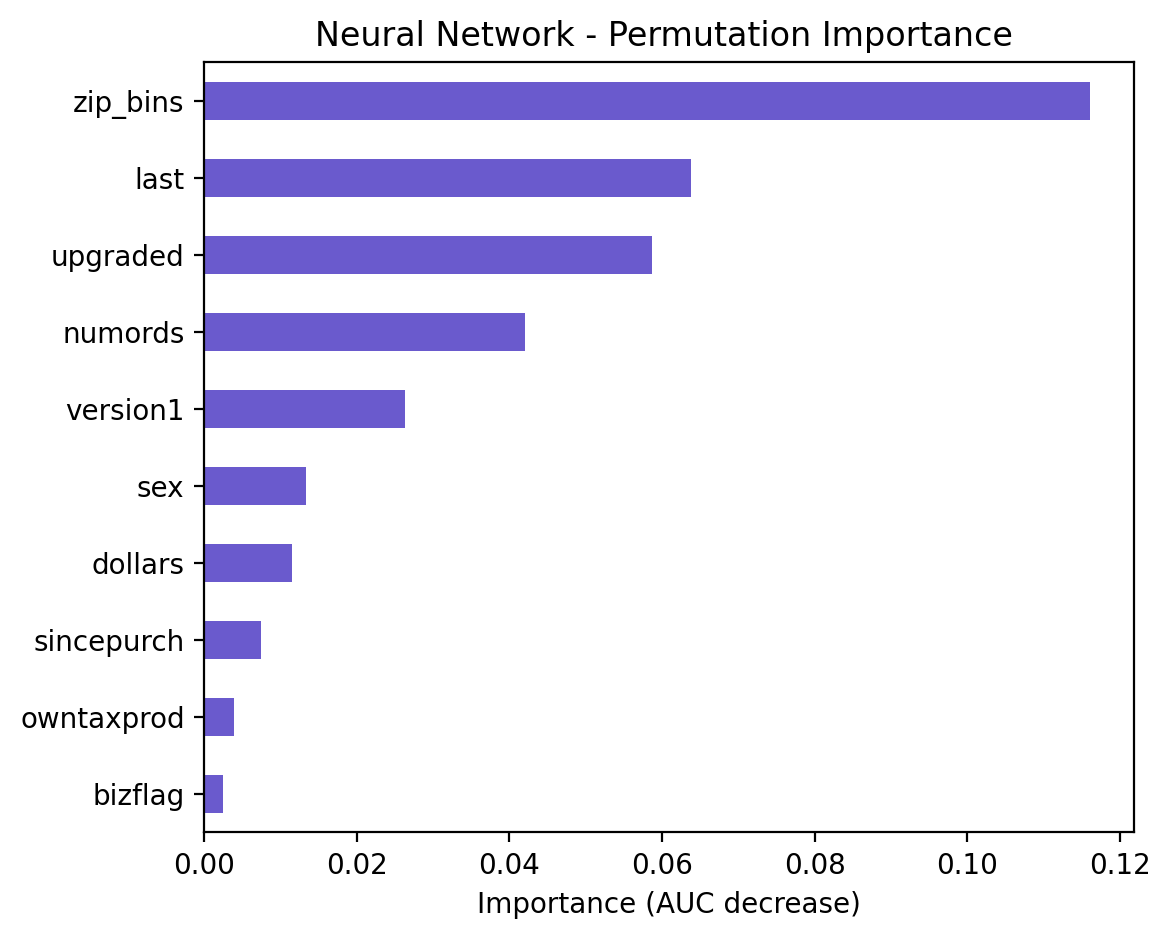

In [40]:
intuit75k["pred_nn10_l"] = nn_model_l((10,))

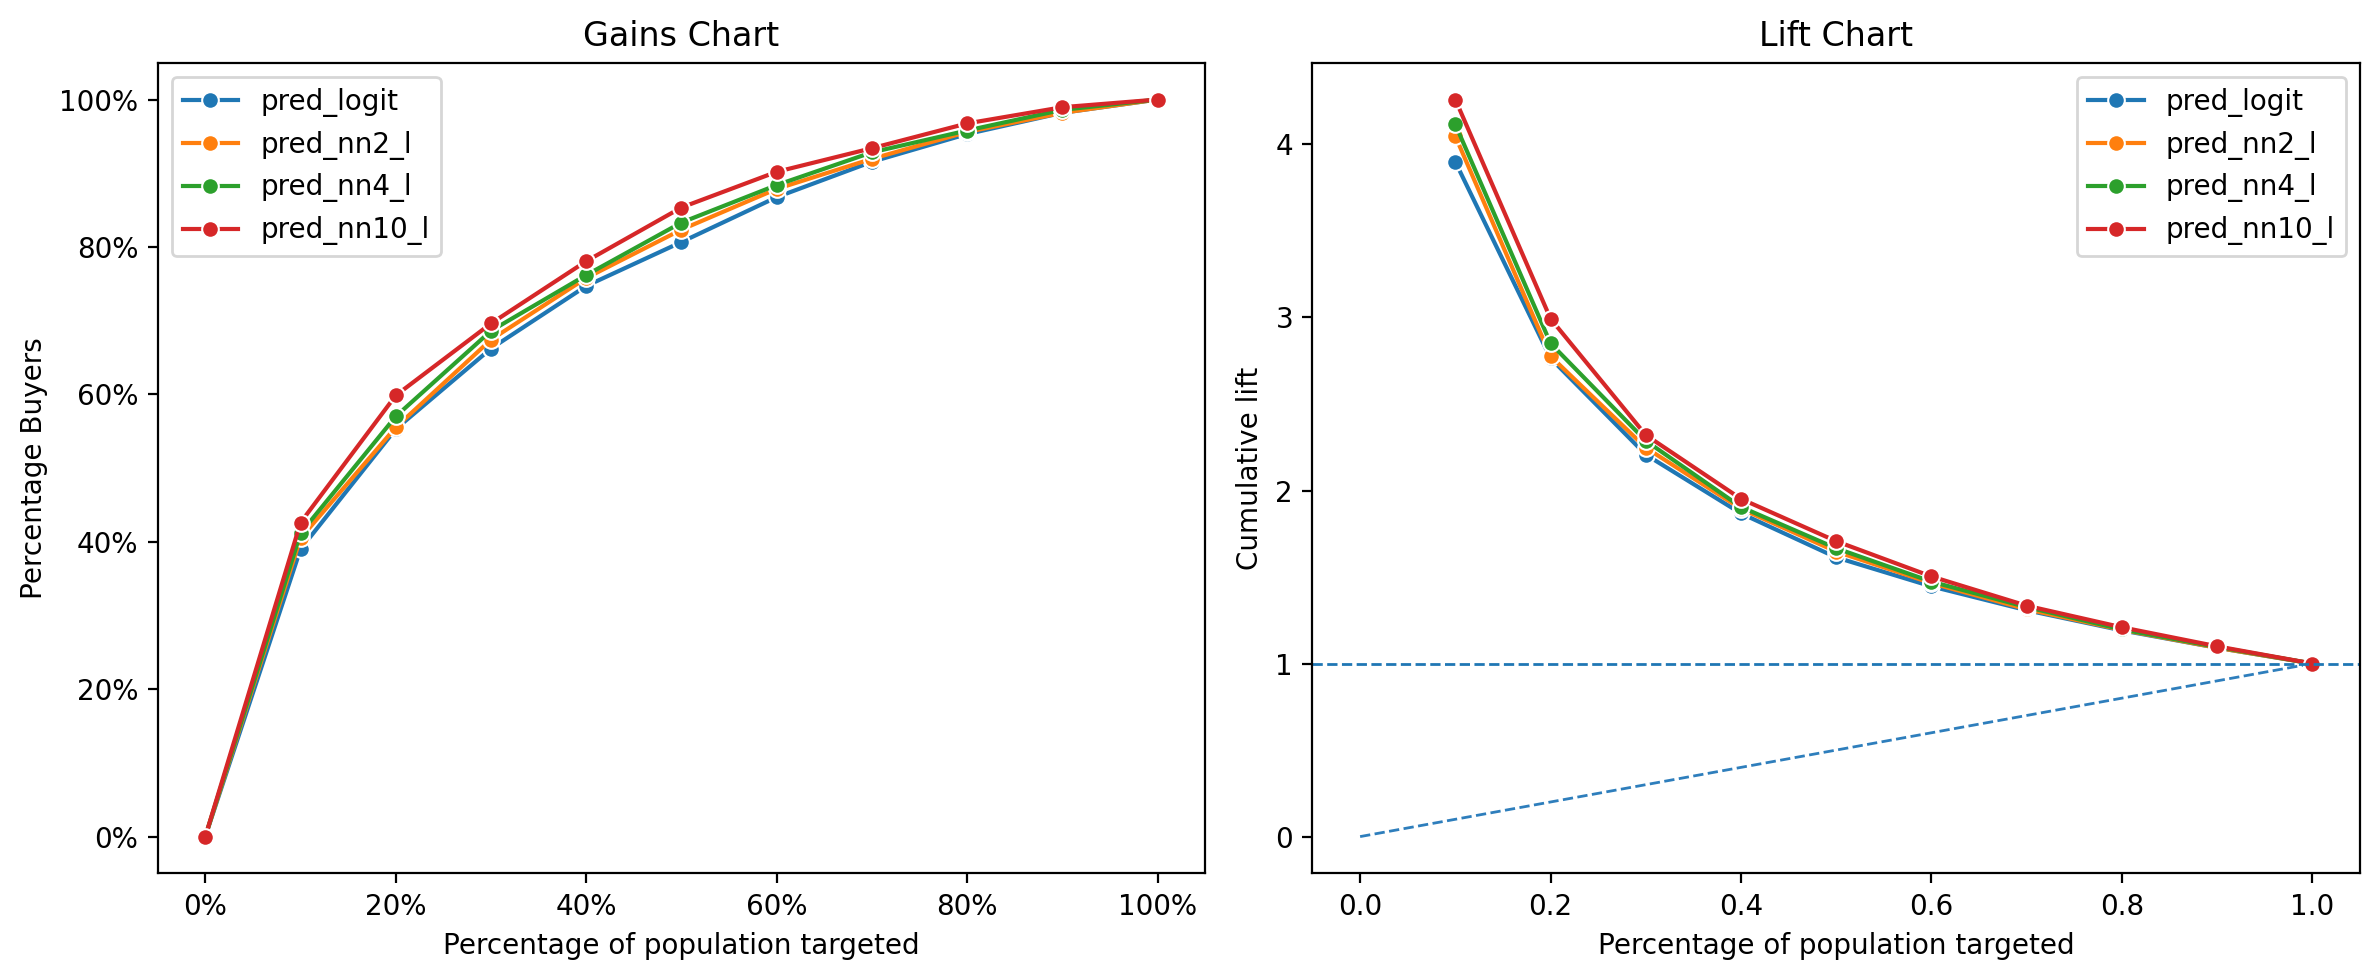

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns
rsm.gains_plot(intuit75k[intuit75k.training == 1], "res1", "Yes", ["pred_logit", "pred_nn2_l", "pred_nn4_l", "pred_nn10_l"], ax=axes[0] )
rsm.lift_plot(intuit75k[intuit75k.training == 1], "res1", "Yes", ["pred_logit", "pred_nn2_l", "pred_nn4_l", "pred_nn10_l"], ax=axes[1] )
axes[0].set_title("Gains Chart")
axes[1].set_title("Lift Chart")
plt.tight_layout()
plt.show()

- The Gains Chart (left) shows that as the percentage of the population targeted increases, neural network models (pred_nn2_l, pred_nn4_l, pred_nn10_l) capture more buyers than logistic regression (pred_logit).
- The 10-node NN model (pred_nn10_l) performs best, followed by the 4-node and 2-node models, indicating that more nodes improve prediction accuracy.
- The Lift Chart (right) highlights that all NN models provide a higher lift than logistic regression, especially in the top 10-20% of the population. 
- The 10-node model (pred_nn10_l) achieves the highest initial lift, suggesting superior ranking ability. 
- However, as more of the population is included, all models converge to a lift of 1, meaning no additional predictive power beyond random selection.

#### Checking for model overfitting

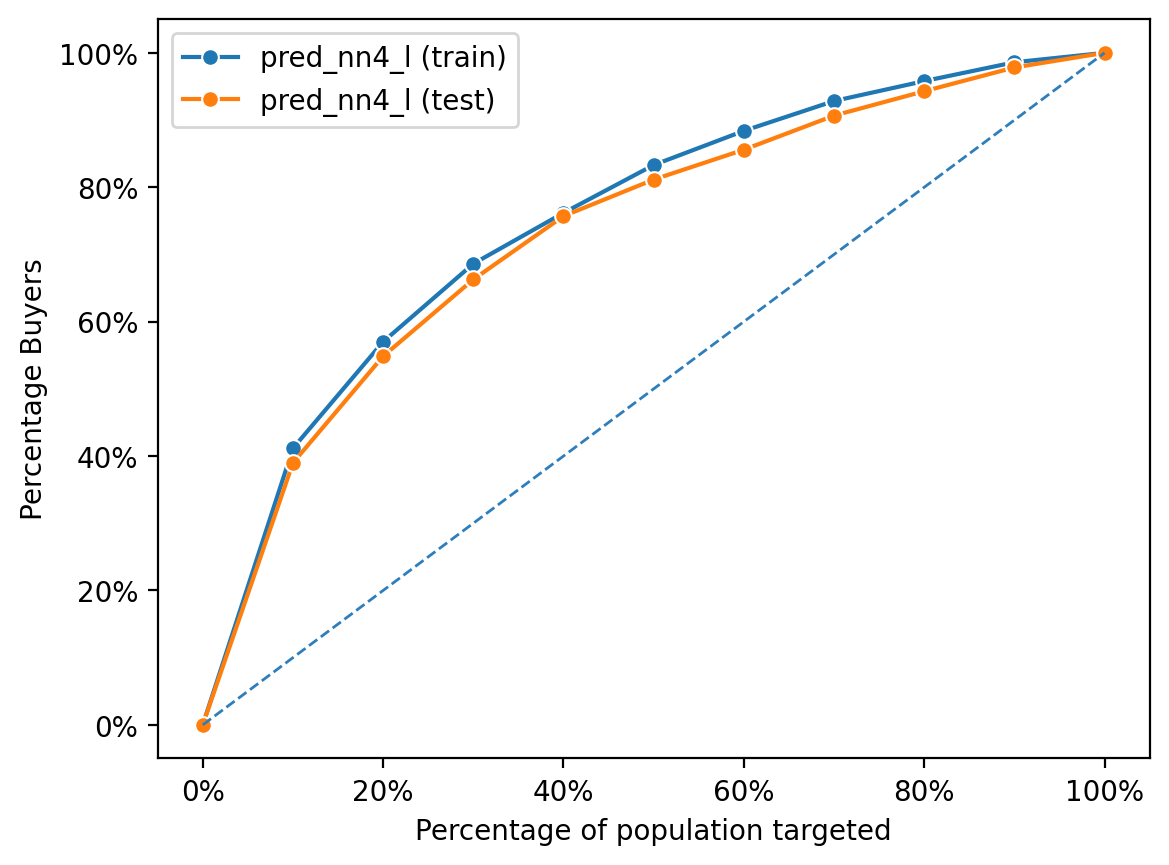

In [42]:
dct = {"train": intuit75k[intuit75k.training == 1], "test": intuit75k[intuit75k.training == 0]}
fig = rsm.gains_plot(dct, "res1", "Yes", "pred_nn4_l")

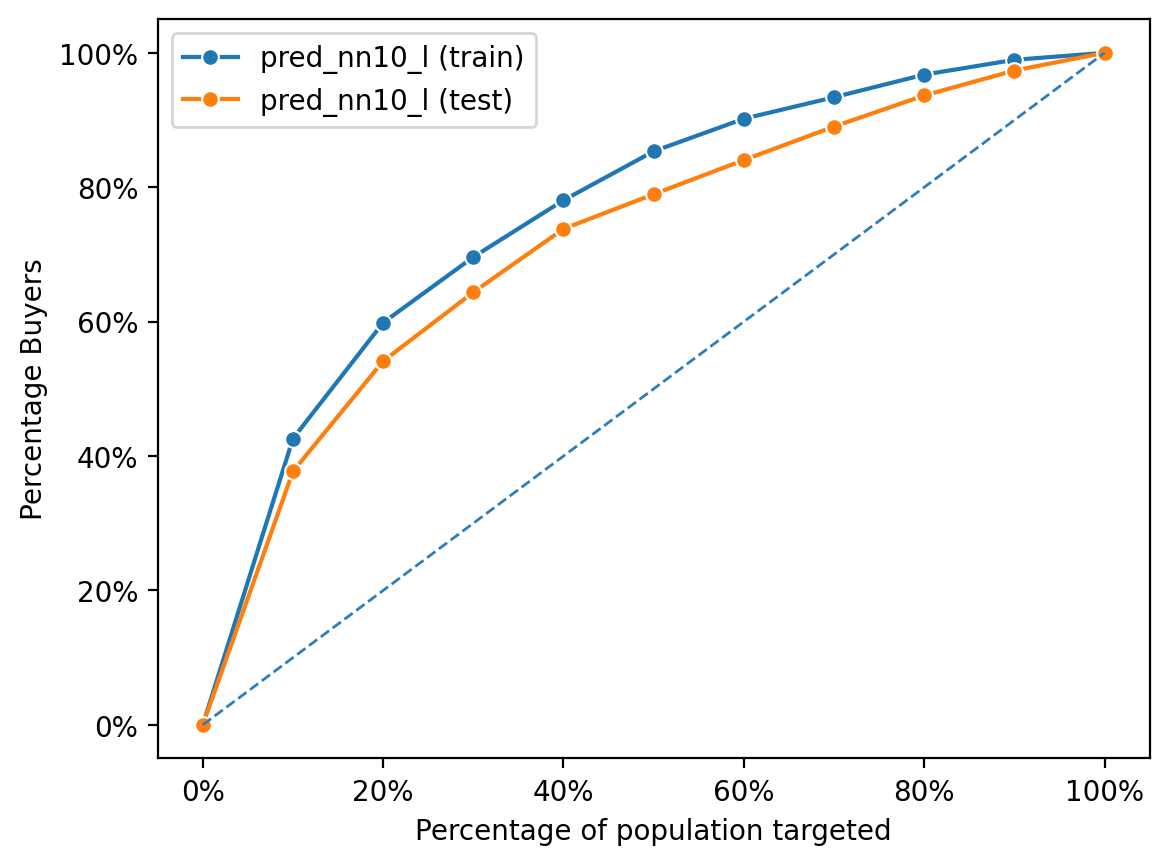

In [43]:
dct = {"train": intuit75k[intuit75k.training == 1], "test": intuit75k[intuit75k.training == 0]}
fig = rsm.gains_plot(dct, "res1", "Yes", "pred_nn10_l")

- The Gains Charts compare the training and test performance of the 10-node NN model (pred_nn10_l) and the 4-node NN model (pred_nn4_l)
- In both cases, the training curve is above the test curve, indicating that the models perform better on the training data. 
- The gap is more noticeable for pred_nn10_l, suggesting possible overfitting, while pred_nn4_l maintains closer alignment, implying better generalization.

### Further exploring Complex Models

##### NN model with 10 nodes 10 layers

Multi-layer Perceptron (NN)
Data                 : intuit
Response variable    : res1
Level                : Yes
Explanatory variables: zip_bins, sex, bizflag, numords, dollars, last, sincepurch, version1, owntaxprod, upgraded
Model type           : classification
Nr. of features      : (10, 29)
Nr. of weights       : 400
Nr. of observations  : 52,500
Hidden_layer_sizes   : (10, 10)
Activation function  : tanh
Solver               : lbfgs
Alpha                : 0.0001
Batch size           : auto
Learning rate        : 0.001
Maximum iterations   : 1000000
random_state         : 1234
AUC                  : 0.826

Raw data             :
zip_bins  sex  bizflag  numords  dollars  last  sincepurch  version1  owntaxprod  upgraded
      18 Male        0        2    109.5     5          12         0           0         0
       1 Male        0        1     22.0    17           1         0           0         0
       3 Male        0        1     20.0    17          17         0           0     

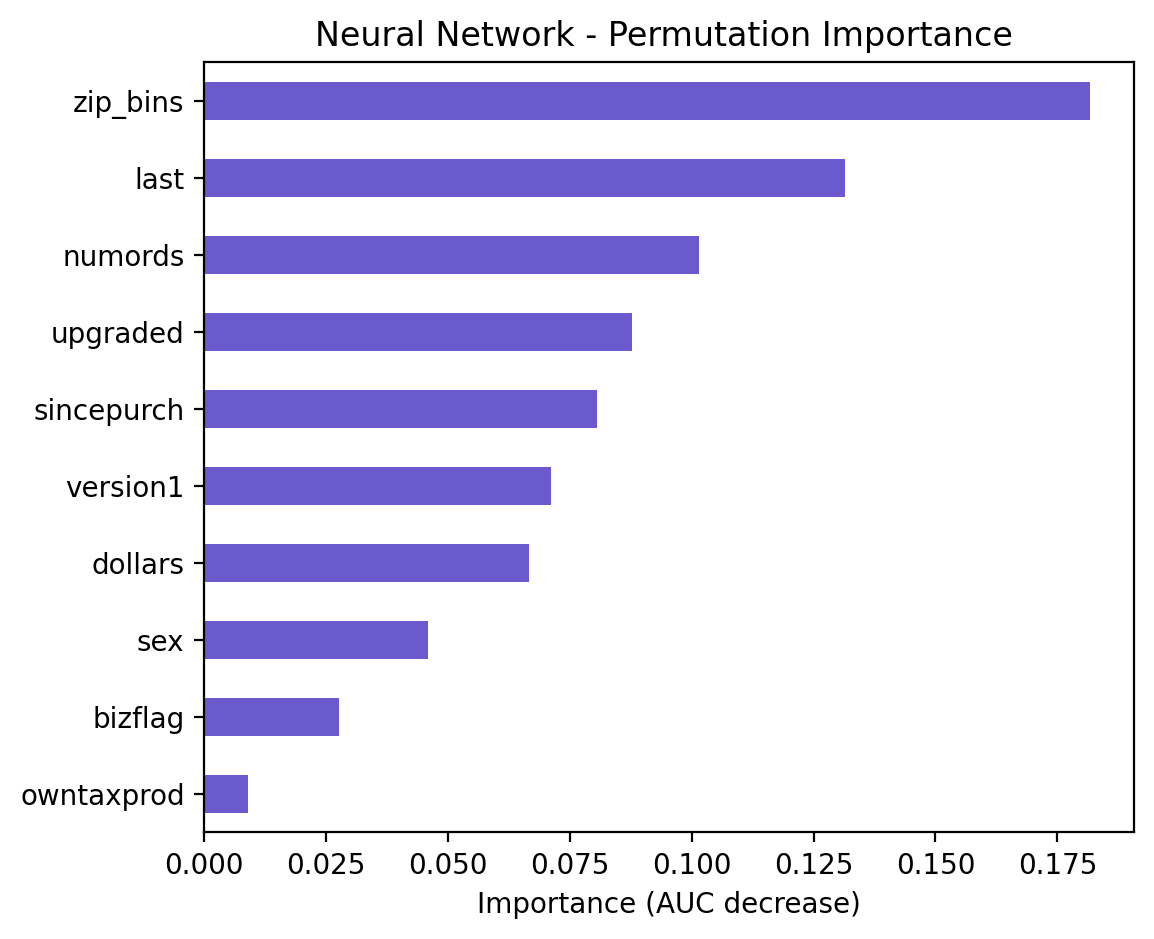

In [44]:
intuit75k["pred_nn10_10_l"] = nn_model_l((10,10))

##### NN model with 15 nodes

Multi-layer Perceptron (NN)
Data                 : intuit
Response variable    : res1
Level                : Yes
Explanatory variables: zip_bins, sex, bizflag, numords, dollars, last, sincepurch, version1, owntaxprod, upgraded
Model type           : classification
Nr. of features      : (10, 29)
Nr. of weights       : 450
Nr. of observations  : 52,500
Hidden_layer_sizes   : (15,)
Activation function  : tanh
Solver               : lbfgs
Alpha                : 0.0001
Batch size           : auto
Learning rate        : 0.001
Maximum iterations   : 1000000
random_state         : 1234
AUC                  : 0.826

Raw data             :
zip_bins  sex  bizflag  numords  dollars  last  sincepurch  version1  owntaxprod  upgraded
      18 Male        0        2    109.5     5          12         0           0         0
       1 Male        0        1     22.0    17           1         0           0         0
       3 Male        0        1     20.0    17          17         0           0        

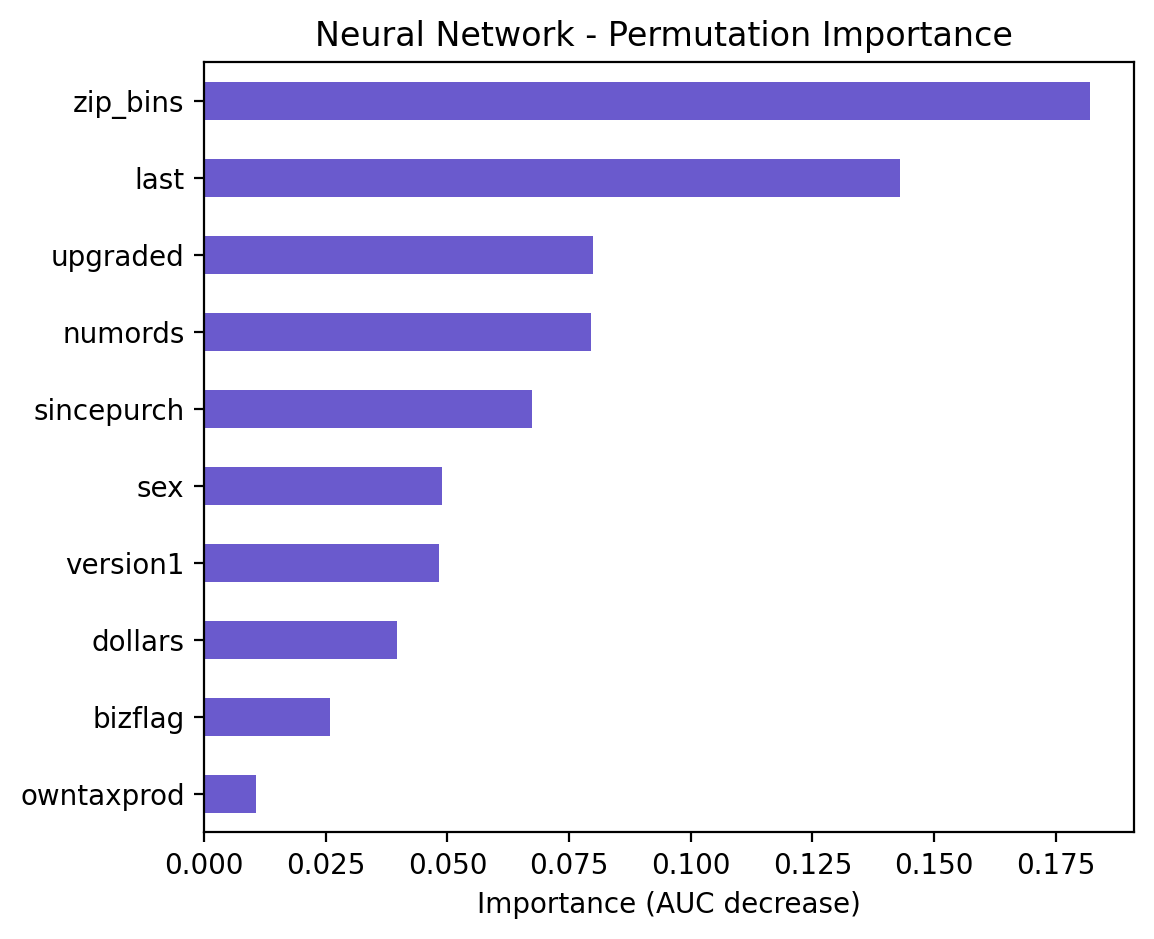

In [45]:
intuit75k["pred_nn15_l"] = nn_model_l((15,))

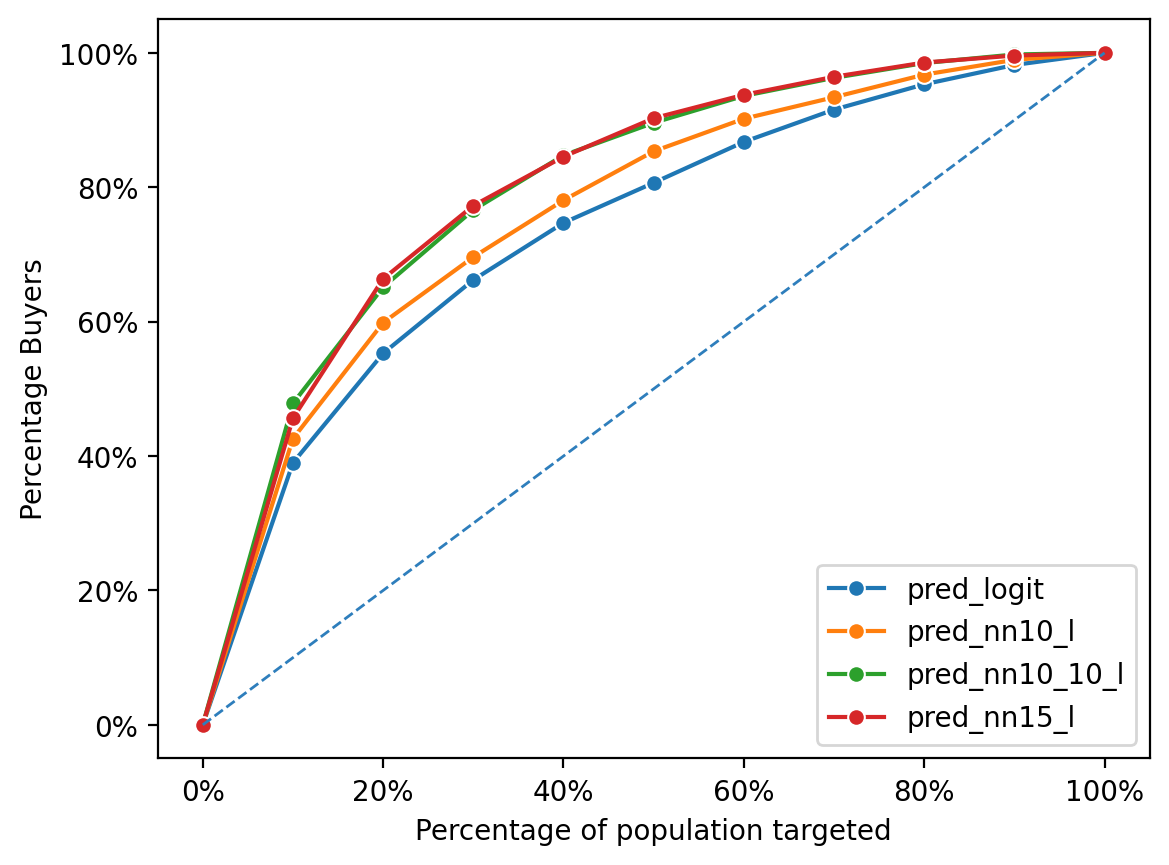

In [46]:
fig = rsm.gains_plot(intuit75k[intuit75k.training == 1], "res1", "Yes", ["pred_logit", "pred_nn10_l", "pred_nn10_10_l", "pred_nn15_l"])

- Complex models show diminishing returns, with 10-layer and 15-node models having similar AUC (0.826), suggesting overfitting.
- Gains plot reveals marginal improvement over simpler models, indicating they may be memorizing noise rather than generalizing.
- Regularization (dropout, L2) and validation testing are needed to confirm and mitigate overfitting.

#### Checking overfitting for NN model (15,)

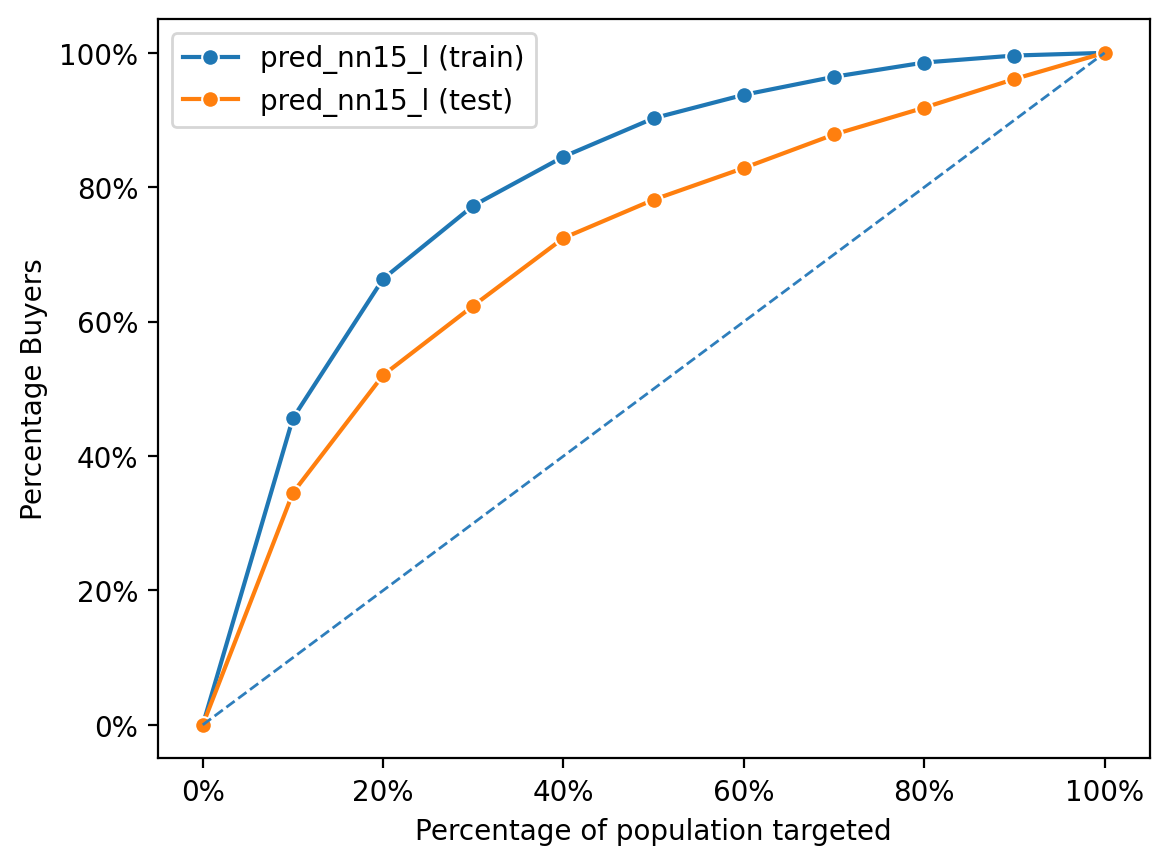

In [47]:
dct = {"train": intuit75k[intuit75k.training == 1], "test": intuit75k[intuit75k.training == 0]}
fig = rsm.gains_plot(dct, "res1", "Yes", "pred_nn15_l")

- Train-test gap confirms overfitting – the model performs well on training data (blue curve) but struggles on test data (orange curve).
- Poor generalization – the test set curve is significantly lower, indicating the model memorized patterns rather than learning general rules.

### Model Tuning

We will perform cross-validation on neural network models with varying node configurations to identify the best-fitting model.

In [48]:
base_nn = rsm.model.mlp(
    data={"intuit": train_data},
    rvar="res1",
    lev="Yes",
    evar=evar,
    solver="lbfgs",
    hidden_layer_sizes=(1,),
    mod_type="classification",
)
base_nn.summary()

Multi-layer Perceptron (NN)
Data                 : intuit
Response variable    : res1
Level                : Yes
Explanatory variables: zip_bins, sex, bizflag, numords, dollars, last, sincepurch, version1, owntaxprod, upgraded
Model type           : classification
Nr. of features      : (10, 29)
Nr. of weights       : 30
Nr. of observations  : 52,500
Hidden_layer_sizes   : (1,)
Activation function  : tanh
Solver               : lbfgs
Alpha                : 0.0001
Batch size           : auto
Learning rate        : 0.001
Maximum iterations   : 1000000
random_state         : 1234
AUC                  : 0.756

Raw data             :
zip_bins  sex  bizflag  numords  dollars  last  sincepurch  version1  owntaxprod  upgraded
      18 Male        0        2    109.5     5          12         0           0         0
       1 Male        0        1     22.0    17           1         0           0         0
       3 Male        0        1     20.0    17          17         0           0         1

In [49]:
hls = [(2,), (3,), (3, 3), (4,), (5,), (10, )]

param_grid = {"hidden_layer_sizes": hls}
scoring = {"AUC": "roc_auc"}

base_nn_cv = GridSearchCV(
    base_nn.fitted, param_grid, scoring=scoring, cv=5, n_jobs=4, refit="AUC", verbose=5
)

base_nn.data_onehot.mean().round(3)

bizflag        0.244
numords        0.000
dollars       -0.000
last          -0.000
sincepurch     0.000
version1       0.213
owntaxprod     0.029
upgraded       0.207
zip_bins_2     0.050
zip_bins_3     0.049
zip_bins_4     0.050
zip_bins_5     0.050
zip_bins_6     0.050
zip_bins_7     0.051
zip_bins_8     0.051
zip_bins_9     0.049
zip_bins_10    0.050
zip_bins_11    0.049
zip_bins_12    0.050
zip_bins_13    0.050
zip_bins_14    0.050
zip_bins_15    0.050
zip_bins_16    0.050
zip_bins_17    0.050
zip_bins_18    0.051
zip_bins_19    0.050
zip_bins_20    0.050
sex_Male       0.662
sex_Unknown    0.128
dtype: float64

In [50]:
base_nn_cv.fit(base_nn.data_onehot, base_nn.data.res1)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5,
             estimator=MLPClassifier(activation='tanh', hidden_layer_sizes=(1,),
                                     max_iter=1000000, random_state=1234,
                                     solver='lbfgs'),
             n_jobs=4,
             param_grid={'hidden_layer_sizes': [(2,), (3,), (3, 3), (4,), (5,),
                                                (10,)]},
             refit='AUC', scoring={'AUC': 'roc_auc'}, verbose=5)

In [51]:
base_nn.data_onehot.head()

,bizflag,numords,dollars,last,sincepurch,version1,owntaxprod,upgraded,zip_bins_2,zip_bins_3,...,zip_bins_13,zip_bins_14,zip_bins_15,zip_bins_16,zip_bins_17,zip_bins_18,zip_bins_19,zip_bins_20,sex_Male,sex_Unknown
0,0,-0.057079,0.207902,-1.137183,-0.360809,0,0,0,False,False,...,False,False,False,False,False,True,False,False,True,False
3,0,-0.863720,-0.873735,0.119783,-1.458194,0,0,0,False,False,...,False,False,False,False,False,False,False,False,True,False
5,0,-0.863720,-0.898458,0.119783,0.138003,0,0,1,False,True,...,False,False,False,False,False,False,False,False,True,False
7,1,-0.863720,-0.842831,-1.241930,0.138003,1,0,0,False,False,...,False,False,False,False,False,False,False,False,True,False
9,0,0.749561,-0.237115,-0.613447,-0.660096,0,0,0,False,False,...,False,False,False,False,False,False,False,False,True,False


In [52]:
pd.DataFrame(base_nn_cv.cv_results_).iloc[:, 5:].sort_values("rank_test_AUC")

,params,split0_test_AUC,split1_test_AUC,split2_test_AUC,split3_test_AUC,split4_test_AUC,mean_test_AUC,std_test_AUC,rank_test_AUC
0,"{'hidden_layer_sizes': (2,)}",0.740398,0.763174,0.767984,0.749139,0.764637,0.757066,0.010531,1
1,"{'hidden_layer_sizes': (3,)}",0.743542,0.763141,0.760210,0.741192,0.754323,0.752482,0.008765,2
2,"{'hidden_layer_sizes': (3, 3)}",0.731896,0.766128,0.752801,0.746326,0.763525,0.752135,0.012404,3
3,"{'hidden_layer_sizes': (4,)}",0.746227,0.755930,0.758463,0.741529,0.756560,0.751742,0.006643,4
4,"{'hidden_layer_sizes': (5,)}",0.736144,0.754043,0.752797,0.744225,0.749762,0.747394,0.006567,5
5,"{'hidden_layer_sizes': (10,)}",0.705988,0.734875,0.737048,0.731815,0.731710,0.728287,0.011328,6


- After testing various models, they either align with logistic regression or overfit when they don’t. 
- The low AUC values (0.728–0.757) indicate poor performance with minimal improvement across architectures. 
- Larger models overfit, while smaller ones perform better, suggesting that increased complexity does not enhance generalization. 
- To improve results, we are experimenting with the Adam solver for better optimization.

### Adam Solver

##### Neural Networks with adam Solver

In [53]:
def nn_model_size( hls, evar=evar, act="tanh", solver="adam"):
    nnr = rsm.model.mlp(
        data={"intuit": train_data},
        rvar="res1",
        lev="Yes",
        evar=evar,
        activation=act,
        solver=solver,
        hidden_layer_sizes=hls,
        mod_type="classification",
    )
    nnr.summary()
    #pred = nnr.predict(intuit75k)
    nnr.plot(plots="vimp")
    plt.title("Neural Network - Permutation Importance ")
    plt.show()
    return nnr.predict(intuit75k)["prediction"] 

##### NN Model with 1 Node

Multi-layer Perceptron (NN)
Data                 : intuit
Response variable    : res1
Level                : Yes
Explanatory variables: zip_bins, sex, bizflag, numords, dollars, last, sincepurch, version1, owntaxprod, upgraded
Model type           : classification
Nr. of features      : (10, 29)
Nr. of weights       : 30
Nr. of observations  : 52,500
Hidden_layer_sizes   : (1,)
Activation function  : tanh
Solver               : adam
Alpha                : 0.0001
Batch size           : auto
Learning rate        : 0.001
Maximum iterations   : 1000000
random_state         : 1234
AUC                  : 0.753

Raw data             :
zip_bins  sex  bizflag  numords  dollars  last  sincepurch  version1  owntaxprod  upgraded
      18 Male        0        2    109.5     5          12         0           0         0
       1 Male        0        1     22.0    17           1         0           0         0
       3 Male        0        1     20.0    17          17         0           0         1


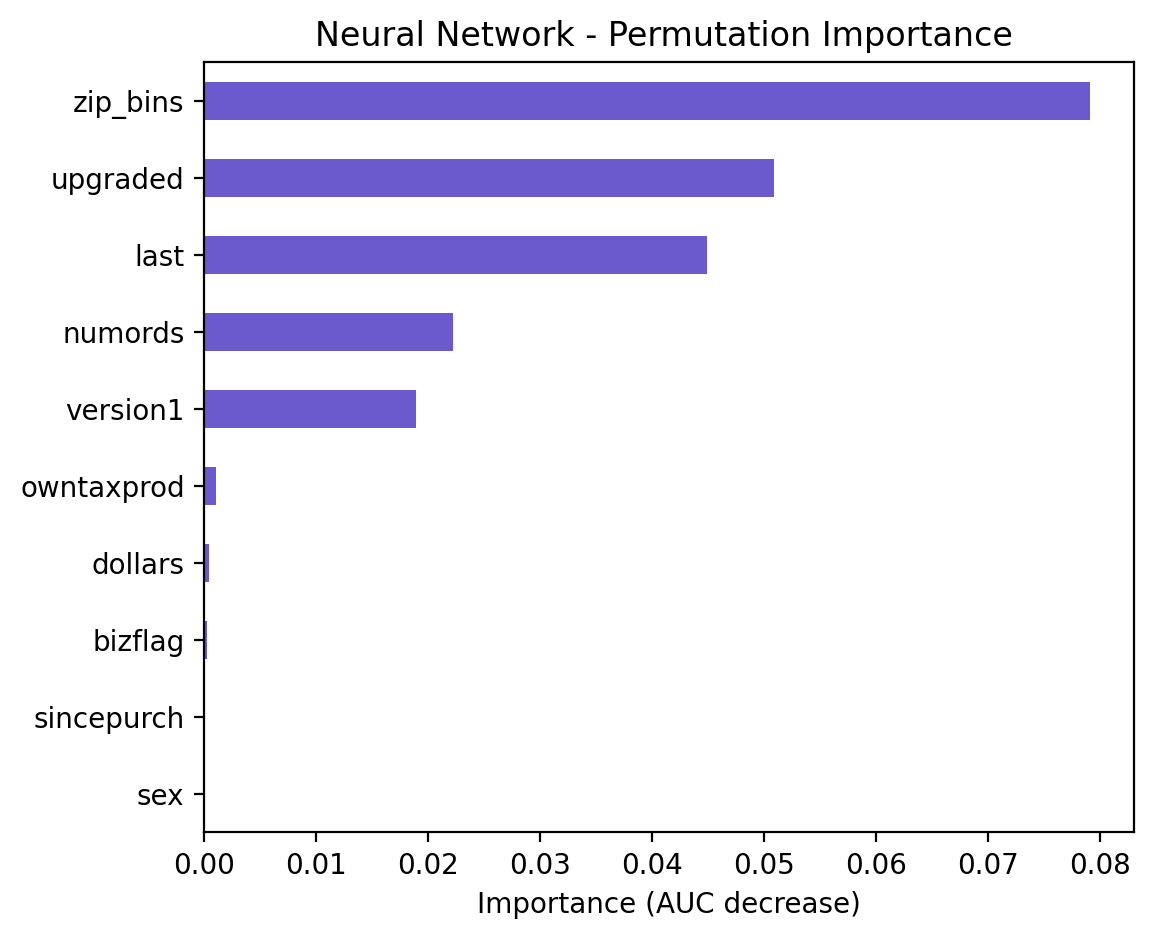

In [54]:
intuit75k["pred_nn1"] = nn_model_size((1,))

##### NN Model with 2 Node

Multi-layer Perceptron (NN)
Data                 : intuit
Response variable    : res1
Level                : Yes
Explanatory variables: zip_bins, sex, bizflag, numords, dollars, last, sincepurch, version1, owntaxprod, upgraded
Model type           : classification
Nr. of features      : (10, 29)
Nr. of weights       : 60
Nr. of observations  : 52,500
Hidden_layer_sizes   : (2,)
Activation function  : tanh
Solver               : adam
Alpha                : 0.0001
Batch size           : auto
Learning rate        : 0.001
Maximum iterations   : 1000000
random_state         : 1234
AUC                  : 0.756

Raw data             :
zip_bins  sex  bizflag  numords  dollars  last  sincepurch  version1  owntaxprod  upgraded
      18 Male        0        2    109.5     5          12         0           0         0
       1 Male        0        1     22.0    17           1         0           0         0
       3 Male        0        1     20.0    17          17         0           0         1


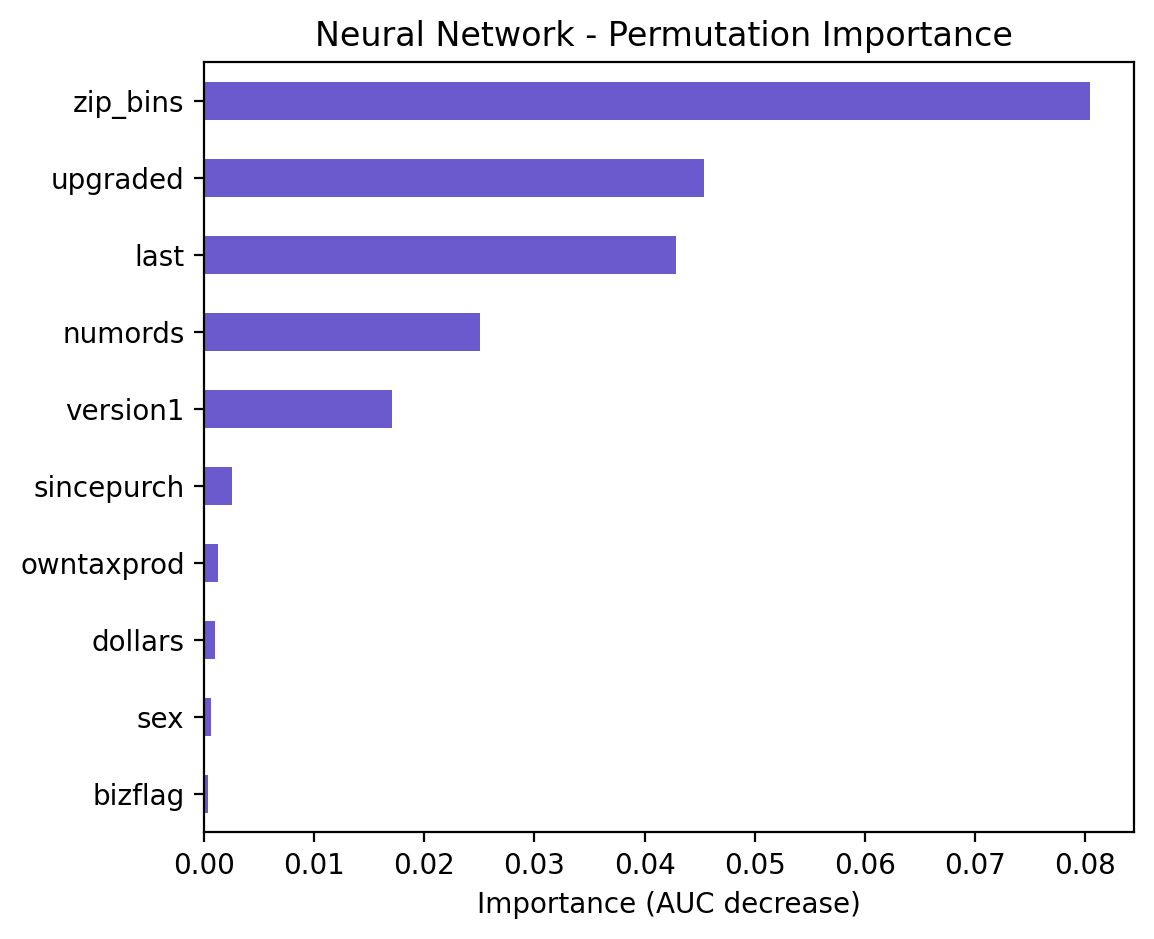

In [55]:
intuit75k["pred_nn2"] = nn_model_size((2,))

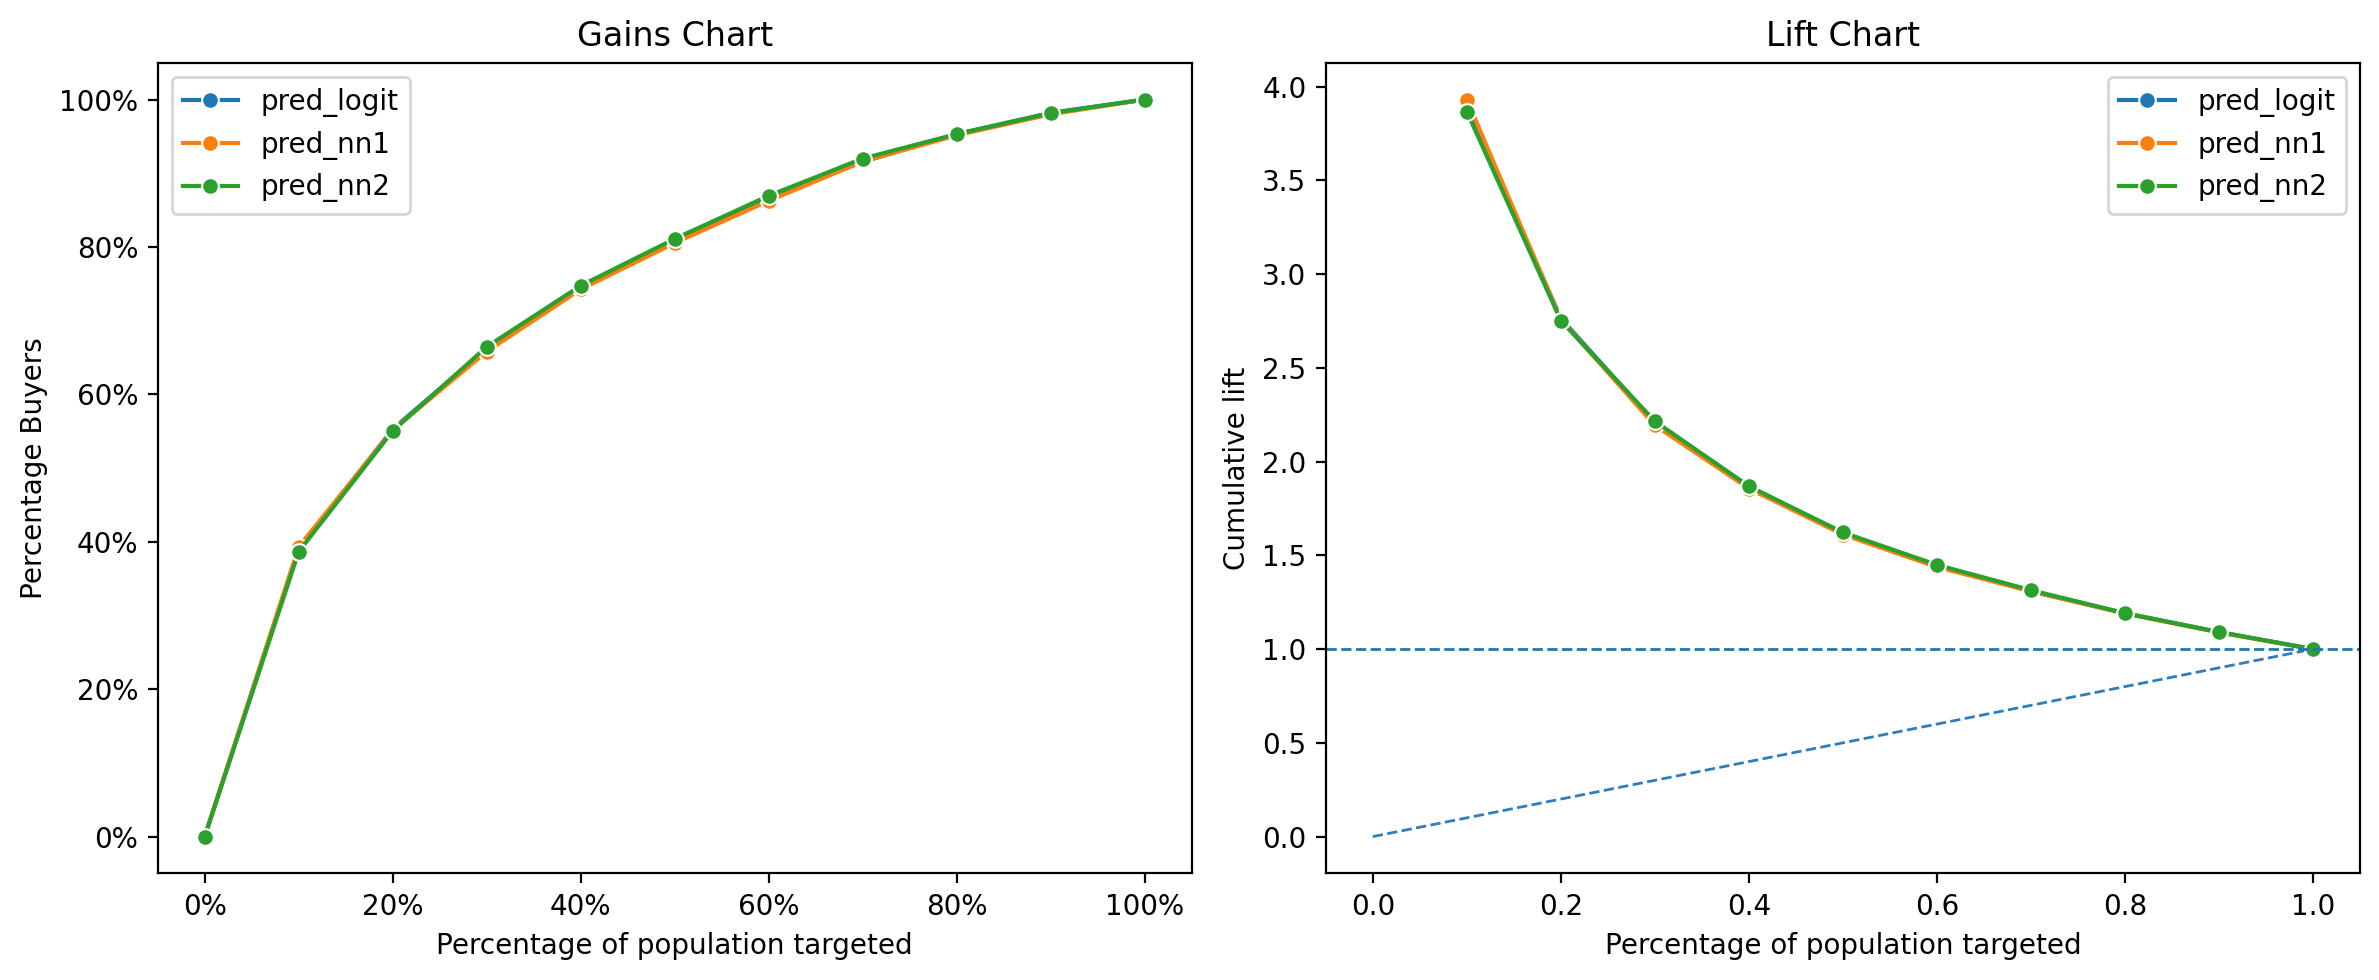

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns
rsm.gains_plot(intuit75k[intuit75k.training == 1], "res1", "Yes", ["pred_logit", "pred_nn1", "pred_nn2"], ax=axes[0] )
rsm.lift_plot(intuit75k[intuit75k.training == 1], "res1", "Yes", ["pred_logit", "pred_nn1", "pred_nn2"], ax=axes[1] )
axes[0].set_title("Gains Chart")
axes[1].set_title("Lift Chart")
plt.tight_layout()
plt.show()


- NN1 and NN2 closely align with logistic regression, indicating no significant performance improvement despite increased complexity. 
- This suggests the data may be largely linear, making logistic regression sufficient. 
- Further tuning or feature engineering may be needed to leverage neural networks effectively.

### NN Model with 4 nodes

Multi-layer Perceptron (NN)
Data                 : intuit
Response variable    : res1
Level                : Yes
Explanatory variables: zip_bins, sex, bizflag, numords, dollars, last, sincepurch, version1, owntaxprod, upgraded
Model type           : classification
Nr. of features      : (10, 29)
Nr. of weights       : 120
Nr. of observations  : 52,500
Hidden_layer_sizes   : (4,)
Activation function  : tanh
Solver               : adam
Alpha                : 0.0001
Batch size           : auto
Learning rate        : 0.001
Maximum iterations   : 1000000
random_state         : 1234
AUC                  : 0.762

Raw data             :
zip_bins  sex  bizflag  numords  dollars  last  sincepurch  version1  owntaxprod  upgraded
      18 Male        0        2    109.5     5          12         0           0         0
       1 Male        0        1     22.0    17           1         0           0         0
       3 Male        0        1     20.0    17          17         0           0         1

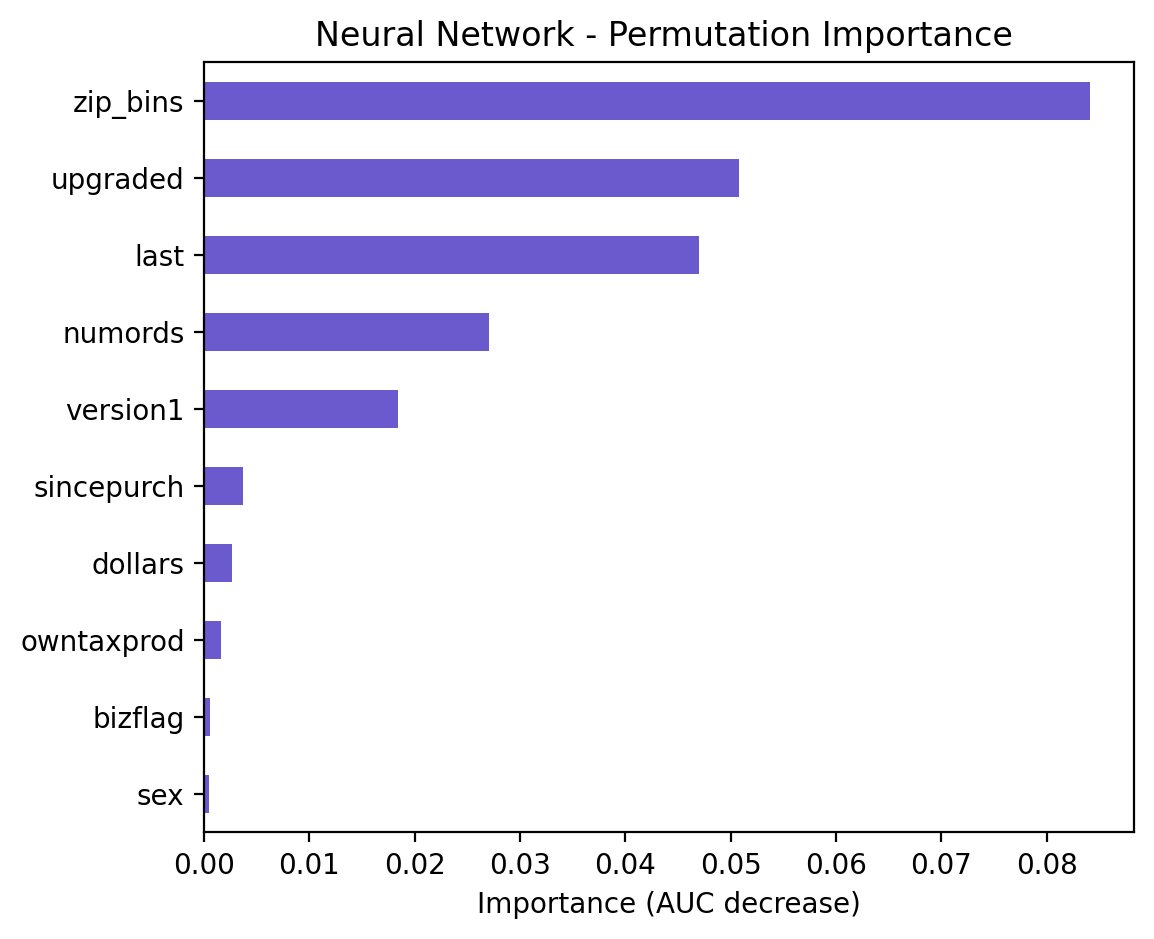

In [57]:
intuit75k["pred_nn4"] = nn_model_size((4,))

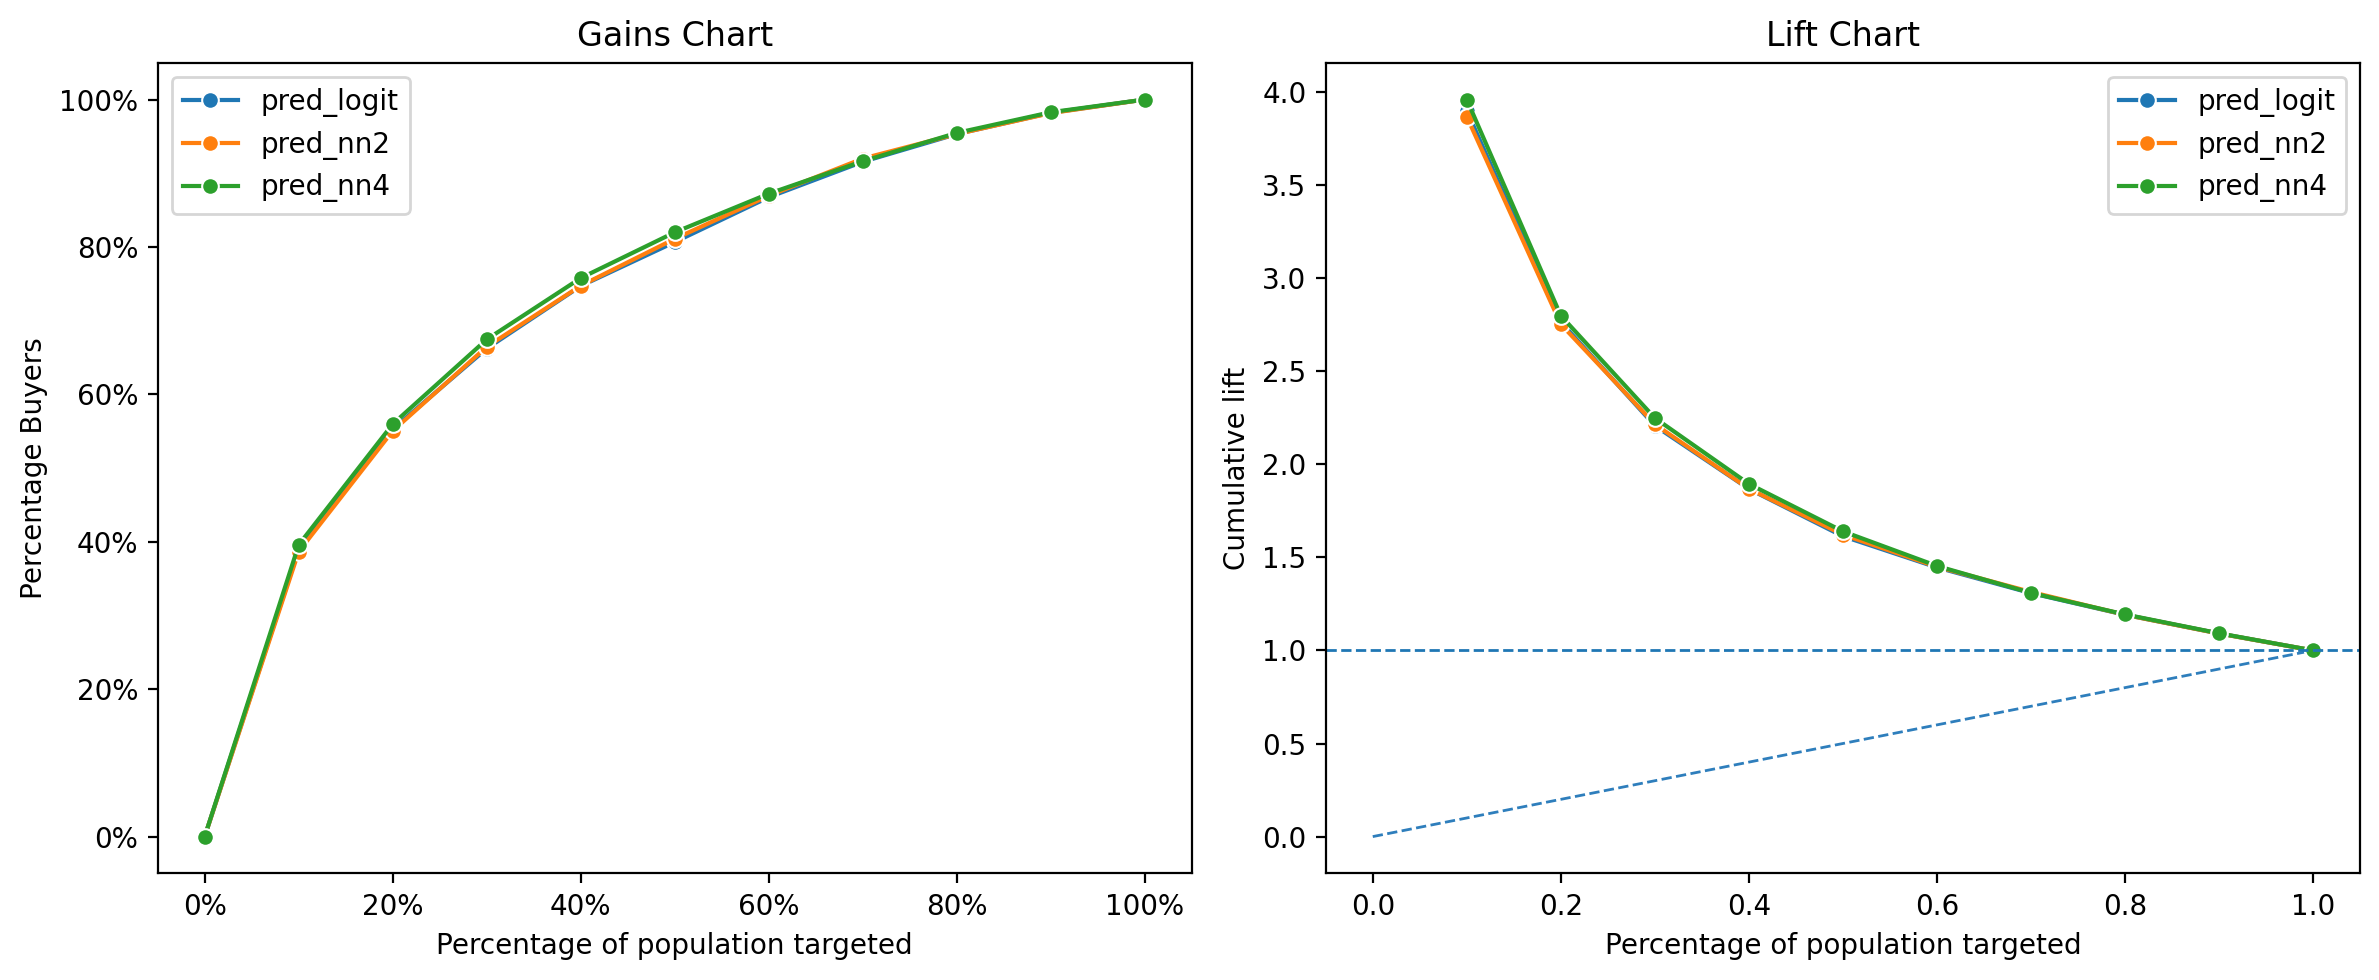

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns
rsm.gains_plot(intuit75k[intuit75k.training == 1], "res1", "Yes", ["pred_logit", "pred_nn2", "pred_nn4"], ax=axes[0] )
rsm.lift_plot(intuit75k[intuit75k.training == 1], "res1", "Yes", ["pred_logit", "pred_nn2", "pred_nn4"], ax=axes[1] )
axes[0].set_title("Gains Chart")
axes[1].set_title("Lift Chart")
plt.tight_layout()
plt.show()

- The gains and lift charts show that NN2 and NN4 perform nearly identically to logistic regression (pred_logit), indicating that the neural networks do not provide additional predictive advantage. 

##### NN model with 10 nodes

Multi-layer Perceptron (NN)
Data                 : intuit
Response variable    : res1
Level                : Yes
Explanatory variables: zip_bins, sex, bizflag, numords, dollars, last, sincepurch, version1, owntaxprod, upgraded
Model type           : classification
Nr. of features      : (10, 29)
Nr. of weights       : 300
Nr. of observations  : 52,500
Hidden_layer_sizes   : (10,)
Activation function  : tanh
Solver               : adam
Alpha                : 0.0001
Batch size           : auto
Learning rate        : 0.001
Maximum iterations   : 1000000
random_state         : 1234
AUC                  : 0.766

Raw data             :
zip_bins  sex  bizflag  numords  dollars  last  sincepurch  version1  owntaxprod  upgraded
      18 Male        0        2    109.5     5          12         0           0         0
       1 Male        0        1     22.0    17           1         0           0         0
       3 Male        0        1     20.0    17          17         0           0         

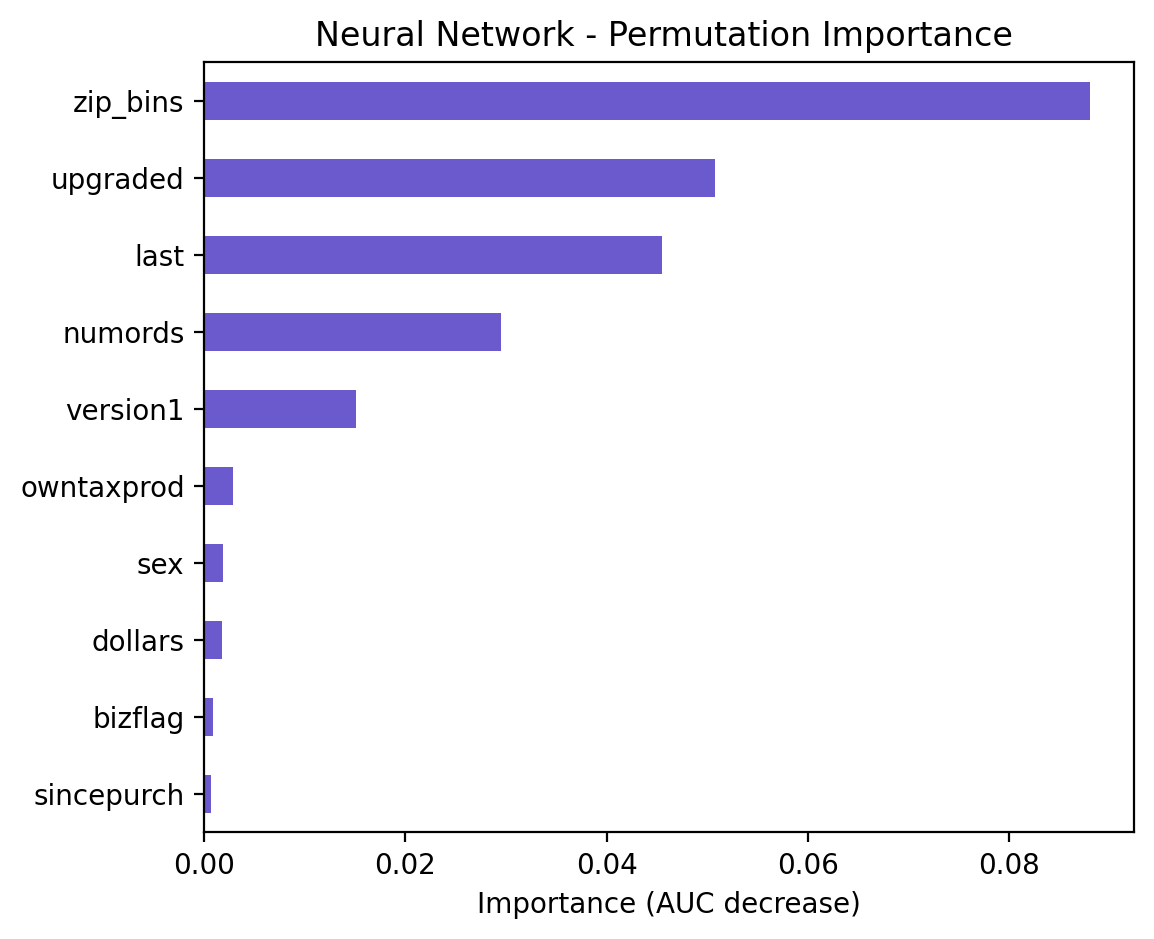

In [59]:
intuit75k["pred_nn10"] = nn_model_size((10,))

##### NN Model with 15 Node

Multi-layer Perceptron (NN)
Data                 : intuit
Response variable    : res1
Level                : Yes
Explanatory variables: zip_bins, sex, bizflag, numords, dollars, last, sincepurch, version1, owntaxprod, upgraded
Model type           : classification
Nr. of features      : (10, 29)
Nr. of weights       : 450
Nr. of observations  : 52,500
Hidden_layer_sizes   : (15,)
Activation function  : tanh
Solver               : adam
Alpha                : 0.0001
Batch size           : auto
Learning rate        : 0.001
Maximum iterations   : 1000000
random_state         : 1234
AUC                  : 0.773

Raw data             :
zip_bins  sex  bizflag  numords  dollars  last  sincepurch  version1  owntaxprod  upgraded
      18 Male        0        2    109.5     5          12         0           0         0
       1 Male        0        1     22.0    17           1         0           0         0
       3 Male        0        1     20.0    17          17         0           0         

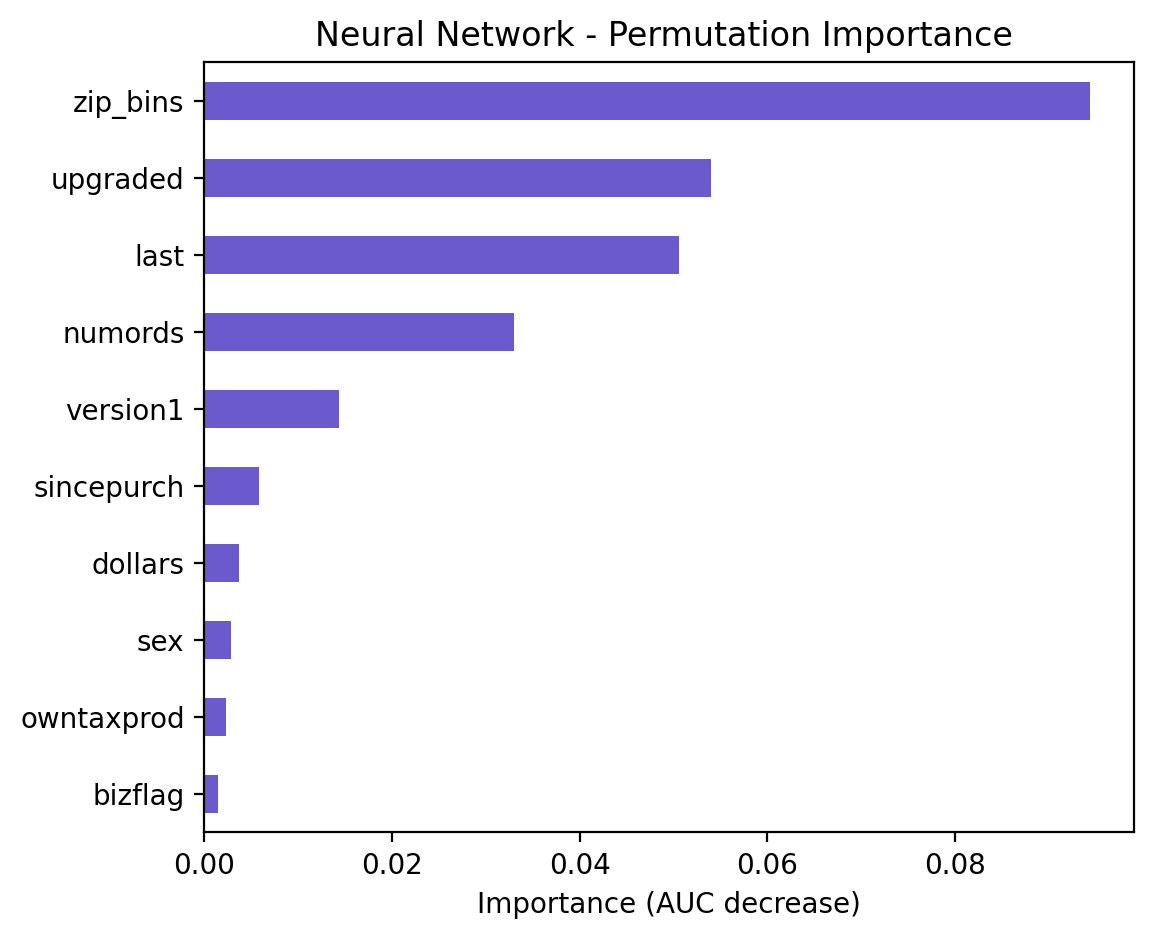

In [60]:
intuit75k["pred_nn15"] = nn_model_size((15,))

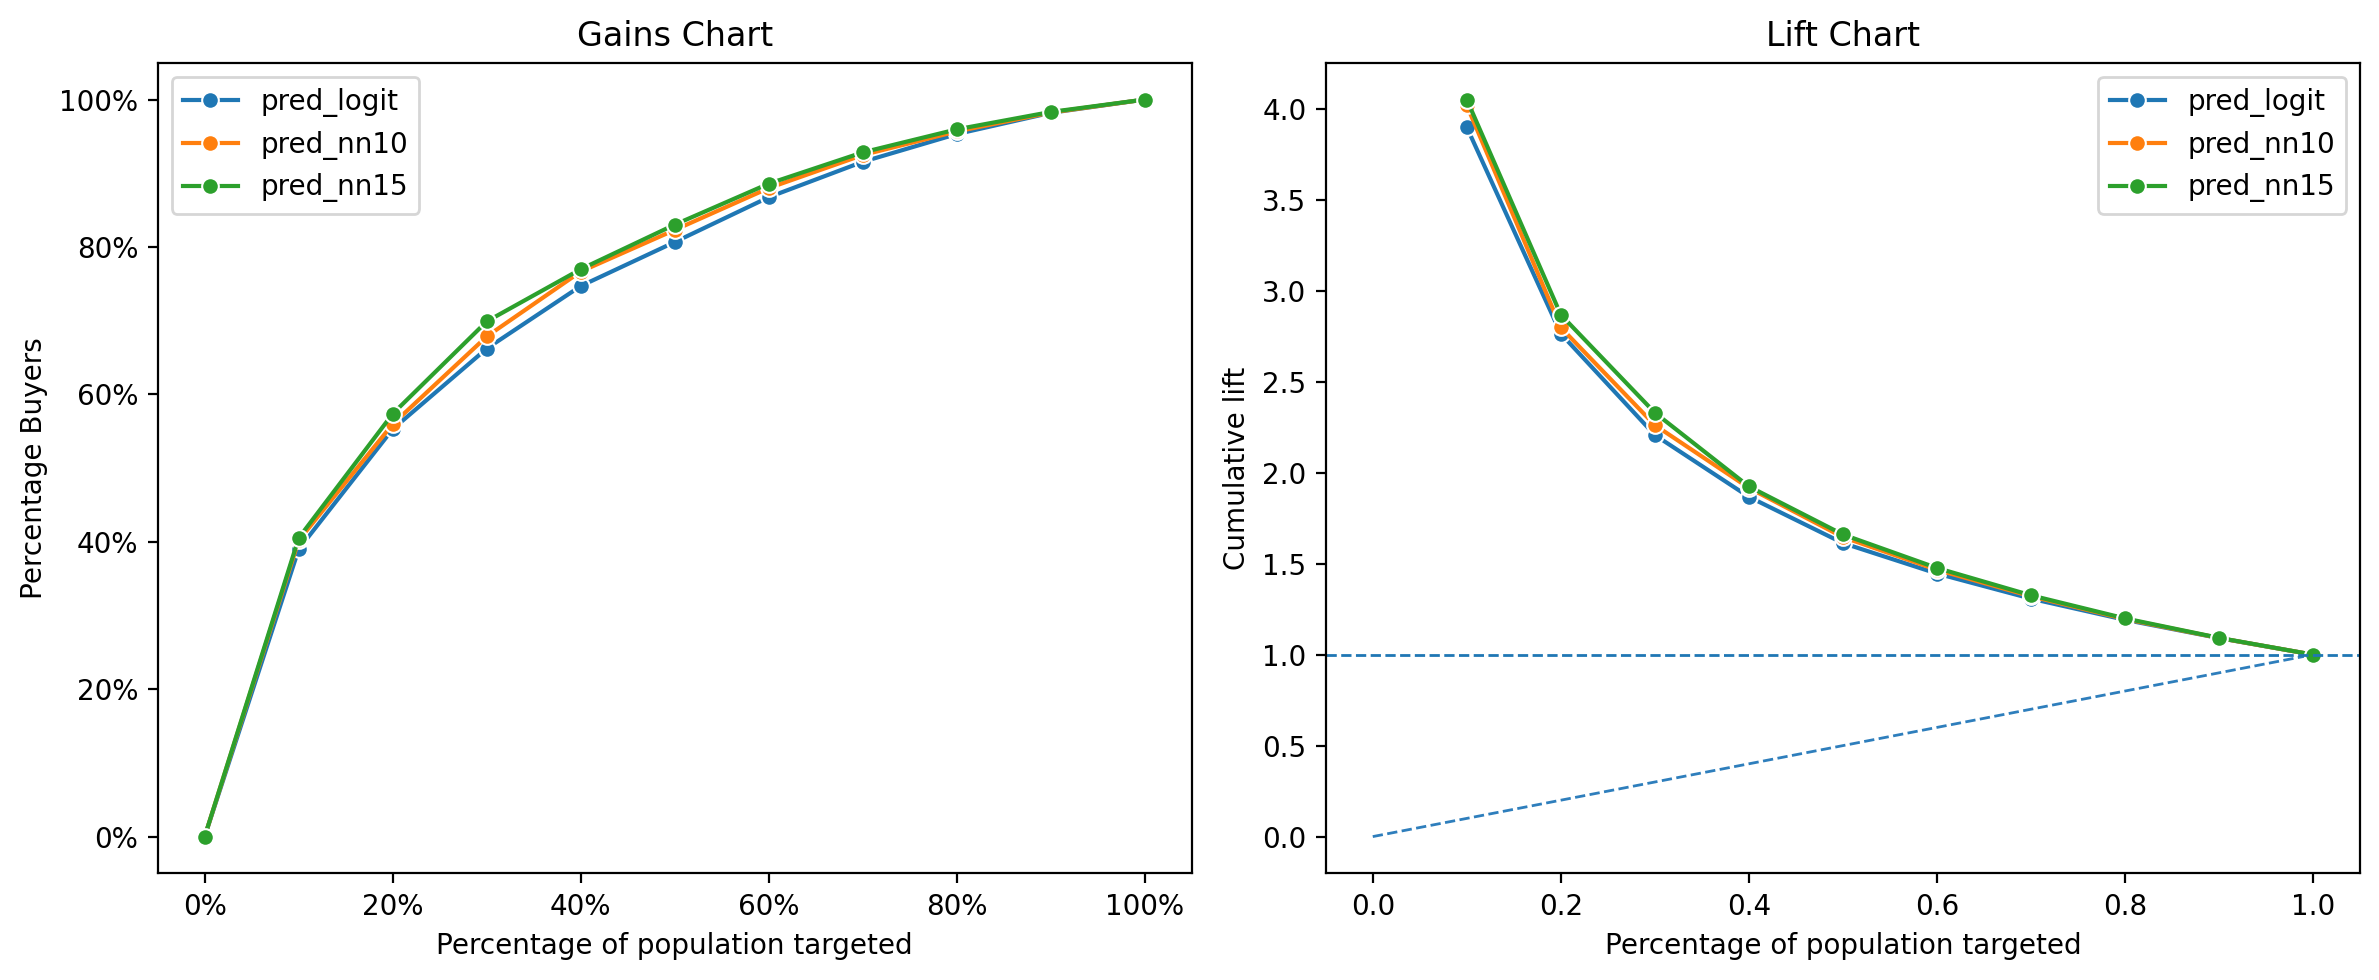

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns
rsm.gains_plot(intuit75k[intuit75k.training == 1], "res1", "Yes", ["pred_logit", "pred_nn10", "pred_nn15"], ax=axes[0] )
rsm.lift_plot(intuit75k[intuit75k.training == 1], "res1", "Yes", ["pred_logit", "pred_nn10", "pred_nn15"], ax=axes[1] )
axes[0].set_title("Gains Chart")
axes[1].set_title("Lift Chart")
plt.tight_layout()
plt.show()

- NN10 and NN15 show slightly better performance than logistic regression (pred_logit), indicating that adding more nodes provides some improvement. 
- However, the gains are minimal, suggesting that the dataset may not be highly nonlinear. 
- The next step is to check for overfitting, ensuring these models generalize well to unseen data.

#### Check overfitting for NN15 and NN20

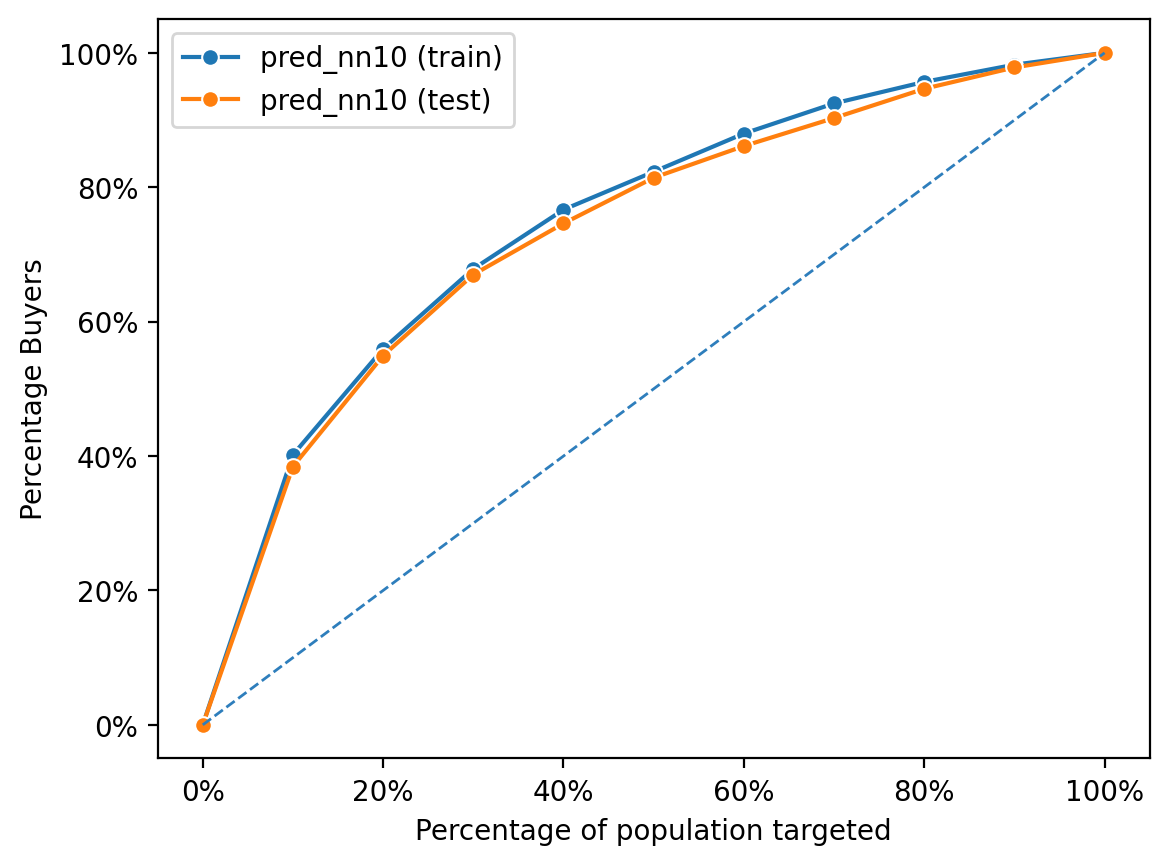

In [62]:
dct = {"train": intuit75k[intuit75k.training == 1], "test": intuit75k[intuit75k.training == 0]}
fig = rsm.gains_plot(dct, "res1", "Yes", "pred_nn10")

- The model with 10 neural network nodes appears to perform well, demonstrating a strong AUC value. We will further validate its performance using cross-validation.

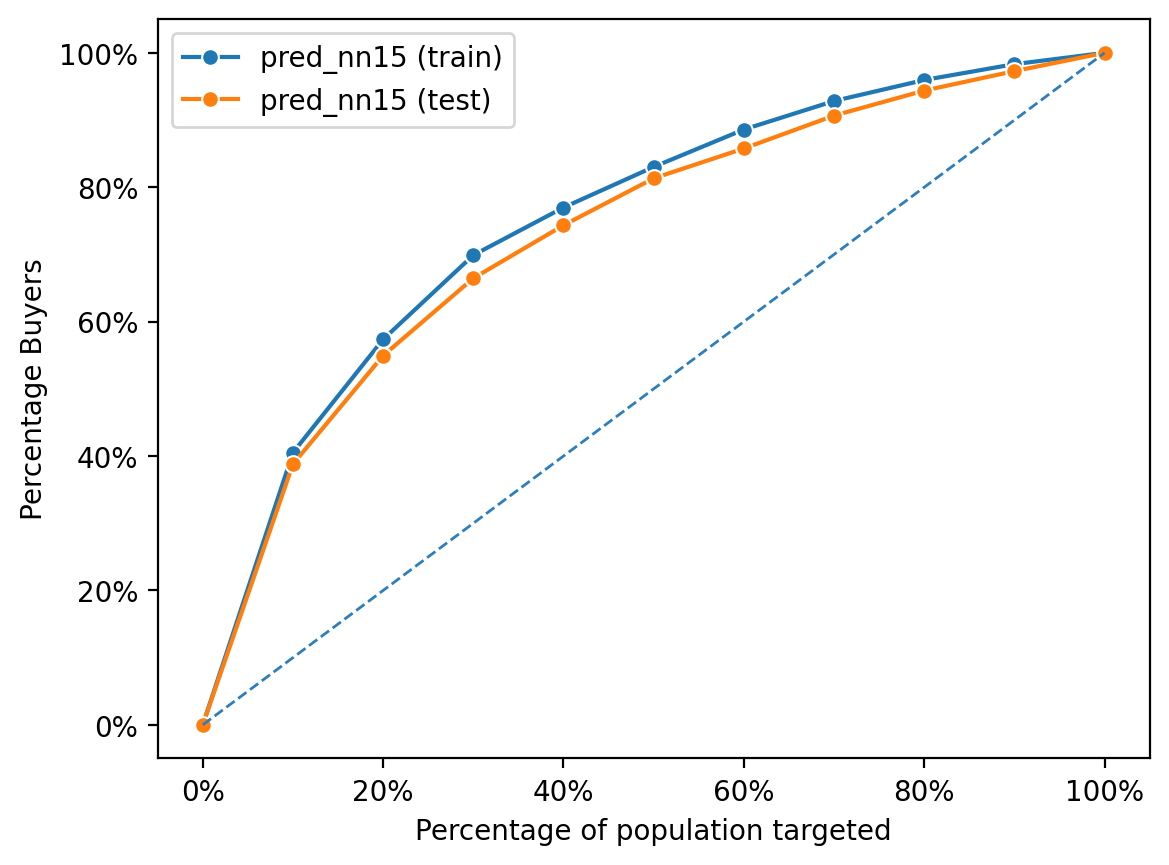

In [23]:
dct = {"train": intuit75k[intuit75k.training == 1], "test": intuit75k[intuit75k.training == 0]}
fig = rsm.gains_plot(dct, "res1", "Yes", "pred_nn15")

- The training performance is significantly better than the test performance, it could indicate overfitting. Need to reduce the complexity of the NN model

### Model Tuning - NN Adam Solver:

In [64]:
base_adam = rsm.model.mlp(
    data={"intuit": train_data},
    rvar="res1",
    lev="Yes",
    evar=evar,
    solver="adam",
    hidden_layer_sizes=(1,),
    mod_type="classification",
)
base_adam.summary()

Multi-layer Perceptron (NN)
Data                 : intuit
Response variable    : res1
Level                : Yes
Explanatory variables: zip_bins, sex, bizflag, numords, dollars, last, sincepurch, version1, owntaxprod, upgraded
Model type           : classification
Nr. of features      : (10, 29)
Nr. of weights       : 30
Nr. of observations  : 52,500
Hidden_layer_sizes   : (1,)
Activation function  : tanh
Solver               : adam
Alpha                : 0.0001
Batch size           : auto
Learning rate        : 0.001
Maximum iterations   : 1000000
random_state         : 1234
AUC                  : 0.753

Raw data             :
zip_bins  sex  bizflag  numords  dollars  last  sincepurch  version1  owntaxprod  upgraded
      18 Male        0        2    109.5     5          12         0           0         0
       1 Male        0        1     22.0    17           1         0           0         0
       3 Male        0        1     20.0    17          17         0           0         1


In [65]:
hls = [(1,), (2,), (3,), (3, 3), (4, 2), (10, )]

param_grid = {"hidden_layer_sizes": hls}
scoring = {"AUC": "roc_auc"}

base_adam_cv = GridSearchCV(
    base_adam.fitted, param_grid, scoring=scoring, cv=5, n_jobs=4, refit="AUC", verbose=5
)

base_adam.data_onehot.mean().round(3)

bizflag        0.244
numords        0.000
dollars       -0.000
last          -0.000
sincepurch     0.000
version1       0.213
owntaxprod     0.029
upgraded       0.207
zip_bins_2     0.050
zip_bins_3     0.049
zip_bins_4     0.050
zip_bins_5     0.050
zip_bins_6     0.050
zip_bins_7     0.051
zip_bins_8     0.051
zip_bins_9     0.049
zip_bins_10    0.050
zip_bins_11    0.049
zip_bins_12    0.050
zip_bins_13    0.050
zip_bins_14    0.050
zip_bins_15    0.050
zip_bins_16    0.050
zip_bins_17    0.050
zip_bins_18    0.051
zip_bins_19    0.050
zip_bins_20    0.050
sex_Male       0.662
sex_Unknown    0.128
dtype: float64

In [66]:
base_adam_cv.fit(base_adam.data_onehot, base_adam.data.res1)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5,
             estimator=MLPClassifier(activation='tanh', hidden_layer_sizes=(1,),
                                     max_iter=1000000, random_state=1234),
             n_jobs=4,
             param_grid={'hidden_layer_sizes': [(1,), (2,), (3,), (3, 3),
                                                (4, 2), (10,)]},
             refit='AUC', scoring={'AUC': 'roc_auc'}, verbose=5)

In [67]:
base_adam.data_onehot.head()

,bizflag,numords,dollars,last,sincepurch,version1,owntaxprod,upgraded,zip_bins_2,zip_bins_3,...,zip_bins_13,zip_bins_14,zip_bins_15,zip_bins_16,zip_bins_17,zip_bins_18,zip_bins_19,zip_bins_20,sex_Male,sex_Unknown
0,0,-0.057079,0.207902,-1.137183,-0.360809,0,0,0,False,False,...,False,False,False,False,False,True,False,False,True,False
3,0,-0.863720,-0.873735,0.119783,-1.458194,0,0,0,False,False,...,False,False,False,False,False,False,False,False,True,False
5,0,-0.863720,-0.898458,0.119783,0.138003,0,0,1,False,True,...,False,False,False,False,False,False,False,False,True,False
7,1,-0.863720,-0.842831,-1.241930,0.138003,1,0,0,False,False,...,False,False,False,False,False,False,False,False,True,False
9,0,0.749561,-0.237115,-0.613447,-0.660096,0,0,0,False,False,...,False,False,False,False,False,False,False,False,True,False


In [68]:
pd.DataFrame(base_adam_cv.cv_results_).iloc[:, 5:].sort_values("rank_test_AUC")

,params,split0_test_AUC,split1_test_AUC,split2_test_AUC,split3_test_AUC,split4_test_AUC,mean_test_AUC,std_test_AUC,rank_test_AUC
5,"{'hidden_layer_sizes': (10,)}",0.743556,0.764082,0.762054,0.748833,0.762237,0.756152,0.008330,1
4,"{'hidden_layer_sizes': (4, 2)}",0.739893,0.759463,0.764861,0.749129,0.762971,0.755263,0.009413,2
3,"{'hidden_layer_sizes': (3, 3)}",0.741039,0.758432,0.762653,0.749172,0.764764,0.755212,0.008881,3
2,"{'hidden_layer_sizes': (3,)}",0.737045,0.760122,0.760067,0.743922,0.758483,0.751928,0.009612,4
1,"{'hidden_layer_sizes': (2,)}",0.735824,0.752941,0.759740,0.746614,0.763532,0.751730,0.009840,5
0,"{'hidden_layer_sizes': (1,)}",0.734046,0.750283,0.755599,0.744784,0.760696,0.749082,0.009201,6


- The model with 10 hidden layer nodes achieved the highest mean test AUC (0.7561), making it the top-performing configuration.
- Increasing the number of hidden nodes generally improves performance, with deeper architectures like (4,2) and (3,3) also performing well.
- The standard deviation of AUC values remains relatively low across different configurations, indicating stable performance across validation splits.

#### Best Model - NN 10

In [69]:
NN_10 = rsm.model.mlp(
    data={"intuit": train_data},
    rvar="res1",
    lev="Yes",
    evar=evar,
    solver="adam",
    hidden_layer_sizes=(10,),
    mod_type="classification",
)
NN_10.summary()

Multi-layer Perceptron (NN)
Data                 : intuit
Response variable    : res1
Level                : Yes
Explanatory variables: zip_bins, sex, bizflag, numords, dollars, last, sincepurch, version1, owntaxprod, upgraded
Model type           : classification
Nr. of features      : (10, 29)
Nr. of weights       : 300
Nr. of observations  : 52,500
Hidden_layer_sizes   : (10,)
Activation function  : tanh
Solver               : adam
Alpha                : 0.0001
Batch size           : auto
Learning rate        : 0.001
Maximum iterations   : 1000000
random_state         : 1234
AUC                  : 0.766

Raw data             :
zip_bins  sex  bizflag  numords  dollars  last  sincepurch  version1  owntaxprod  upgraded
      18 Male        0        2    109.5     5          12         0           0         0
       1 Male        0        1     22.0    17           1         0           0         0
       3 Male        0        1     20.0    17          17         0           0         

### Cross Checking the interactions

- We are analyzing interactions between key variables to understand their impact on the model's predictions.
- Using the NN_10 model, we aim to validate feature effects and ensure meaningful relationships before finalizing the approach.

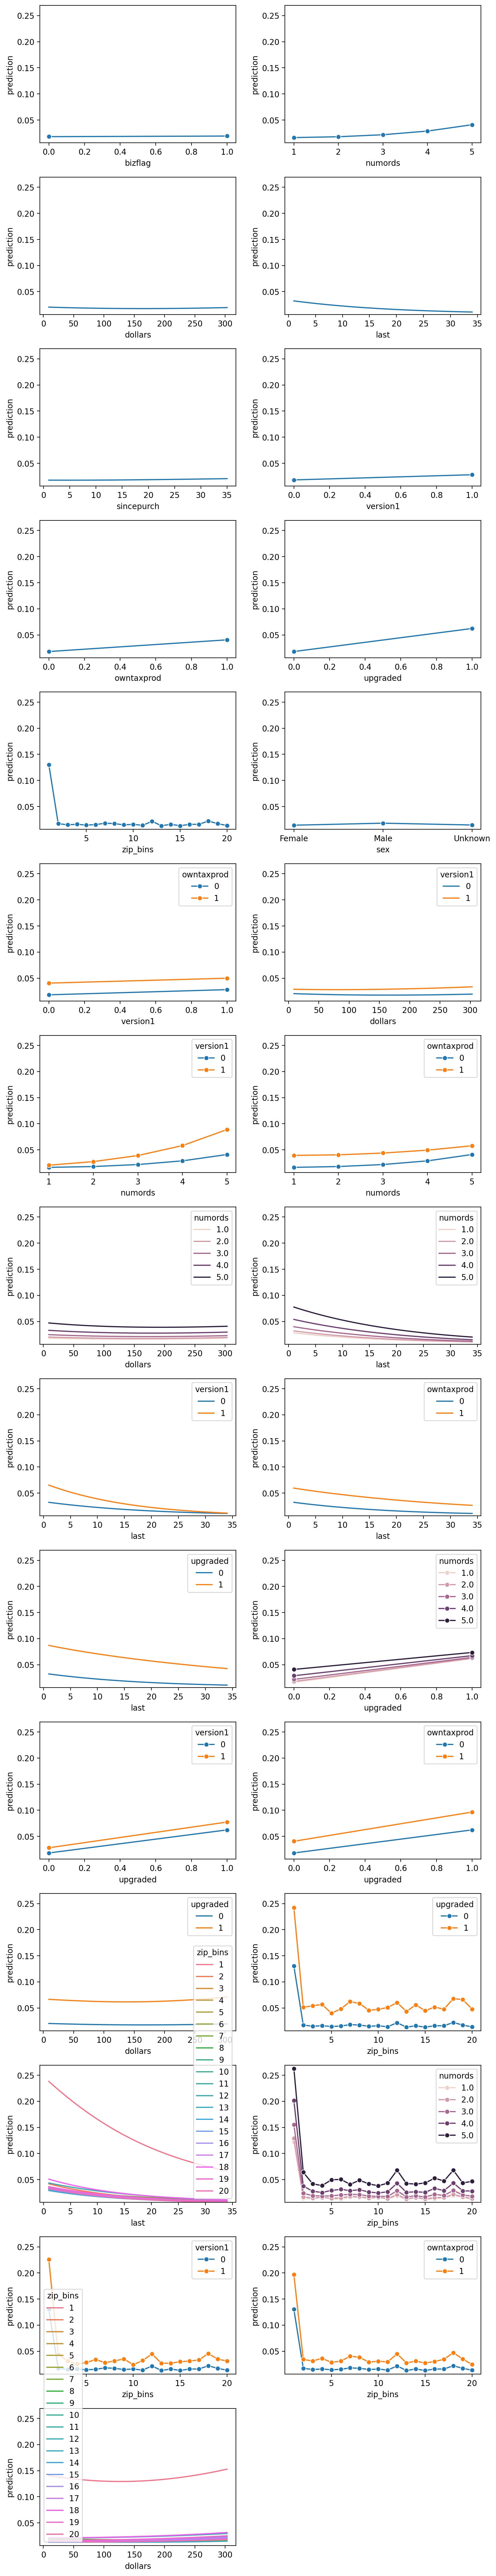

In [70]:
NN_10.plot(plots="pred", incl_int = ["version1:owntaxprod", "version1:dollars", "numords:version1","numords:owntaxprod","numords:dollars","last:numords","last:version1","last:owntaxprod","upgraded:last","upgraded:numords","upgraded:version1","upgraded:owntaxprod","upgraded:dollars","zip_bins:upgraded","zip_bins:last","zip_bins:numords","zip_bins:version1","zip_bins:owntaxprod","zip_bins:dollars"])

### Logistinc Improvement Part

##### The interaction plots highlight key relationships involving version1, last, and numords:

- version1 and numords:
    - Predictions increase as numords rises, with a higher impact when version1 = 1, suggesting that version differences influence the effect of order count on predictions.
- version1 and last:
    - Predictions decrease as last increases, with version1 = 1 consistently yielding higher predictions compared to version1 = 0, indicating a version-dependent decay effect over time.

#### In the Neural Network named NN10 trained above, we see that there are two interactions:
 - Between version1 and numords, and
 - Between version1 and last.

##### We trained a Logistic Regression model including the interaction terms, and our logistic regression model performed similar to the Neural Network in terms of efficiency. The Logistic Model is as outlined below:

Logistic regression (GLM)
Data                 : intuit_data
Response variable    : res1
Level                : Yes
Explanatory variables: zip_bins, numords, dollars, last, version1, owntaxprod, upgraded
Null hyp.: There is no effect of x on res1
Alt. hyp.: There is an effect of x on res1

                     OR     OR%  coefficient  std.error  z.value p.value     
Intercept         0.206  -79.4%        -1.58      0.082  -19.283  < .001  ***
zip_bins[2]       0.145  -85.5%        -1.93      0.111  -17.400  < .001  ***
zip_bins[3]       0.116  -88.4%        -2.15      0.121  -17.759  < .001  ***
zip_bins[4]       0.133  -86.7%        -2.02      0.113  -17.899  < .001  ***
zip_bins[5]       0.114  -88.6%        -2.17      0.121  -18.000  < .001  ***
zip_bins[6]       0.124  -87.6%        -2.09      0.115  -18.144  < .001  ***
zip_bins[7]       0.119  -88.1%        -2.13      0.118  -18.098  < .001  ***
zip_bins[8]       0.126  -87.4%        -2.07      0.115  -18.079  < .001  ***
zip_bin

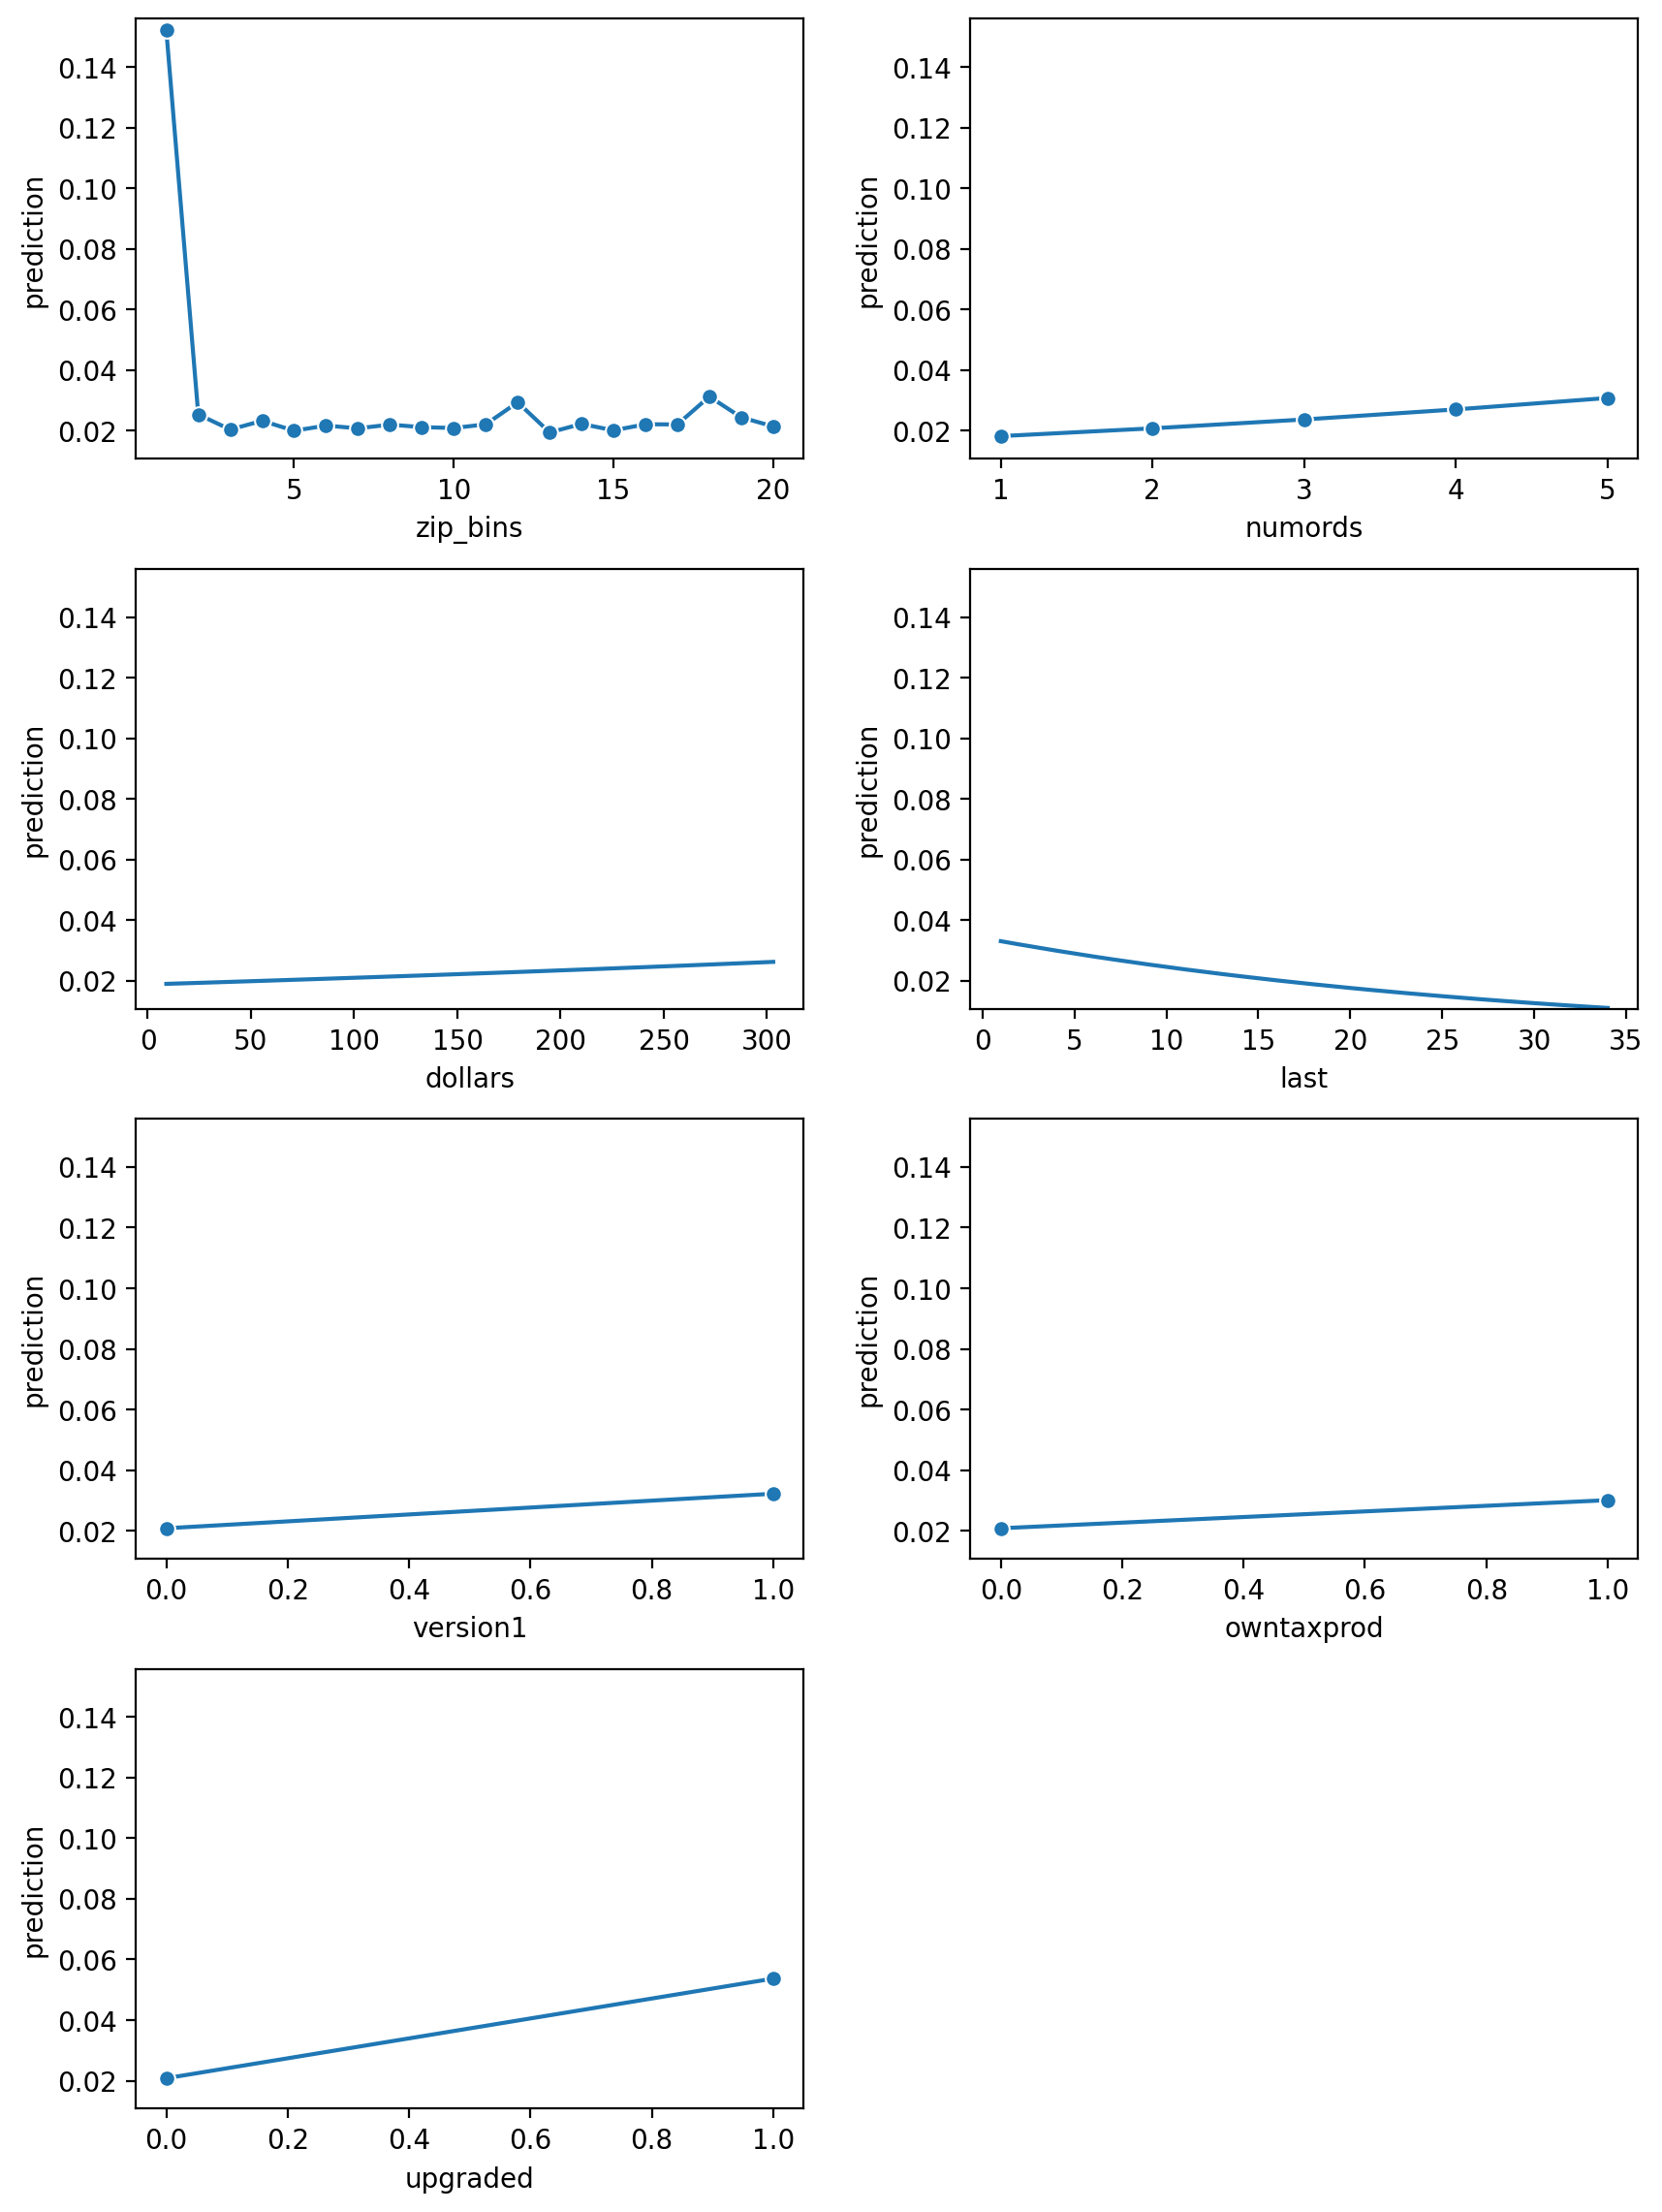

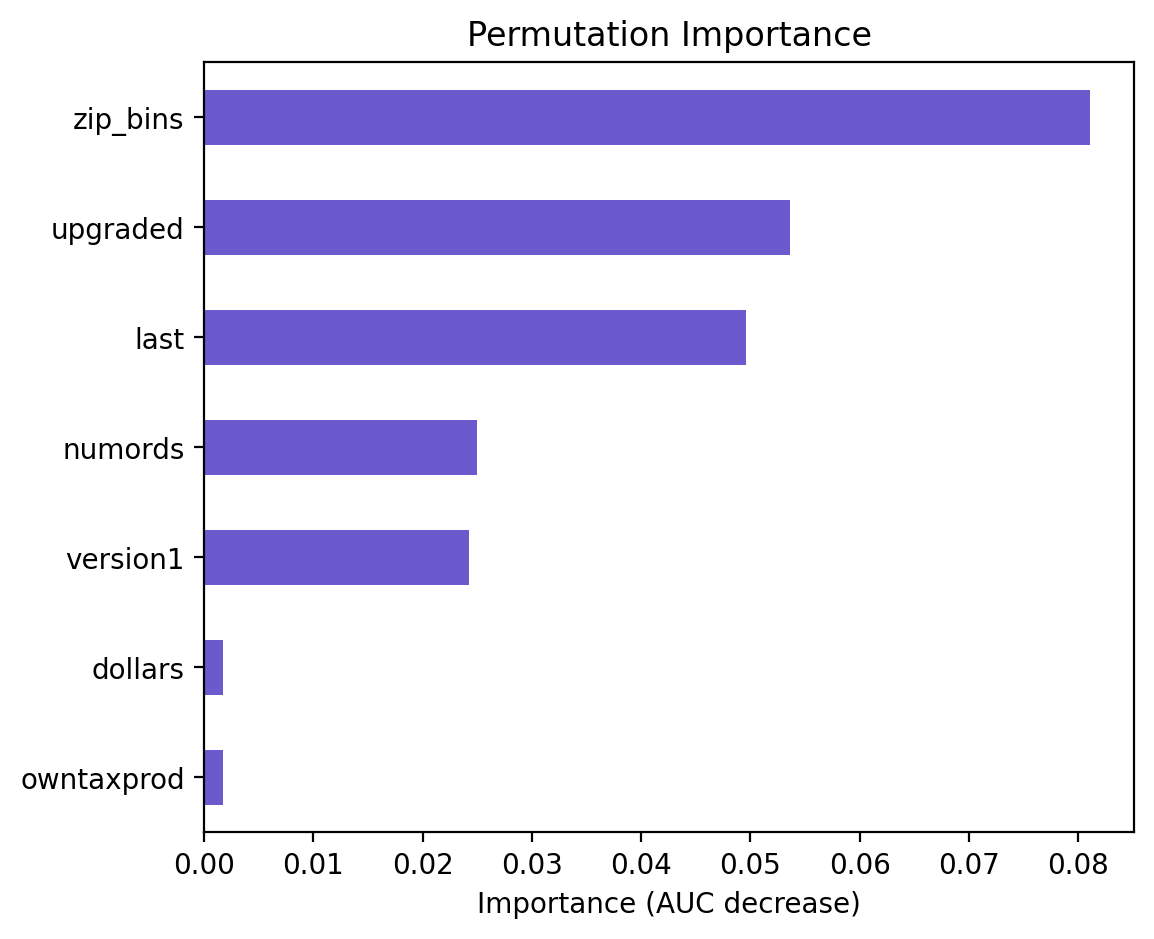

In [71]:
logit_model4 = rsm.logistic(
    data={"intuit_data": train_pyrsm},
    rvar="res1",
    lev="Yes",
    evar= ["zip_bins", "numords", "dollars", "last", "version1", "owntaxprod", "upgraded"],
    ivar = ["numords:version1","last:version1"]
)

logit_model4.summary(main=True, fit=True, ci=False, vif=True)
logit_model4.plot(plots="pred")
logit_model4.plot(plots="vimp")

In [75]:
intuit75k["pred_logit_new"] = logit_model4.predict(intuit75k)["prediction"] 

#### The model has slightly improved in terms of pseudo r-squared and the AUC.

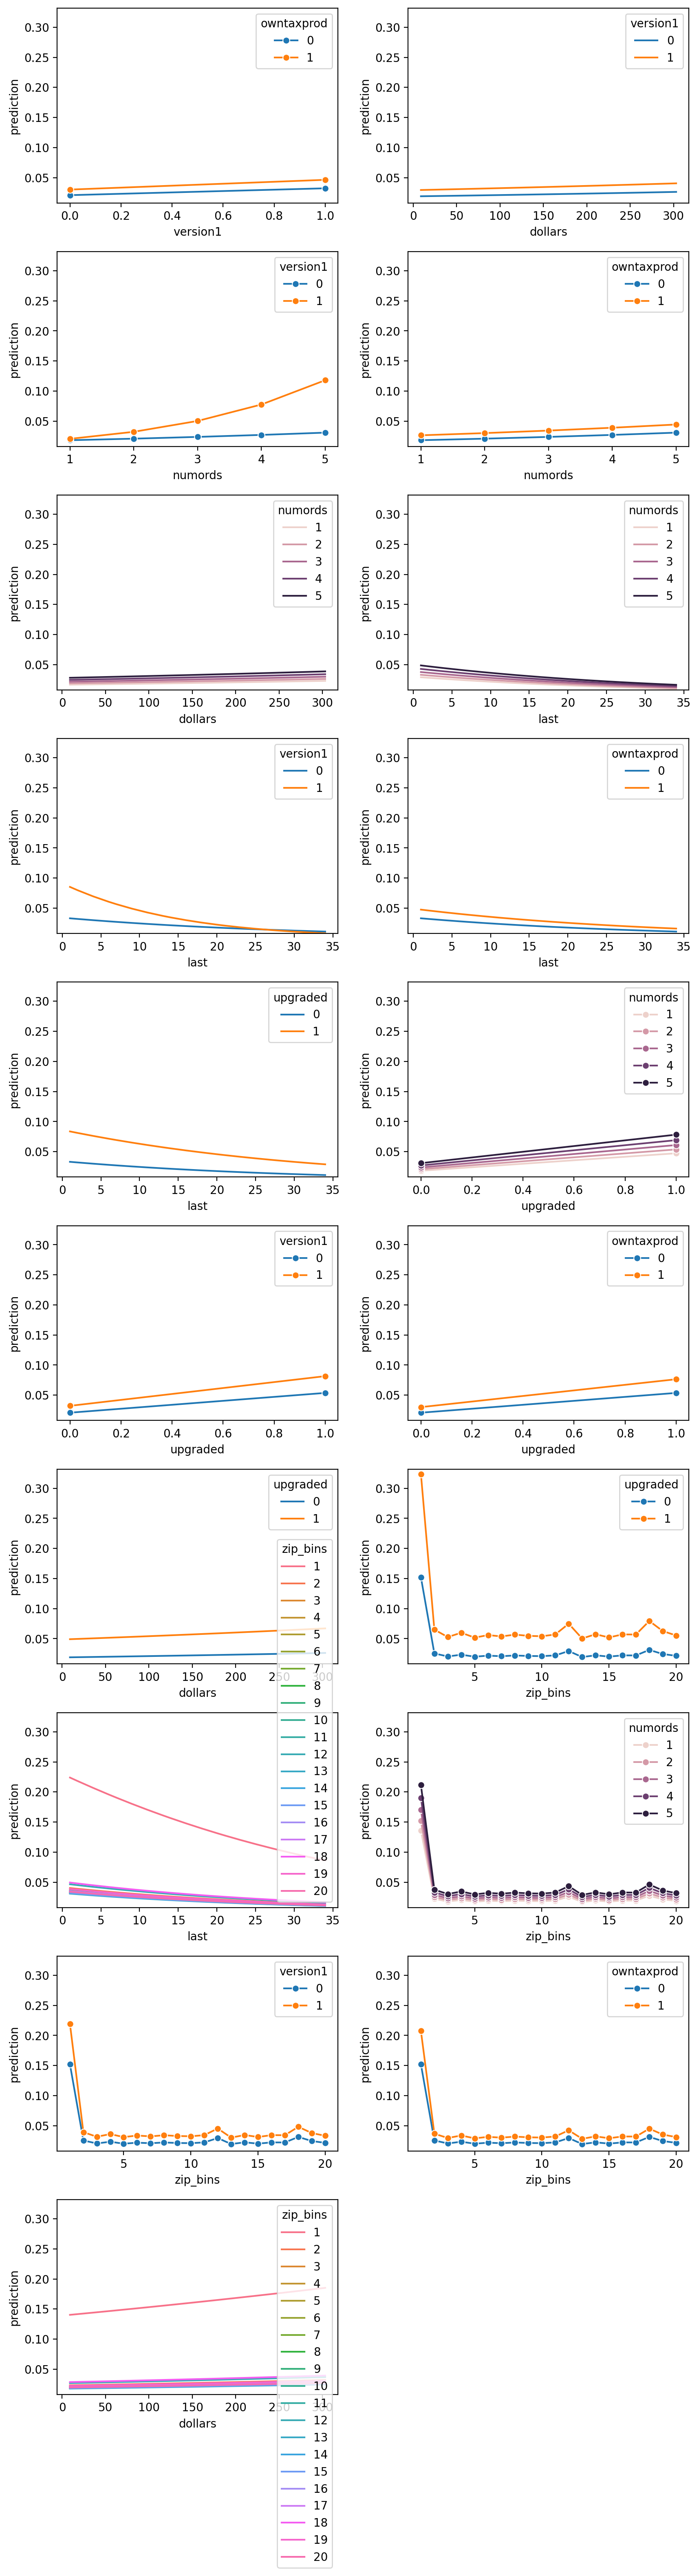

In [72]:
logit_model4.plot(plots="pred", incl=[], incl_int = ["version1:owntaxprod", "version1:dollars", "numords:version1","numords:owntaxprod","numords:dollars","last:numords","last:version1","last:owntaxprod","upgraded:last","upgraded:numords","upgraded:version1","upgraded:owntaxprod","upgraded:dollars","zip_bins:upgraded","zip_bins:last","zip_bins:numords","zip_bins:version1","zip_bins:owntaxprod","zip_bins:dollars"])

##### We now see there is evidence of interaction between last and version1, and numords and version1. This logistic regression model now performs similar to the neural network with 10 hidden layers.

## Comparision between Logistic and Neural Network Model

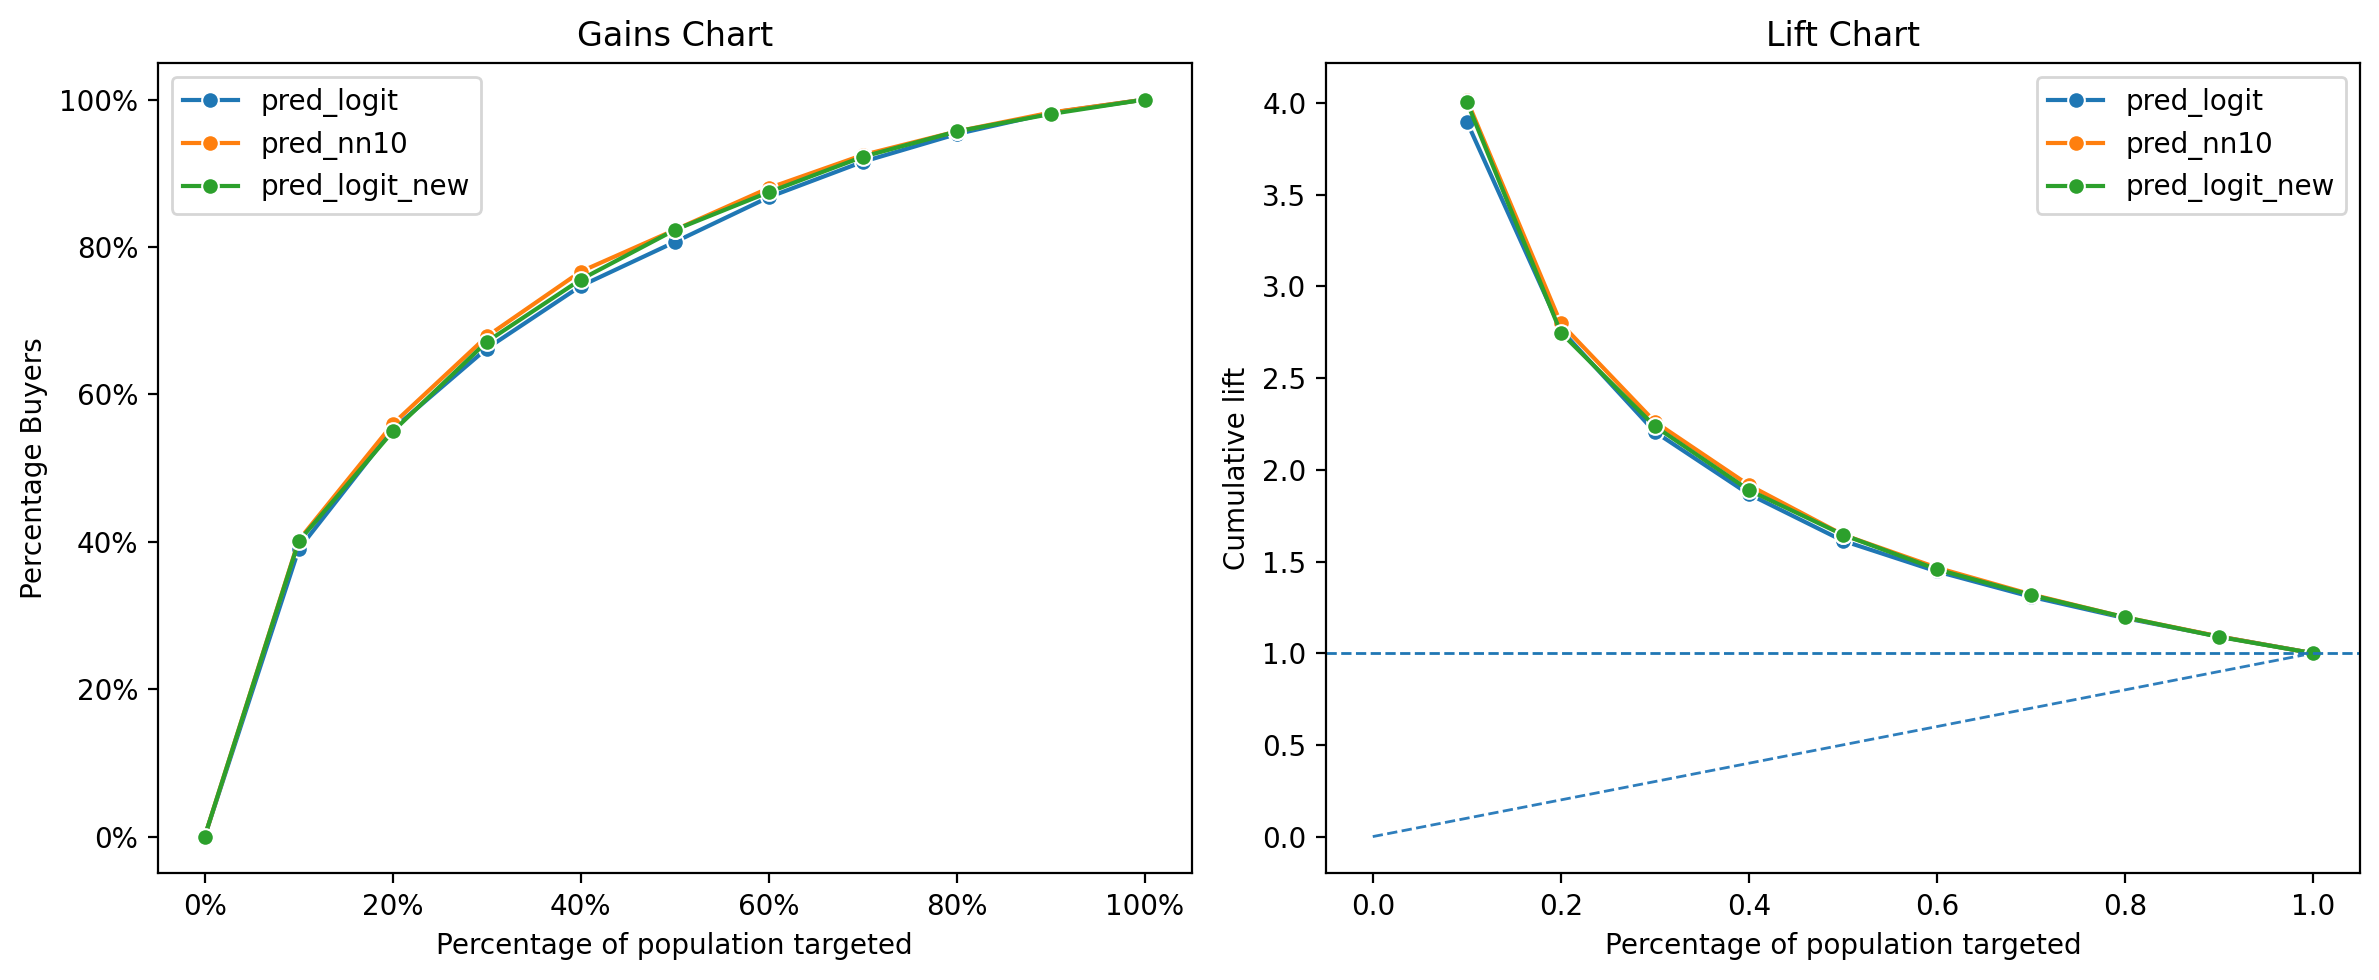

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns
rsm.gains_plot(intuit75k[intuit75k.training == 1], "res1", "Yes", ["pred_logit", "pred_nn10", "pred_logit_new"], ax=axes[0] )
rsm.lift_plot(intuit75k[intuit75k.training == 1], "res1", "Yes", ["pred_logit", "pred_nn10", "pred_logit_new"], ax=axes[1] )
axes[0].set_title("Gains Chart")
axes[1].set_title("Lift Chart")
plt.tight_layout()
plt.show()

## Model Comparison - Profit and Rome Analysis

In [78]:
intuit75k

,id,zip5,zip_bins,sex,bizflag,numords,dollars,last,sincepurch,version1,...,pred_nn4_l,pred_nn10_l,pred_nn10_10_l,pred_nn15_l,pred_nn1,pred_nn2,pred_nn4,pred_nn10,pred_nn15,pred_logit_new
0,1,94553,18,Male,0,2,109.5,5,12,0,...,0.038516,0.035285,0.037433,0.030517,0.042647,0.038884,0.038022,0.039441,0.034574,0.044178
1,2,53190,10,Unknown,0,1,69.5,4,3,0,...,0.027006,0.057636,0.032489,0.014002,0.023971,0.020928,0.022669,0.027757,0.036179,0.025762
2,3,37091,8,Male,0,4,93.0,14,29,0,...,0.055444,0.115085,0.080114,0.059743,0.086047,0.103023,0.074098,0.088520,0.064359,0.075284
3,4,02125,1,Male,0,1,22.0,17,1,0,...,0.149763,0.219475,0.116875,0.278367,0.082627,0.083721,0.100480,0.133834,0.135920,0.119188
4,5,60201,11,Male,0,1,24.5,2,3,0,...,0.032414,0.030090,0.042392,0.030064,0.027599,0.023072,0.029718,0.024337,0.036596,0.027696
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74995,74996,28205,6,Male,1,4,211.5,5,15,0,...,0.045145,0.042798,0.014200,0.067722,0.058333,0.059828,0.049449,0.058630,0.054974,0.044538
74996,74997,94806,18,Male,0,1,4.5,35,34,1,...,0.016850,0.018381,0.015589,0.028285,0.022267,0.020206,0.014988,0.011885,0.015856,0.006567
74997,74998,72958,13,Female,1,1,54.5,4,19,1,...,0.036478,0.092143,0.083617,0.017299,0.046885,0.045139,0.039108,0.036773,0.047112,0.040326
74998,74999,29464,6,Male,0,1,69.5,20,27,0,...,0.043119,0.033907,0.012018,0.049900,0.032721,0.040419,0.033911,0.038726,0.040889,0.040844


In [97]:

cost = 1.41
margin_res1 = 60
margin_res2 = 30

breakeven_res1 = cost/margin_res1
breakeven_res2 = cost/margin_res2

actual_responses_75k = len(intuit75k[intuit75k['res1_yes']==1])

nr_responses_nn10 = sum([1 if a > breakeven_res1 else 0 for a in intuit75k['pred_nn10']]) # Mails sent in wave 1 for Neural Network Model
response_rate_nn10 = actual_responses_75k/nr_responses_nn10

nr_responses_logit = sum([1 if a > breakeven_res1 else 0 for a in intuit75k['pred_logit_new']]) # Mails sent in wave 1 for Logit Model
response_rate_logit = actual_responses_75k/nr_responses_logit

#### Confusion Matrix Analysis

In [ ]:
prediction_logit = [1 if a > breakeven_res2 else 0 for a in intuit75k['pred_logit_new']]
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(intuit75k['res1_yes'], prediction_logit)
print(cm)
accuracy = (cm[0,0]+cm[1,1])/sum(sum(cm))
precision = cm[1,1]/(cm[1,1]+cm[0,1])
recall = cm[1,1]/(cm[1,1]+cm[1,0])
f1 = 2*(precision*recall)/(precision+recall)
(accuracy, precision, recall, f1)

In [96]:
prediction_nn = [1 if a > breakeven_res2 else 0 for a in intuit75k["pred_nn10"]]
cm = confusion_matrix(intuit75k['res1_yes'], prediction_nn )
print(cm)

accuracy = (cm[0,0]+cm[1,1])/sum(sum(cm))
precision = cm[1,1]/(cm[1,1]+cm[0,1])
recall = cm[1,1]/(cm[1,1]+cm[1,0])
f1 = 2*(precision*recall)/(precision+recall)
(accuracy, precision, recall, f1)

[[51046 20353]
 [ 1157  2444]]


(0.7132, 0.10720708865201561, 0.6787003610108303, 0.18516554284415485)

### PROFIT  Analysis

In [80]:
def profit (df, breakeven, column_name, response_rate, margin):
    nr_responses = sum([1 if a > breakeven else 0 for a in df[column_name]])
    total_cost = nr_responses * 1.41
    total_revenue = nr_responses * response_rate * margin
    total_profit = total_revenue - total_cost
    ROME = total_profit/total_cost
    return [
    f'The Profit of the model is: {total_profit}',
    f'The Return on Marketing Expenditure is: {ROME}',
    f'Number of mails sent:{nr_responses}',
    f'Number of positive responses: {nr_responses*response_rate}'
]

In [81]:
# Finding the number of business for Wave 2

num_business = 801821
response_rate_wave1 = len(intuit75k[intuit75k['res1_yes']==1])/len(intuit75k)
num_business_wave2 = round(num_business*(1-response_rate_wave1))
num_business_wave2

763323

In [82]:
#wave 2 Neural Network: Profit Analysis for wave 2 test set
profit(intuit75k[(intuit75k['res1_yes']==0) & (intuit75k['training']==0)], 
       breakeven_res2, 
       "pred_nn10",
       response_rate_nn10*0.5,
       margin_res1
       )

['The Profit of the model is: 7002.220934234789',
 'The Return on Marketing Expenditure is: 0.811191463207313',
 'Number of mails sent:6122',
 'Number of positive responses: 260.57068223724644']

In [83]:
# Wave 2 Neural Network: Scaled Profit

nn_positive_responses = 521
nn_mails_sent = 6122
len_dataset = len(intuit75k[(intuit75k['res1_yes']==0) & (intuit75k['training']==0)])
scaled_nn_mails_sent = (nn_mails_sent / len_dataset) * num_business_wave2
scaled_nn_positive_responses = response_rate_nn10 * scaled_nn_mails_sent
total_revenue_nn = scaled_nn_positive_responses * 60
total_cost_nn = scaled_nn_mails_sent * 1.41
total_profit_nn = total_revenue_nn - total_cost_nn
rome_nn = total_profit_nn/total_cost_nn

print(f'Total profit using Neural Network Model: {total_profit_nn}')
print(f'ROME using Neural Networks: {rome_nn}')

Total profit using Neural Network Model: 807539.9347023322
ROME using Neural Networks: 2.622382926414626


In [84]:
#wave 2 Logistic Regression: Profit Analysis for wave 2 test set
profit(intuit75k[(intuit75k['res1_yes']==0) & (intuit75k['training']==0)], 
       breakeven_res2, 
       "pred_logit_new",
       response_rate_logit * 0.5,
       margin_res1
       )

['The Profit of the model is: 5302.8870237449855',
 'The Return on Marketing Expenditure is: 0.6614338344702537',
 'Number of mails sent:5686',
 'Number of positive responses: 222.00245039574975']

In [85]:
# Wave 2 Logistic Regression: Scaled Profit

logit_positive_responses = 444
logit_mails_sent = 5686
len_dataset = len(intuit75k[(intuit75k['res1_yes']==0) & (intuit75k['training']==0)])
scaled_logit_mails_sent = (logit_mails_sent / len_dataset) * num_business_wave2
scaled_logit_positive_responses = response_rate_logit * scaled_logit_mails_sent
total_revenue_logit = scaled_logit_positive_responses * 60
total_cost_logit = scaled_logit_mails_sent * 1.41
total_profit_logit = total_revenue_logit - total_cost_logit
rome_logit = total_profit_logit/total_cost_logit

print(f'Total profit using Logistic Regression: {total_profit_logit}')
print(f'ROME using Logistic Regression: {rome_logit}')

Total profit using Logistic Regression: 664363.7060444073
ROME using Logistic Regression: 2.322867668940507


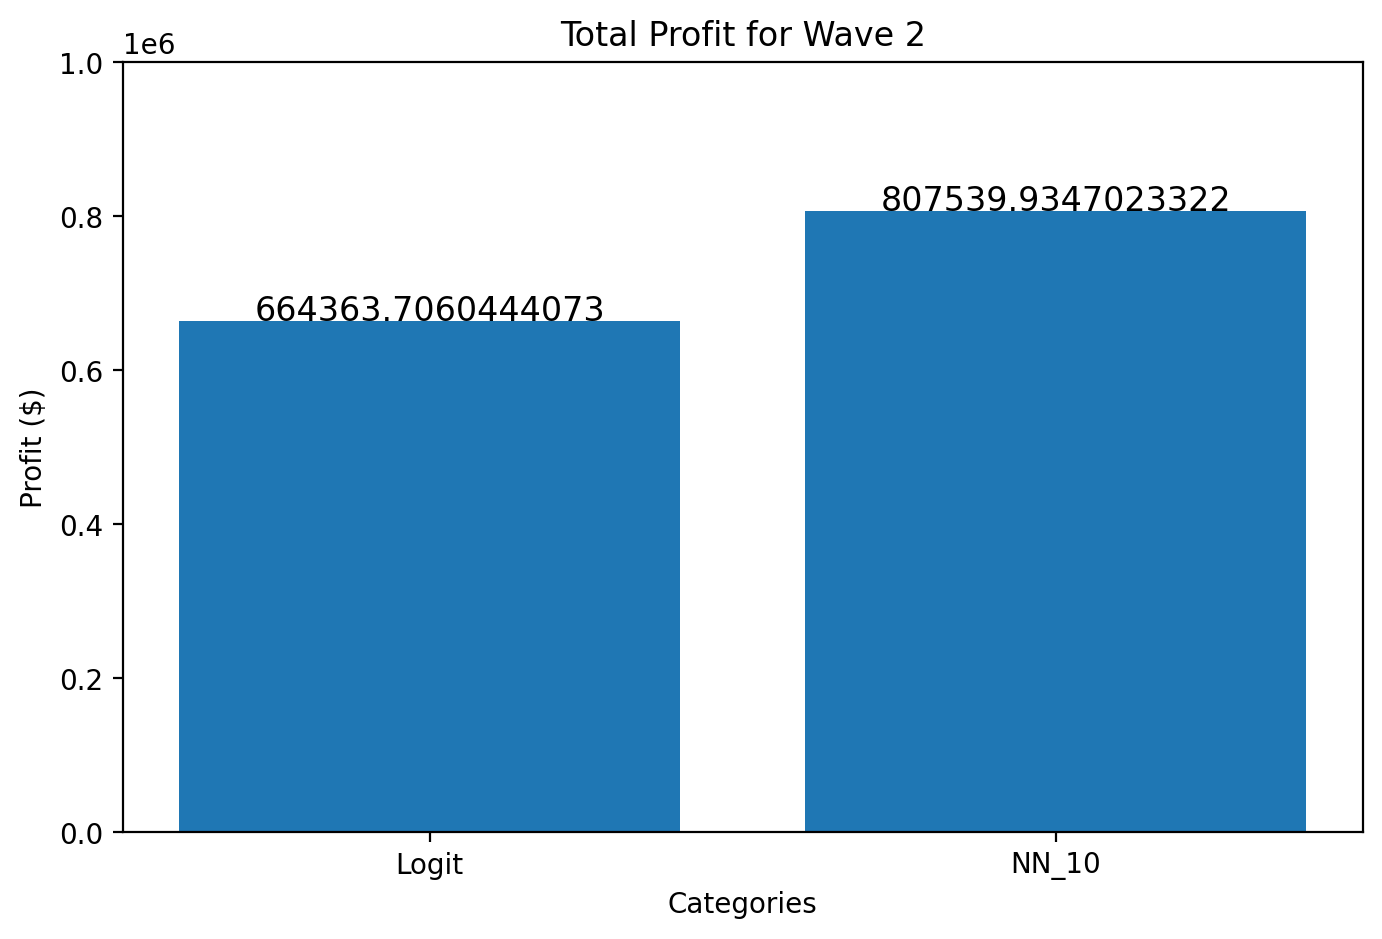

In [86]:
# Data for the bar chart
categories = ["Logit","NN_10"]
values = [total_profit_logit, total_profit_nn]

# Create the bar chart
plt.figure(figsize=(8, 5))
plt.bar(categories, values)

# Add labels and title
plt.xlabel("Categories")
plt.ylabel("Profit ($)")
plt.title("Total Profit for Wave 2")
plt.ylim(0, 1_000_000)  # Adjust the y-axis limit

# Show the value on top of each bar
for i, v in enumerate(values):
    plt.text(i, v + 100, str(v), ha='center', fontsize=12)

# Display the chart
plt.show()

## CSV FILE

In [87]:
intuit75k

,id,zip5,zip_bins,sex,bizflag,numords,dollars,last,sincepurch,version1,...,pred_nn4_l,pred_nn10_l,pred_nn10_10_l,pred_nn15_l,pred_nn1,pred_nn2,pred_nn4,pred_nn10,pred_nn15,pred_logit_new
0,1,94553,18,Male,0,2,109.5,5,12,0,...,0.038516,0.035285,0.037433,0.030517,0.042647,0.038884,0.038022,0.039441,0.034574,0.044178
1,2,53190,10,Unknown,0,1,69.5,4,3,0,...,0.027006,0.057636,0.032489,0.014002,0.023971,0.020928,0.022669,0.027757,0.036179,0.025762
2,3,37091,8,Male,0,4,93.0,14,29,0,...,0.055444,0.115085,0.080114,0.059743,0.086047,0.103023,0.074098,0.088520,0.064359,0.075284
3,4,02125,1,Male,0,1,22.0,17,1,0,...,0.149763,0.219475,0.116875,0.278367,0.082627,0.083721,0.100480,0.133834,0.135920,0.119188
4,5,60201,11,Male,0,1,24.5,2,3,0,...,0.032414,0.030090,0.042392,0.030064,0.027599,0.023072,0.029718,0.024337,0.036596,0.027696
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74995,74996,28205,6,Male,1,4,211.5,5,15,0,...,0.045145,0.042798,0.014200,0.067722,0.058333,0.059828,0.049449,0.058630,0.054974,0.044538
74996,74997,94806,18,Male,0,1,4.5,35,34,1,...,0.016850,0.018381,0.015589,0.028285,0.022267,0.020206,0.014988,0.011885,0.015856,0.006567
74997,74998,72958,13,Female,1,1,54.5,4,19,1,...,0.036478,0.092143,0.083617,0.017299,0.046885,0.045139,0.039108,0.036773,0.047112,0.040326
74998,74999,29464,6,Male,0,1,69.5,20,27,0,...,0.043119,0.033907,0.012018,0.049900,0.032721,0.040419,0.033911,0.038726,0.040889,0.040844


In [88]:
# Filter test data
intuit75k_test = intuit75k[intuit75k['training'] == 0].copy()  # Use .copy() to avoid SettingWithCopyWarning

# Apply condition to create 'mailto_wave2' column
intuit75k_test.loc[:, 'mailto_wave2'] = intuit75k_test['pred_nn10'] > breakeven_res2

# Select necessary columns
Hargun_Krithika_Siddhartha_Vidhi_Group_7 = intuit75k_test[['id', 'mailto_wave2']]

# Save to CSV
Hargun_Krithika_Siddhartha_Vidhi_Group_7.to_csv('Hargun_Krithika_Siddhartha_Vidhi_Group_7.csv', index=False)

print("CSV file saved successfully!")

CSV file saved successfully!


### AI Help Section

## The file is submitted as Gen AI Help.docx in this repo.